In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import os

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [43]:
# Leggi la lista dei ticker dal file
def load_tickers_only(filename='tickers.txt'):
    """Carica solo i ticker dal file di configurazione"""
    tickers = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):
                parts = line.split(',')
                if len(parts) == 2:
                    ticker = parts[1].strip()
                    tickers.append(ticker)
    return tickers

TICKERS = load_tickers_only('tickers.txt')

# Crea la cartella result se non esiste
os.makedirs('result', exist_ok=True)

# Lista modelli
MODELS = ["arima", "autoarima", "chronos2", "exponential_smoothing", "lightgbm", "moving_average", "yoy_trend"]

In [44]:
print("="*80)
print("ESECUZIONE TRAIN + PREDICT PER OGNI MODELLO E OGNI TICKER")
print("="*80)

for ticker in TICKERS:
    for model in MODELS:
        script_path = f"train_predict/train_predict_{model}.py"

        if not os.path.exists(script_path):
            print(f"⚠ Script non trovato: {script_path}, salto…")
            continue

        cmd = ["python", script_path, ticker]
        print(f"\n▶ Eseguo: {cmd}")

        try:
            # Esegue lo script e stampa output live
            subprocess.run(cmd, check=True)
            print(f"✓ Completato {model.upper()} per {ticker}")
        except subprocess.CalledProcessError as e:
            print(f"✗ Errore eseguendo {script_path} per {ticker}: {e}")

ESECUZIONE TRAIN + PREDICT PER OGNI MODELLO E OGNI TICKER

▶ Eseguo: ['python', 'train_predict/train_predict_arima.py', 'AVGO']


2025-12-08 20:42:38,129 - __main__ - INFO - 
2025-12-08 20:42:38,129 - __main__ - INFO - Starting FCF forecasting pipeline for AVGO (ARIMA(1,0,1))
2025-12-08 20:42:38,129 - __main__ - INFO - ================================================================================

2025-12-08 20:42:38,129 - __main__ - INFO - Loading data for AVGO...
2025-12-08 20:42:38,134 - __main__ - INFO - Loaded 7 quarterly records and 6 annual records
2025-12-08 20:42:38,134 - __main__ - INFO - Annual FY range: 2018 - 2024
2025-12-08 20:42:38,134 - __main__ - INFO - Quarterly FY range: 2019 - 2025
2025-12-08 20:42:38,135 - __main__ - INFO - Quarters available per FY: {2019: ['Q1'], 2020: ['Q1'], 2021: ['Q1'], 2022: ['Q1'], 2023: ['Q1'], 2024: ['Q1'], 2025: ['Q1']}
2025-12-08 20:42:38,135 - __main__ - INFO - Preparing data with lagged quarterly exogenous variables...
2025-12-08 20:42:38,135 - __main__ - INFO - FY mapping: {0: 2018, 1: 2020, 2: 2021, 3: 2022, 4: 2023, 5: 2024}
2025-12-08 20:42:38,137 - __main

✓ Completato ARIMA per AVGO

▶ Eseguo: ['python', 'train_predict/train_predict_autoarima.py', 'AVGO']


2025-12-08 20:42:39,590 - __main__ - INFO - 
2025-12-08 20:42:39,590 - __main__ - INFO - Starting FCF forecasting pipeline for AVGO (SARIMAX)
2025-12-08 20:42:39,590 - __main__ - INFO - ================================================================================

2025-12-08 20:42:39,590 - __main__ - INFO - Loading data for AVGO...
2025-12-08 20:42:39,595 - __main__ - INFO - Loaded 7 quarterly records and 6 annual records
2025-12-08 20:42:39,595 - __main__ - INFO - Annual FY range: 2018 - 2024
2025-12-08 20:42:39,595 - __main__ - INFO - Quarterly FY range: 2019 - 2025
2025-12-08 20:42:39,595 - __main__ - INFO - Quarters available per FY: {2019: ['Q1'], 2020: ['Q1'], 2021: ['Q1'], 2022: ['Q1'], 2023: ['Q1'], 2024: ['Q1'], 2025: ['Q1']}
2025-12-08 20:42:39,595 - __main__ - INFO - Preparing data with lagged quarterly exogenous variables...
2025-12-08 20:42:39,595 - __main__ - INFO - FY mapping: {0: 2018, 1: 2020, 2: 2021, 3: 2022, 4: 2023, 5: 2024}
2025-12-08 20:42:39,597 - __main__ - 

✓ Completato AUTOARIMA per AVGO

▶ Eseguo: ['python', 'train_predict/train_predict_chronos2.py', 'AVGO']


...

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
2025-12-08 20:45:36,427 - __main__ - INFO - 
2025-12-08 20:45:36,427 - __main__ - INFO - Starting FCF forecasting pipeline for SMCI
2025-12-08 20:45:36,427 - __main__ - INFO - ================================================================================

2025-12-08 20:45:36,427 - __main__ - INFO - Loading data for SMCI...
2025-12-08 20:45:36,431 - __main__ - INFO - Loaded 13 quarterly records and 12 annual records
2025-12-08 20:45:36,431 - __main__ - INFO -

✓ Completato LIGHTGBM per SMCI

▶ Eseguo: ['python', 'train_predict/train_predict_moving_average.py', 'SMCI']


2025-12-08 20:45:37,163 - __main__ - INFO - 
2025-12-08 20:45:37,163 - __main__ - INFO - Starting FCF forecasting pipeline for SMCI (Moving Average)
2025-12-08 20:45:37,163 - __main__ - INFO - ================================================================================

2025-12-08 20:45:37,163 - __main__ - INFO - Loading data for SMCI...
2025-12-08 20:45:37,168 - __main__ - INFO - Loaded 13 quarterly records and 12 annual records
2025-12-08 20:45:37,168 - __main__ - INFO - Annual FY range: 2012 - 2025
2025-12-08 20:45:37,168 - __main__ - INFO - Quarterly FY range: 2012 - 2026
2025-12-08 20:45:37,168 - __main__ - INFO - Quarters available per FY: {2012: ['Q1'], 2013: ['Q1'], 2014: ['Q1'], 2015: ['Q1'], 2016: ['Q1'], 2019: ['Q1'], 2020: ['Q1'], 2021: ['Q1'], 2022: ['Q1'], 2023: ['Q1'], 2024: ['Q1'], 2025: ['Q1'], 2026: ['Q1']}
2025-12-08 20:45:37,168 - __main__ - INFO - Preparing data for Moving Average...
2025-12-08 20:45:37,169 - __main__ - INFO - Annual data: 12 fiscal years
2025-

✓ Completato MOVING_AVERAGE per SMCI

▶ Eseguo: ['python', 'train_predict/train_predict_yoy_trend.py', 'SMCI']
✓ Completato YOY_TREND per SMCI


2025-12-08 20:45:37,410 - __main__ - INFO - 
2025-12-08 20:45:37,411 - __main__ - INFO - Starting FCF forecasting pipeline for SMCI (YoY Trend)
2025-12-08 20:45:37,411 - __main__ - INFO - ================================================================================

2025-12-08 20:45:37,411 - __main__ - INFO - Loading data for SMCI...
2025-12-08 20:45:37,415 - __main__ - INFO - Loaded 13 quarterly records and 12 annual records
2025-12-08 20:45:37,415 - __main__ - INFO - Annual FY range: 2012 - 2025
2025-12-08 20:45:37,415 - __main__ - INFO - Quarterly FY range: 2012 - 2026
2025-12-08 20:45:37,416 - __main__ - INFO - Quarters available per FY: {2012: ['Q1'], 2013: ['Q1'], 2014: ['Q1'], 2015: ['Q1'], 2016: ['Q1'], 2019: ['Q1'], 2020: ['Q1'], 2021: ['Q1'], 2022: ['Q1'], 2023: ['Q1'], 2024: ['Q1'], 2025: ['Q1'], 2026: ['Q1']}
2025-12-08 20:45:37,416 - __main__ - INFO - Preparing data for YoY Trend...
2025-12-08 20:45:37,416 - __main__ - INFO - Annual data: 12 fiscal years
2025-12-08 20:4

In [45]:
# Directory
HIST_DIR = "data"
PRED_DIR = "result"

def calculate_metrics_df(
    df: pd.DataFrame,
    pred_col: str = "predicted",
    true_col: str = "actual",
    id_col: str = "ticker",
) -> dict:
    """Calcola le metriche di errore aggregate su tutti i ticker."""
    if df.empty:
        return {}

    df = df.copy()
    error_col = "error_pred"
    df[error_col] = df[pred_col] - df[true_col]

    real_total = df[true_col].sum()
    if real_total == 0:
        real_total = np.nan  # per evitare divisioni per zero nelle percentuali

    metrics = {}
    metrics["Number_Tickers"] = df[id_col].nunique()
    metrics["Total_Real"] = df[true_col].sum()
    metrics["Total_Pred"] = df[pred_col].sum()
    metrics["Total_Error"] = df[error_col].sum()

    # MAE "Month": somma |errore| su tutte le righe (qui: anni x ticker)
    metrics["MAE_Month"] = df[error_col].abs().sum()

    # MAE "Year": sommo per ticker, poi faccio l'assoluto e sommo
    mae_year = (
        df.groupby(id_col)[error_col]
        .sum()
        .abs()
        .sum()
    )
    metrics["MAE_Year"] = mae_year

    # Percentuali relative al totale reale
    metrics["Total_Error_Percent"] = (
        metrics["Total_Error"] / real_total if not np.isnan(real_total) else np.nan
    )
    metrics["MAE_Month_Percent"] = (
        metrics["MAE_Month"] / real_total if not np.isnan(real_total) else np.nan
    )
    metrics["MAE_Year_Percent"] = (
        metrics["MAE_Year"] / real_total if not np.isnan(real_total) else np.nan
    )

    # Over / Under
    metrics["Overestimate"] = df.loc[df[error_col] > 0, error_col].sum()
    metrics["Underestimate"] = df.loc[df[error_col] < 0, error_col].sum()
    metrics["Overestimate_Percent"] = (
        metrics["Overestimate"] / real_total if not np.isnan(real_total) else np.nan
    )
    metrics["Underestimate_Percent"] = (
        metrics["Underestimate"] / real_total if not np.isnan(real_total) else np.nan
    )

    # MAPE classico: mean(|e| / |y|)
    denom_true = df[true_col].abs().replace(0, np.nan)
    mape = (df[error_col].abs() / denom_true).replace([np.inf, -np.inf], np.nan).fillna(0).mean()
    metrics["MAPE"] = mape

    # sMAPE = 2 * mean(|e| / (|y| + |ŷ|))
    denom = (df[pred_col].abs() + df[true_col].abs()).replace(0, np.nan)
    smape = 2 * (df[error_col].abs() / denom).replace([np.inf, -np.inf], np.nan).fillna(0).mean()
    metrics["sMAPE"] = smape

    return metrics


def print_metrics_table(metrics: dict, label: str):
    """Stampa le metriche in una tabella 'dritta' usando DataFrame, come nel riepilogo."""
    if not metrics:
        print("Nessun dato per calcolare le metriche.")
        return

    rows = []

    def add_row(metric_name: str, value_str: str):
        rows.append({"Metric": metric_name, label: value_str})

    # helper per valori con scala + %
    def format_val(key_base, scale=1e6):
        val = metrics.get(key_base, np.nan)
        if np.isnan(val):
            return "N/A"
        val_scaled = val / scale
        val_perc = metrics.get(f"{key_base}_Percent", np.nan)
        if not np.isnan(val_perc):
            return f"{val_scaled:.2f} M ({val_perc:.2%})"
        else:
            return f"{val_scaled:.2f} M"

    def format_pct(key):
        v = metrics.get(key, np.nan)
        return f"{v:.2%}" if not np.isnan(v) else "N/A"

    add_row("Number Tickers", f"{metrics.get('Number_Tickers', 0)}")
    add_row("Real Volume",    format_val("Total_Real"))
    add_row("MAE Month",      format_val("MAE_Month"))
    add_row("MAE Year",       format_val("MAE_Year"))
    add_row("Total Error",    format_val("Total_Error"))
    add_row("MAPE",           format_pct("MAPE"))
    add_row("sMAPE",          format_pct("sMAPE"))
    add_row("Overestimate",   format_val("Overestimate"))
    add_row("Underestimate",  format_val("Underestimate"))

    df_print = pd.DataFrame(rows)

    print()
    print(df_print.to_string(index=False))


print("\n" + "=" * 80)
print("CALCOLO METRICHE DI ERRORE PER MODELLO (AGGREGATE SU TUTTI I TICKER)")
print("=" * 80)

all_model_metrics = {}

for model in MODELS:
    all_rows = []

    for ticker in TICKERS:
        pred_path = os.path.join(PRED_DIR, f"{ticker}_fcf_annual_predictions_{model}.csv")
        if not os.path.exists(pred_path):
            continue

        df_pred = pd.read_csv(pred_path)
        if df_pred.empty:
            continue

        if not {"fy", "actual", "predicted"}.issubset(df_pred.columns):
            print(f"⚠ {model.upper()} - {ticker}: formato file inatteso ({pred_path})")
            continue

        df_eval = df_pred.copy()
        df_eval["ticker"] = ticker  # ID per aggregare e contare i ticker
        all_rows.append(df_eval)

    print("\n" + "-" * 80)
    print(f"MODELLO: {model.upper()}")

    if not all_rows:
        print(f"Nessun file di prediction trovato per {model.upper()} su nessun ticker.")
        continue

    df_all = pd.concat(all_rows, ignore_index=True)
    metrics = calculate_metrics_df(
        df_all,
        pred_col="predicted",
        true_col="actual",
        id_col="ticker",
    )
    print_metrics_table(metrics, label="PRED")

    all_model_metrics[model] = metrics



CALCOLO METRICHE DI ERRORE PER MODELLO (AGGREGATE SU TUTTI I TICKER)

--------------------------------------------------------------------------------
MODELLO: ARIMA

        Metric                   PRED
Number Tickers                     11
   Real Volume           1317381.36 M
     MAE Month   641094.32 M (48.66%)
      MAE Year   627623.43 M (47.64%)
   Total Error -627623.43 M (-47.64%)
          MAPE                122.49%
         sMAPE                 95.63%
  Overestimate      6735.45 M (0.51%)
 Underestimate -634358.87 M (-48.15%)

--------------------------------------------------------------------------------
MODELLO: AUTOARIMA

        Metric                   PRED
Number Tickers                     11
   Real Volume           1317381.36 M
     MAE Month   612365.58 M (46.48%)
      MAE Year   603907.85 M (45.84%)
   Total Error -603907.85 M (-45.84%)
          MAPE                105.82%
         sMAPE                 98.09%
  Overestimate      4228.87 M (0.32%)
 Underes

In [46]:
# Costruisco tabella riassuntiva
rows = []
for model in MODELS:
    metrics = all_model_metrics.get(model)
    if not metrics:
        continue

    rows.append({
        "Model": model.upper(),
        "MAPE": metrics.get("MAPE", np.nan),
        "sMAPE": metrics.get("sMAPE", np.nan),
        "Overestimate_%": metrics.get("Overestimate_Percent", np.nan),
        "Underestimate_%": metrics.get("Underestimate_Percent", np.nan),
    })

df_summary = pd.DataFrame(rows)

# Formatting percent columns
for col in ["MAPE", "sMAPE", "Overestimate_%", "Underestimate_%"]:
    df_summary[col] = df_summary[col].apply(lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")

print("\nRIEPILOGO MODELLI — METRICHE DI ERRORE")
print("=" * 80)
print(df_summary.to_string(index=False))


RIEPILOGO MODELLI — METRICHE DI ERRORE
                Model    MAPE   sMAPE Overestimate_% Underestimate_%
                ARIMA 122.49%  95.63%          0.51%         -48.15%
            AUTOARIMA 105.82%  98.09%          0.32%         -46.16%
             CHRONOS2 125.92% 111.22%          0.22%         -51.55%
EXPONENTIAL_SMOOTHING 189.67%  65.96%          5.72%         -22.07%
             LIGHTGBM 173.04% 118.93%          0.55%         -61.90%
       MOVING_AVERAGE 196.73% 109.03%          1.08%         -54.89%
            YOY_TREND 260.71%  75.05%          9.10%         -21.42%



GENERAZIONE GRAFICI ANNUALI (10-K) CON PREVISIONI PER MODELLO


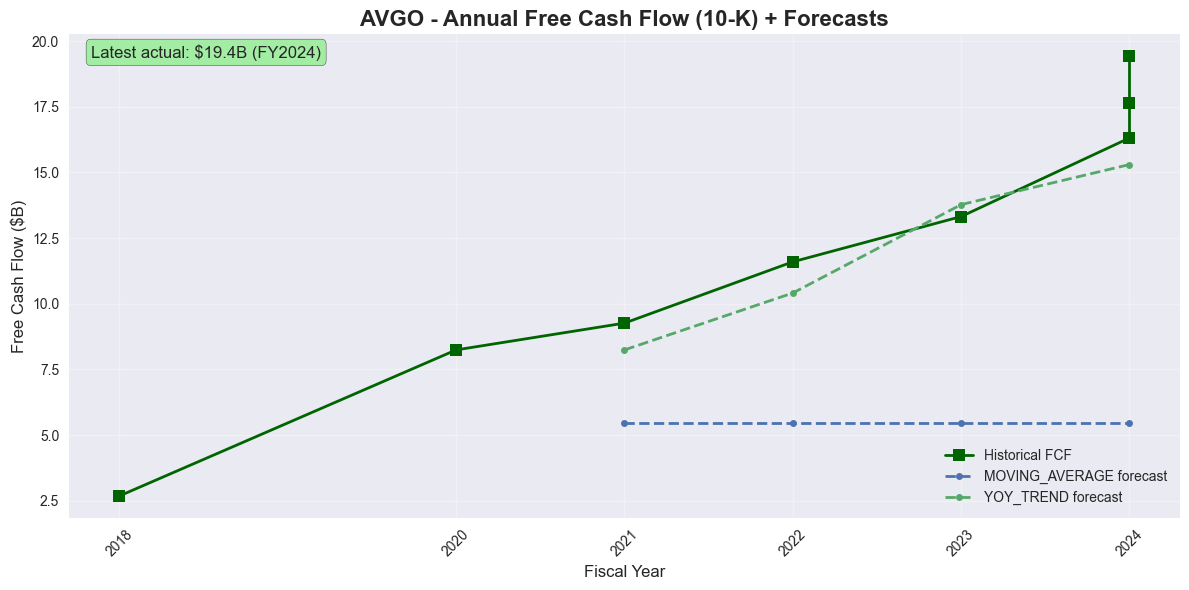

✓ AVGO: grafico 10-K con forecast salvato in result/AVGO_fcf_10K_with_models.png


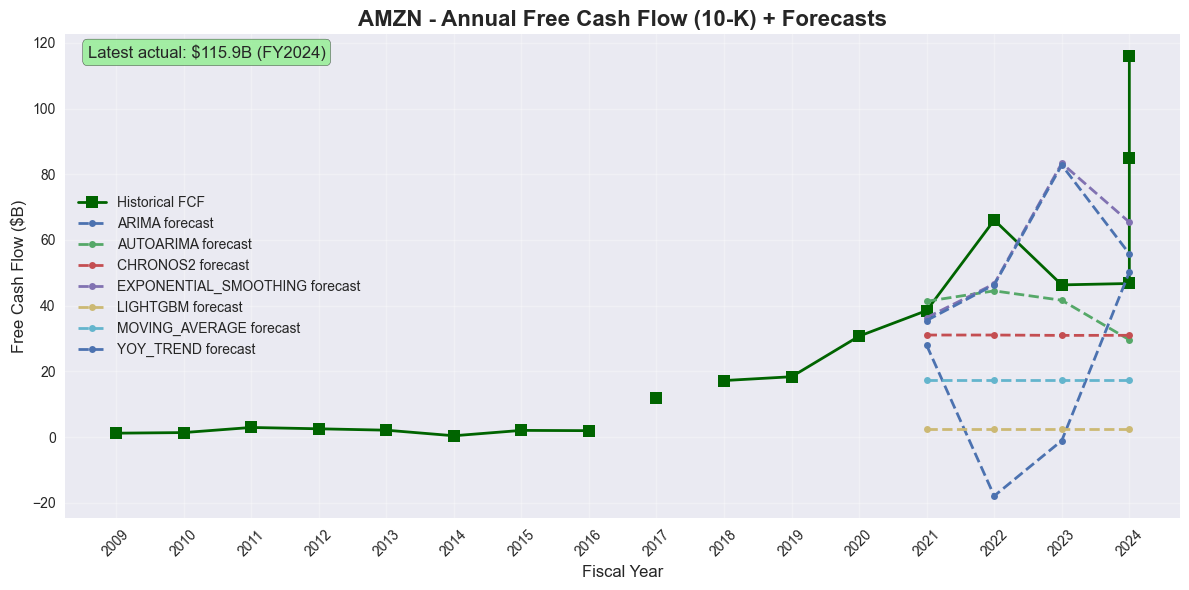

✓ AMZN: grafico 10-K con forecast salvato in result/AMZN_fcf_10K_with_models.png


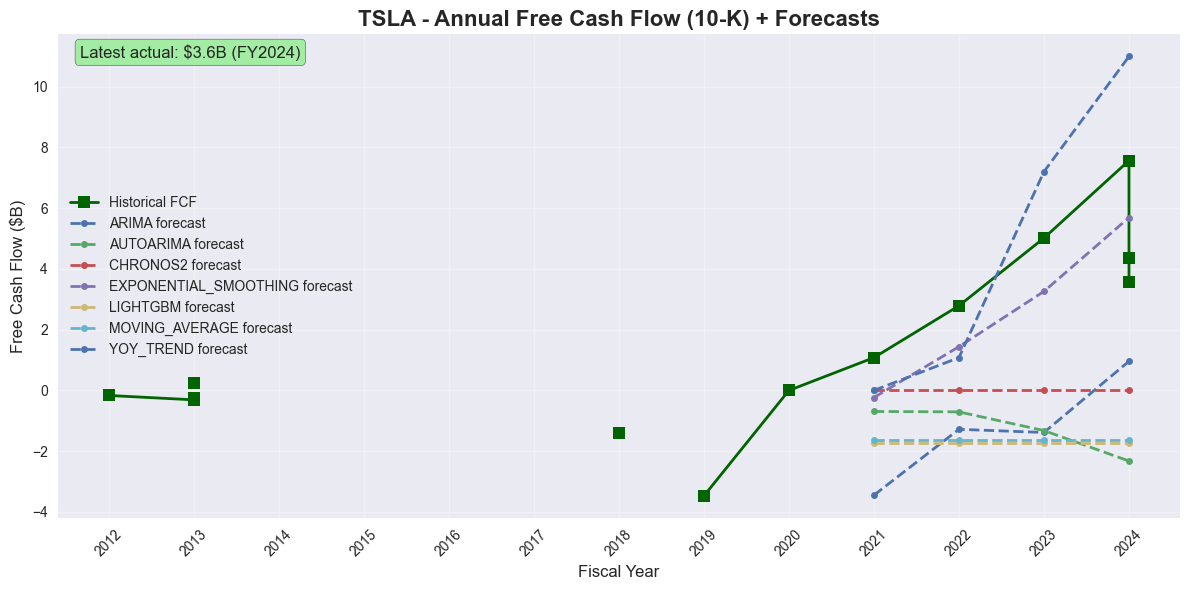

✓ TSLA: grafico 10-K con forecast salvato in result/TSLA_fcf_10K_with_models.png


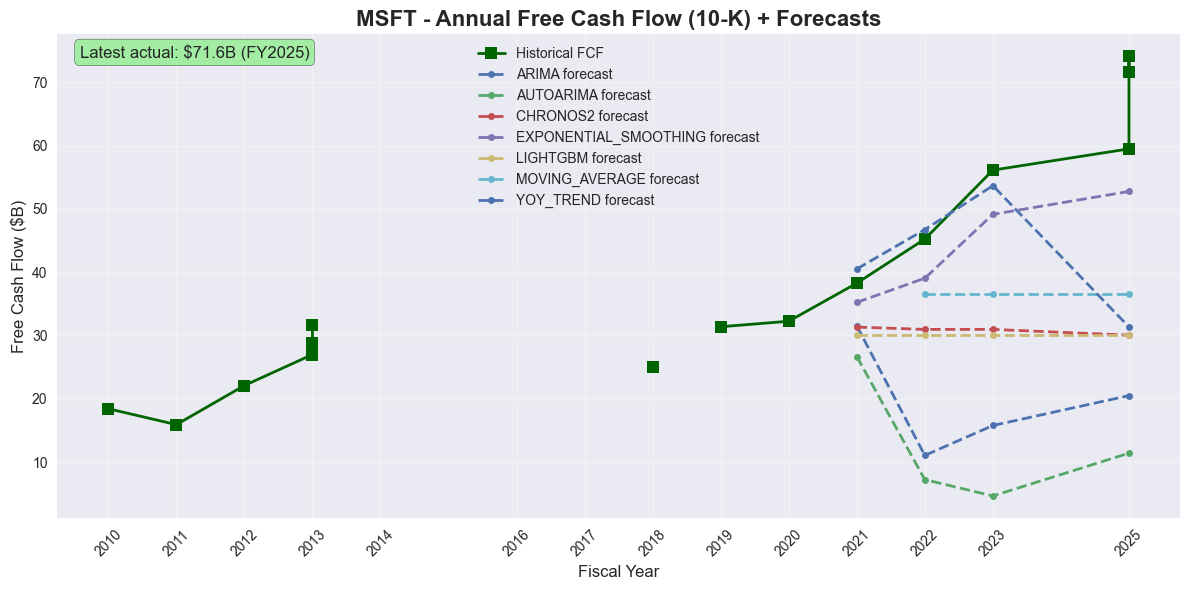

✓ MSFT: grafico 10-K con forecast salvato in result/MSFT_fcf_10K_with_models.png


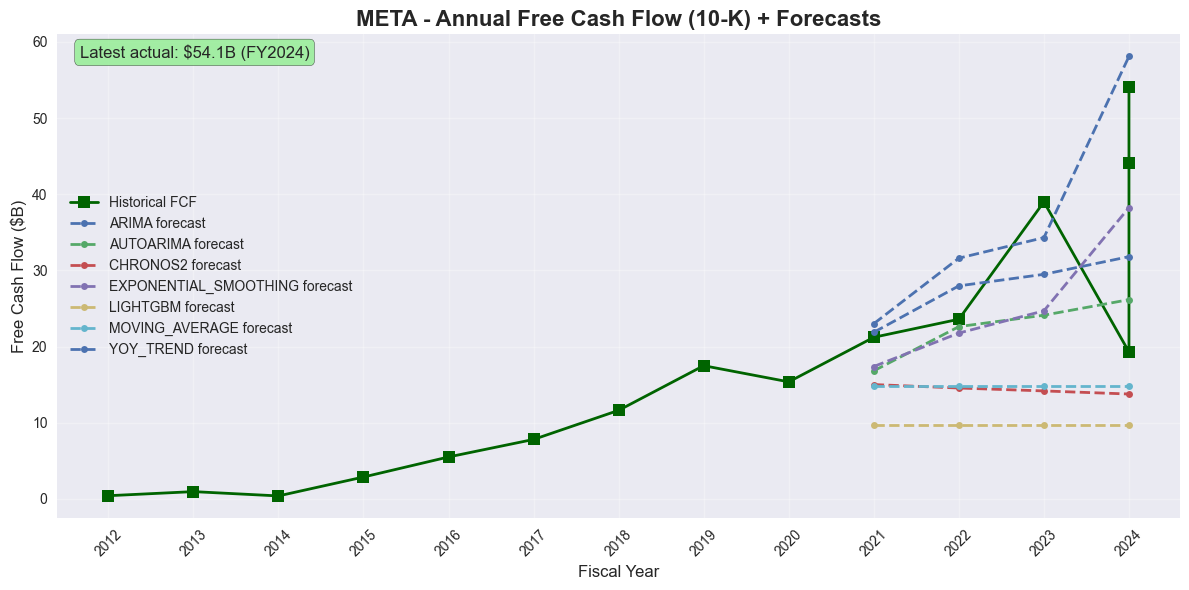

✓ META: grafico 10-K con forecast salvato in result/META_fcf_10K_with_models.png


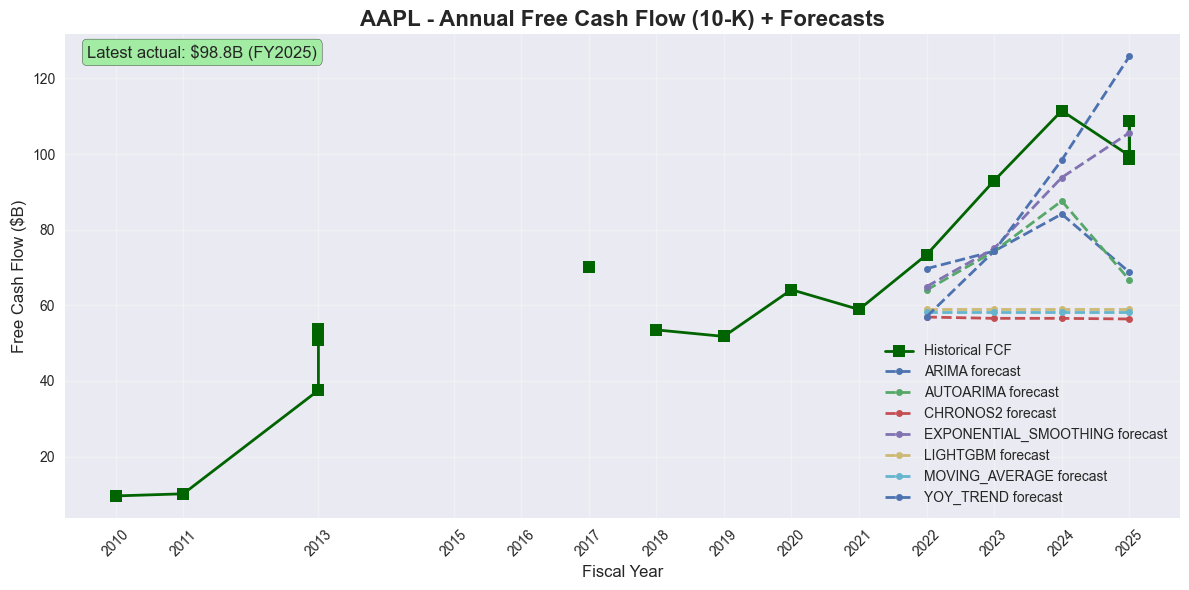

✓ AAPL: grafico 10-K con forecast salvato in result/AAPL_fcf_10K_with_models.png


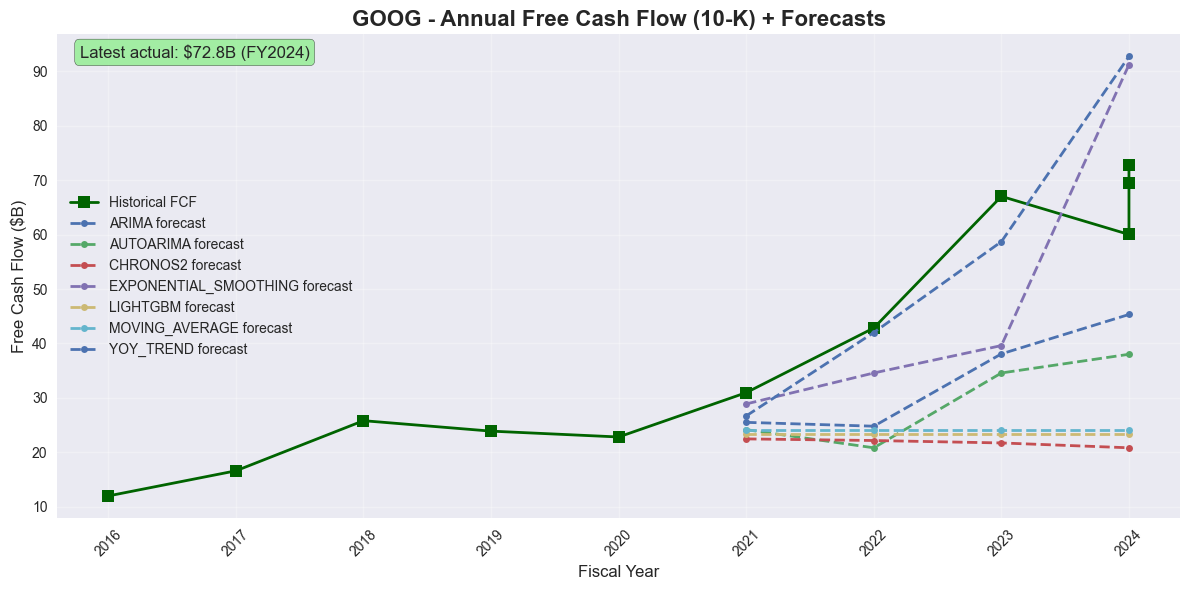

✓ GOOG: grafico 10-K con forecast salvato in result/GOOG_fcf_10K_with_models.png


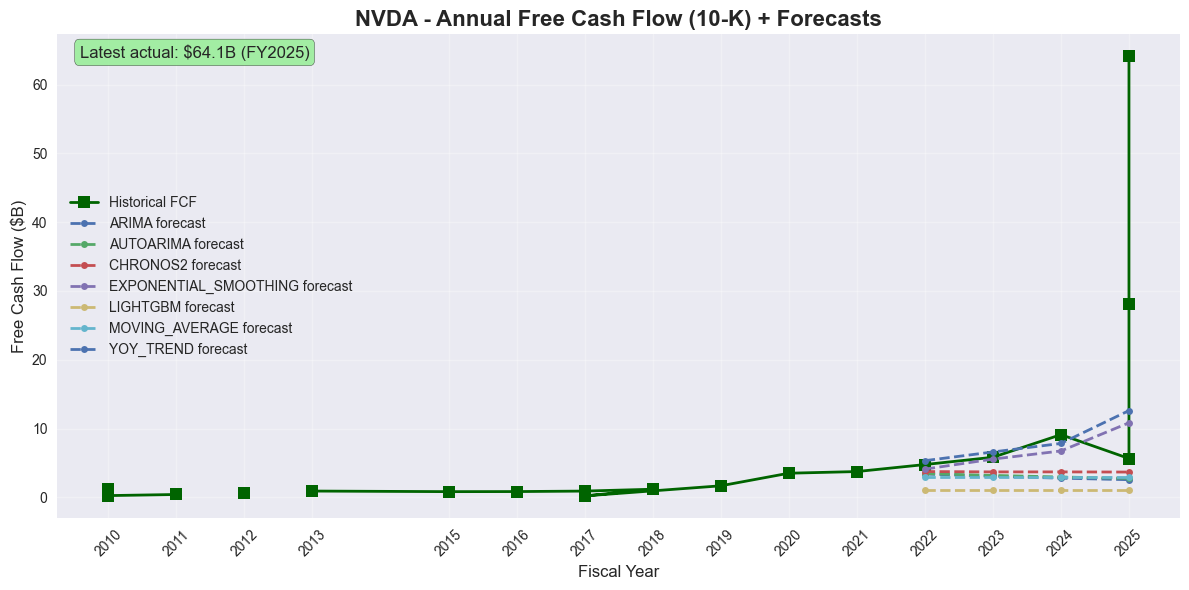

✓ NVDA: grafico 10-K con forecast salvato in result/NVDA_fcf_10K_with_models.png


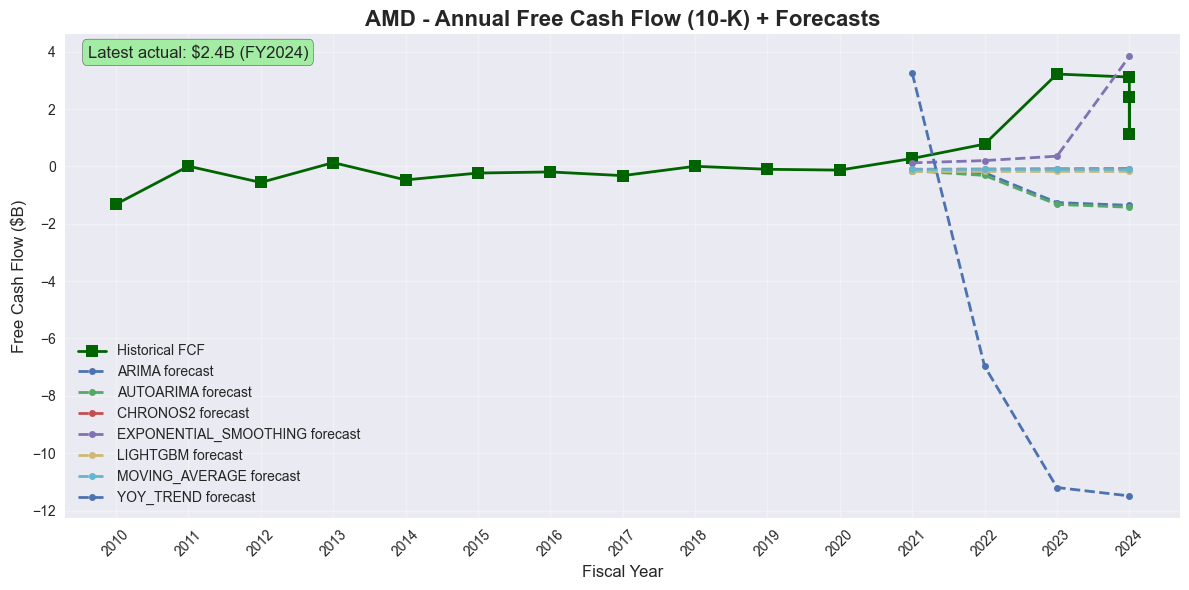

✓ AMD: grafico 10-K con forecast salvato in result/AMD_fcf_10K_with_models.png


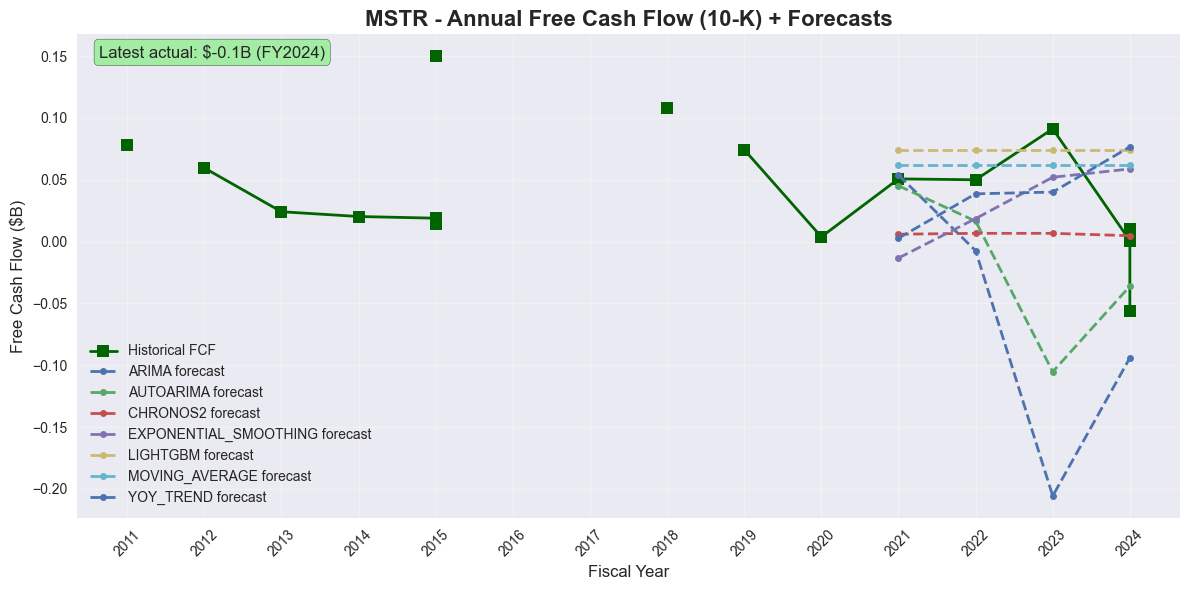

✓ MSTR: grafico 10-K con forecast salvato in result/MSTR_fcf_10K_with_models.png


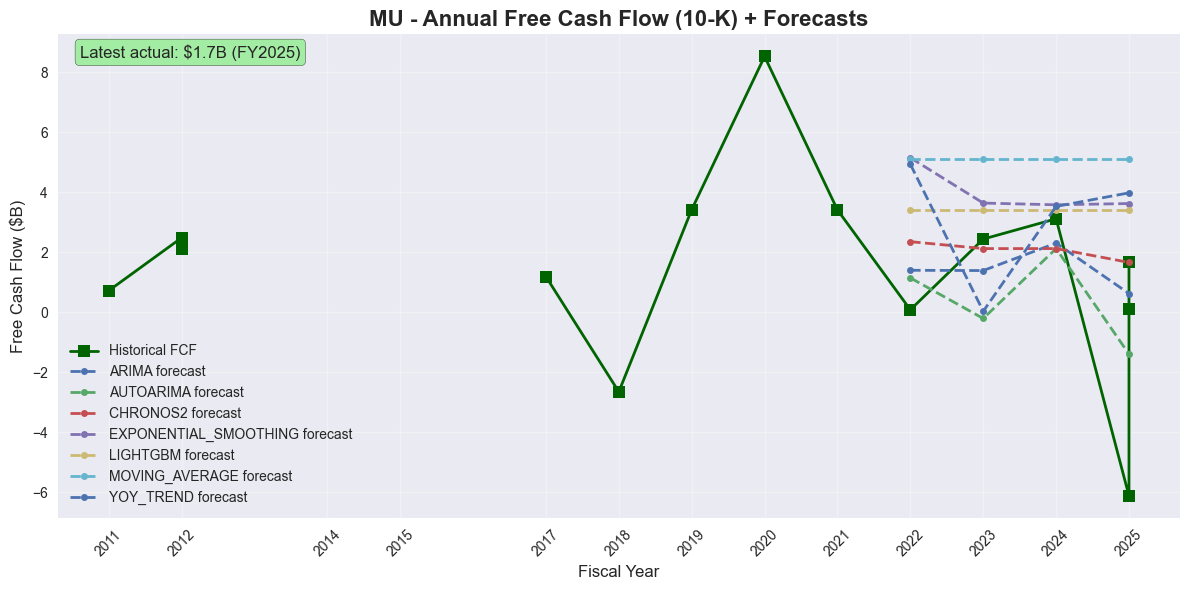

✓ MU: grafico 10-K con forecast salvato in result/MU_fcf_10K_with_models.png


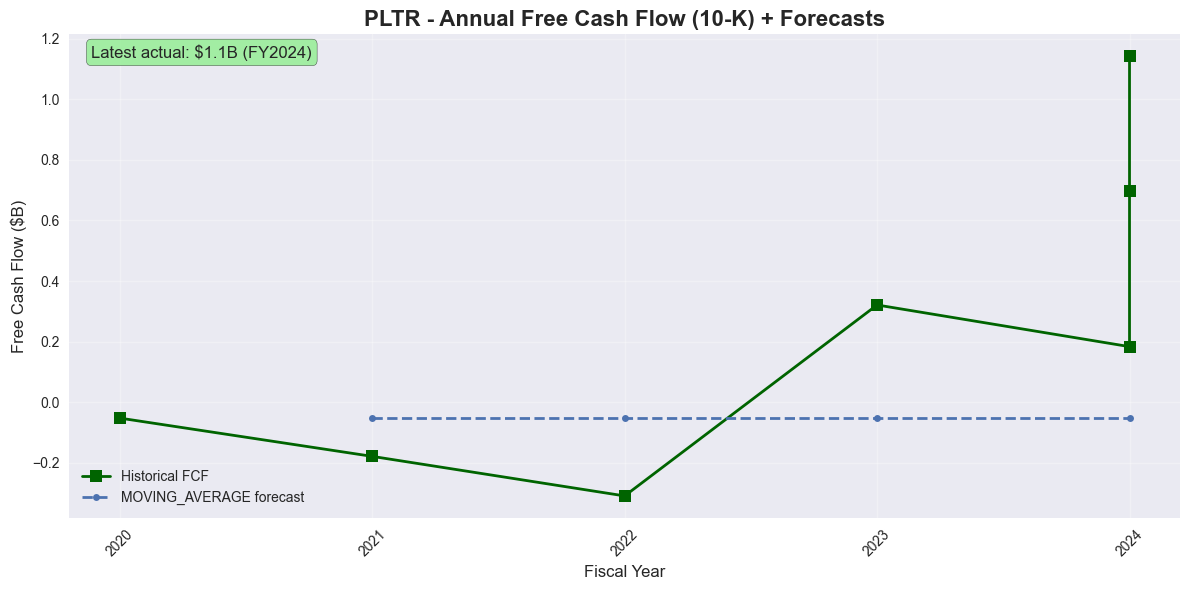

✓ PLTR: grafico 10-K con forecast salvato in result/PLTR_fcf_10K_with_models.png


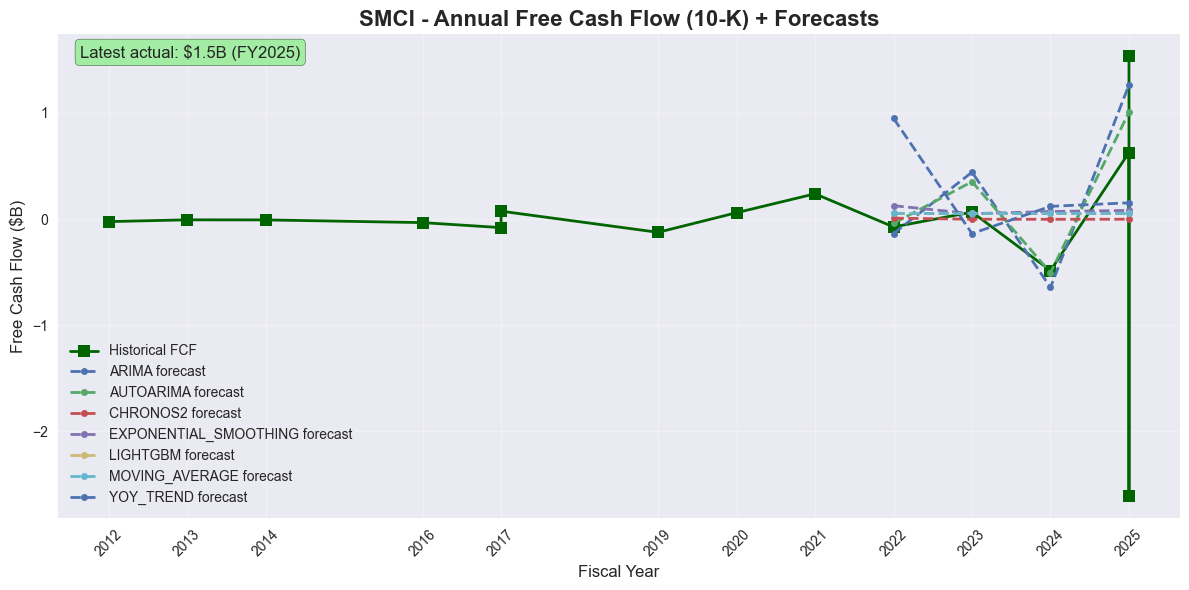

✓ SMCI: grafico 10-K con forecast salvato in result/SMCI_fcf_10K_with_models.png

✓ Tutti i grafici annuali (10-K) con previsioni completati


In [47]:
print("\n" + "=" * 80)
print("GENERAZIONE GRAFICI ANNUALI (10-K) CON PREVISIONI PER MODELLO")
print("=" * 80)

plt.style.use('seaborn-v0_8')

for ticker in TICKERS:
    hist_filename = os.path.join(HIST_DIR, f"{ticker}_fcf_10K.csv")

    if not os.path.exists(hist_filename):
        print(f"✗ {ticker}: File storico non trovato ({hist_filename})")
        continue

    # --- STORICO ---
    df_hist = pd.read_csv(hist_filename)
    if df_hist.empty:
        print(f"⚠ {ticker}: File storico 10-K vuoto")
        continue

    df_hist["end"] = pd.to_datetime(df_hist["end"])
    df_hist = df_hist.sort_values("end")
    df_hist["FCF_B"] = df_hist["Free Cash Flow"] / 1_000_000_000

    if "fy" in df_hist.columns:
        df_hist["fy"] = df_hist["fy"].astype(int)
    else:
        df_hist["fy"] = df_hist["end"].dt.year

    # --- CHECK: ESISTE ALMENO UNA PREVISIONE? ---
    has_any_predictions = False
    for model in MODELS:
        pred_filename = os.path.join(PRED_DIR, f"{ticker}_fcf_annual_predictions_{model}.csv")
        if os.path.exists(pred_filename):
            has_any_predictions = True
            break

    if not has_any_predictions:
        print(f"⏭ {ticker}: nessuna previsione trovata in '{PRED_DIR}' per i modelli {MODELS}, ticker skippato")
        continue

    # --- CREO LA FIGURA SOLO SE C'È ALMENO UNA PREVISIONE ---
    plt.figure(figsize=(12, 6))

    # Storico (asse X = anno fiscale)
    plt.plot(
        df_hist["fy"],
        df_hist["FCF_B"],
        marker="s",
        linewidth=2,
        markersize=8,
        color="darkgreen",
        label="Historical FCF"
    )

    # --- PREVISIONI PER MODELLO ---
    x_years = set(df_hist["fy"].tolist())

    for model in MODELS:
        pred_filename = os.path.join(PRED_DIR, f"{ticker}_fcf_annual_predictions_{model}.csv")

        if not os.path.exists(pred_filename):
            continue

        df_pred = pd.read_csv(pred_filename)
        if df_pred.empty:
            continue

        if "fy" not in df_pred.columns or "predicted" not in df_pred.columns:
            print(f"⚠ {ticker} - {model}: colonne attese 'fy' e 'predicted' non trovate in {pred_filename}")
            continue

        df_pred = df_pred.copy()
        df_pred["fy"] = df_pred["fy"].astype(int)
        df_pred = df_pred.sort_values("fy")
        df_pred["FCF_B"] = df_pred["predicted"] / 1_000_000_000

        x_years.update(df_pred["fy"].tolist())

        plt.plot(
            df_pred["fy"],
            df_pred["FCF_B"],
            linestyle="--",
            linewidth=2,
            marker="o",
            markersize=5,
            label=f"{model.upper()} forecast"
        )

    # Titolo e assi
    plt.title(f"{ticker} - Annual Free Cash Flow (10-K) + Forecasts", fontsize=16, fontweight="bold")
    plt.xlabel("Fiscal Year", fontsize=12)
    plt.ylabel("Free Cash Flow ($B)", fontsize=12)
    plt.grid(True, alpha=0.3)

    x_years = sorted(x_years)
    plt.xticks(x_years, rotation=45)

    # Box con ultimo storico
    last_row_hist = df_hist.sort_values("fy").iloc[-1]
    last_value_hist = last_row_hist["FCF_B"]
    last_year_hist = int(last_row_hist["fy"])
    plt.text(
        0.02,
        0.98,
        f"Latest actual: ${last_value_hist:.1f}B (FY{last_year_hist})",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.8)
    )

    plt.legend()
    plt.tight_layout()

    out_path = os.path.join("result", f"{ticker}_fcf_10K_with_models.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✓ {ticker}: grafico 10-K con forecast salvato in {out_path}")

print("\n✓ Tutti i grafici annuali (10-K) con previsioni completati")

In [48]:
def load_residuals(model: str, ticker: str) -> pd.Series | None:
    """
    Carica i residui annuali per (model, ticker) a partire dal file:
    result/{ticker}_fcf_annual_predictions_{model}.csv
    Restituisce una Series indicizzata per anno fiscale (fy).
    """
    path = os.path.join(PRED_DIR, f"{ticker}_fcf_annual_predictions_{model}.csv")
    if not os.path.exists(path):
        return None

    df = pd.read_csv(path)
    if not {"fy", "actual", "predicted"}.issubset(df.columns):
        return None

    df = df.sort_values("fy").copy()
    df["fy"] = df["fy"].astype(int)
    df["resid"] = df["actual"] - df["predicted"]

    # residui standardizzati stile statsmodels
    std = df["resid"].std(ddof=1)
    if std == 0 or np.isnan(std):
        resid_std = df["resid"] * 0.0
    else:
        resid_std = (df["resid"] - df["resid"].mean()) / std

    resid_std.index = df["fy"]
    return resid_std


RESIDUAL PLOTS (standardized residuals)


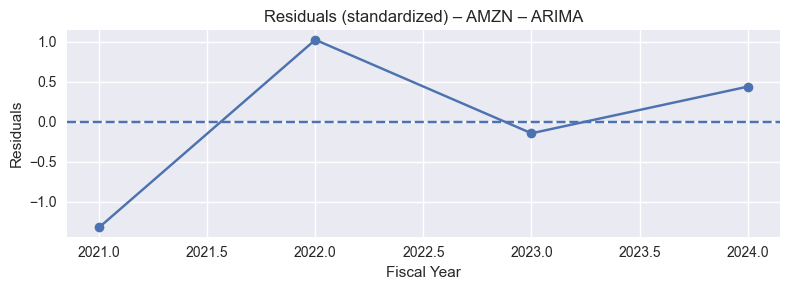

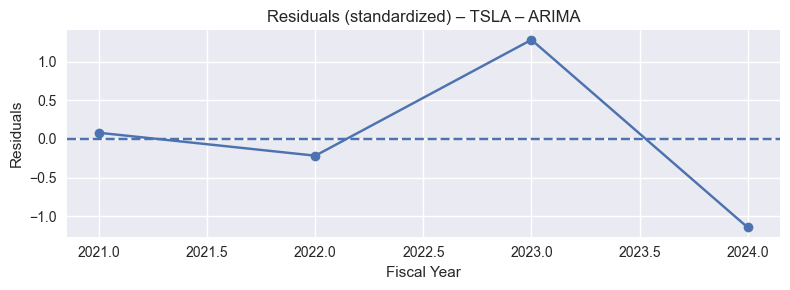

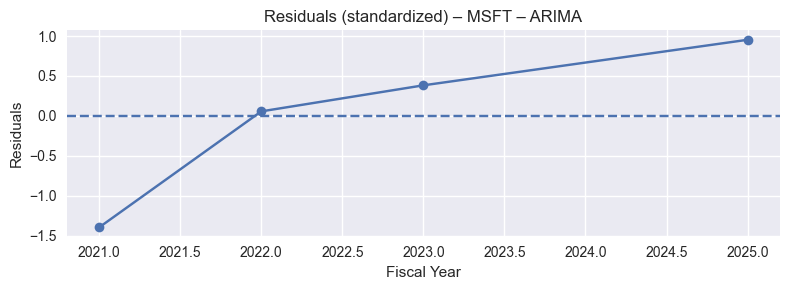

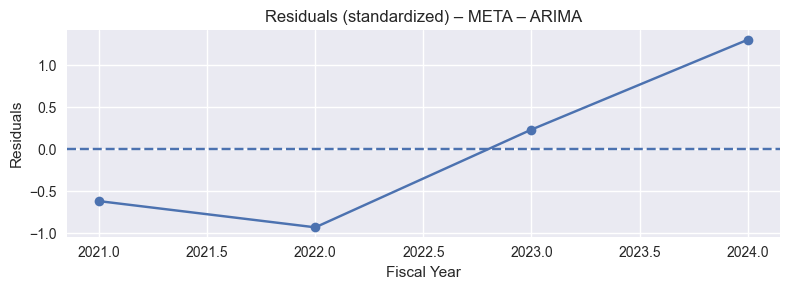

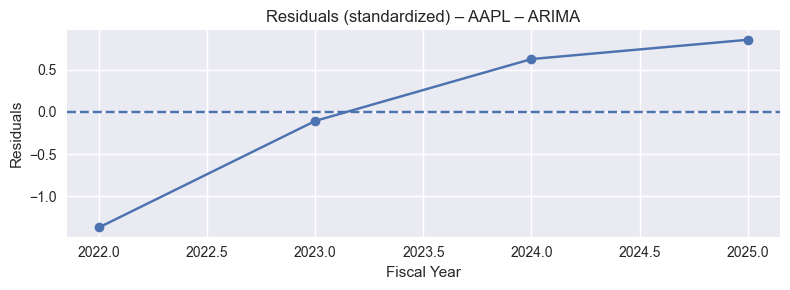

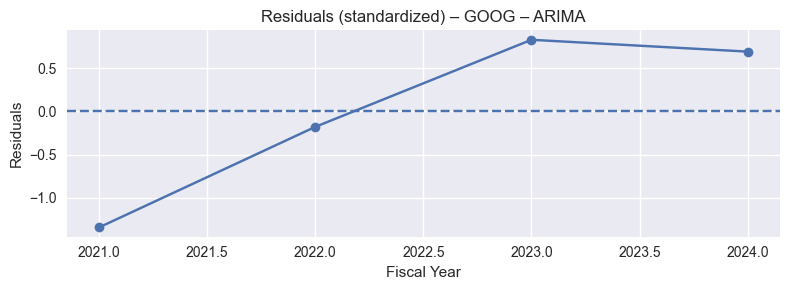

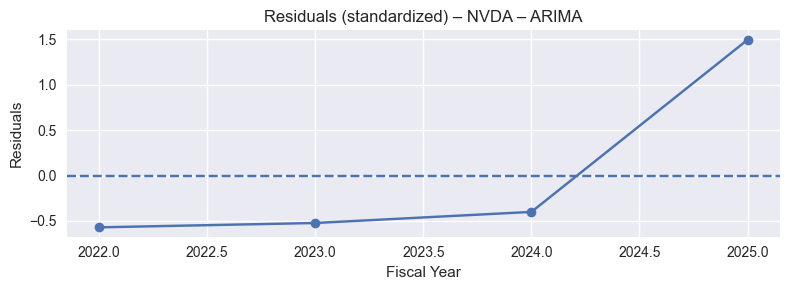

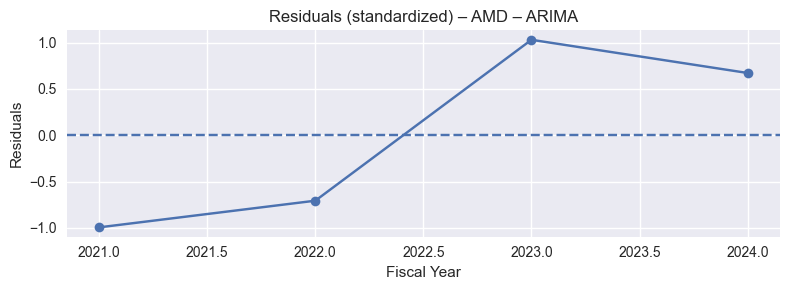

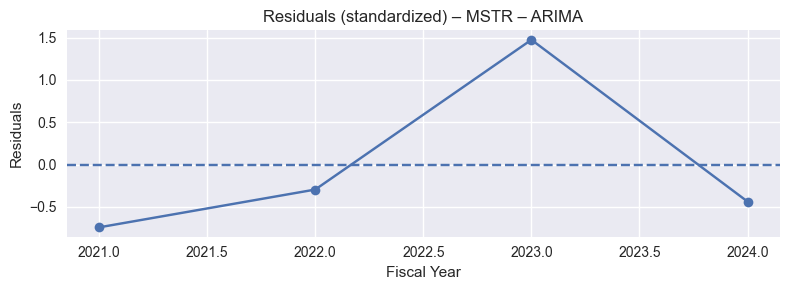

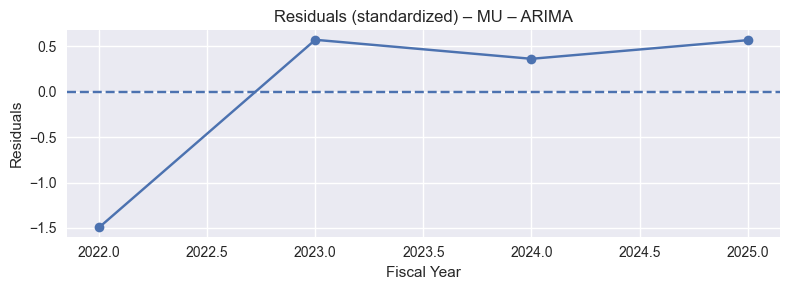

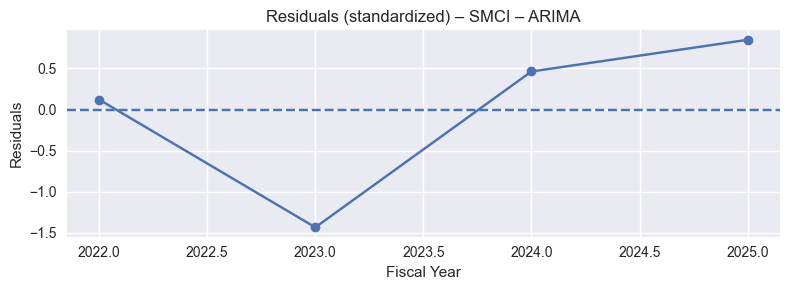

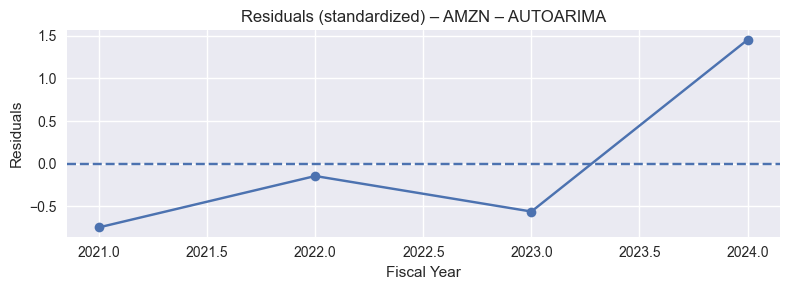

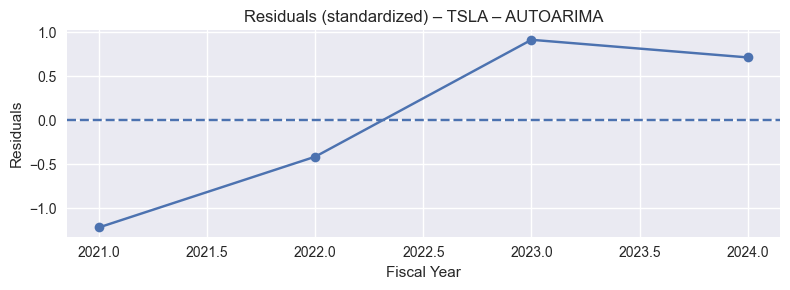

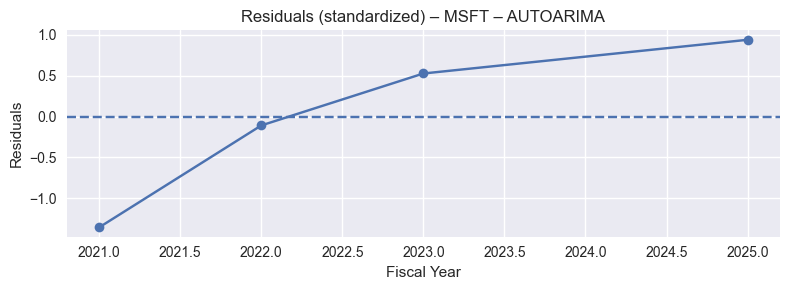

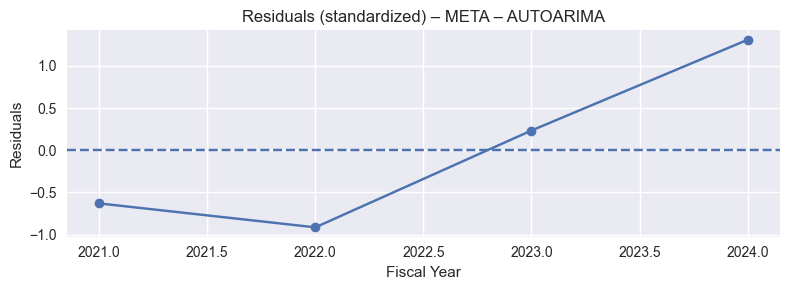

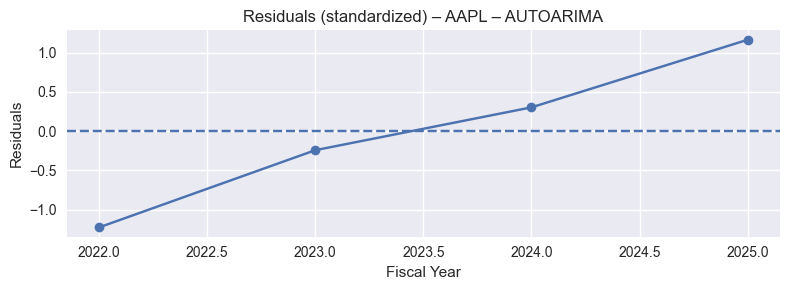

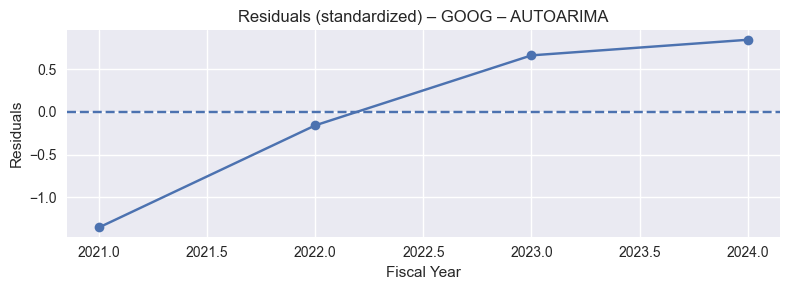

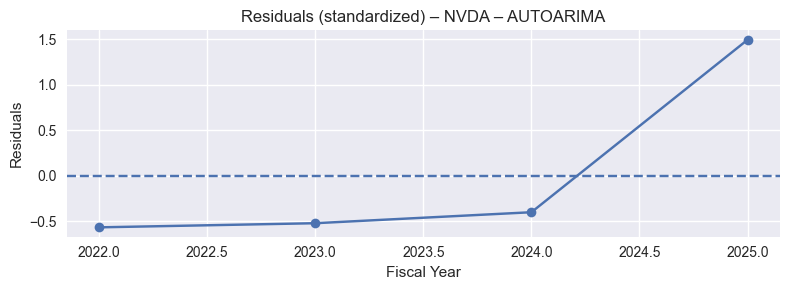

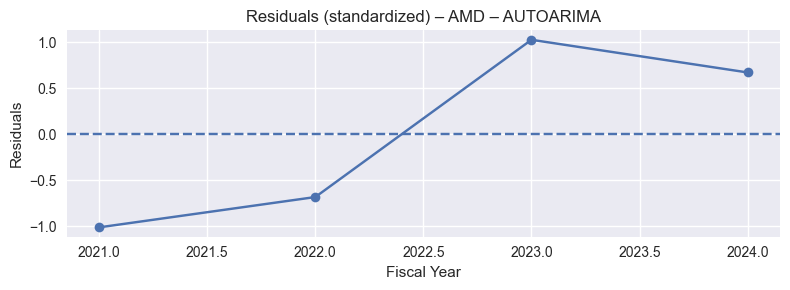

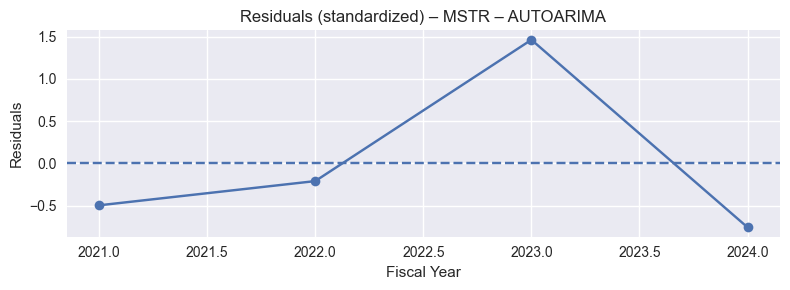

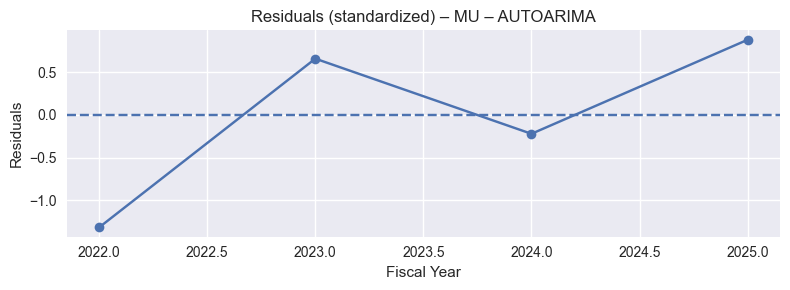

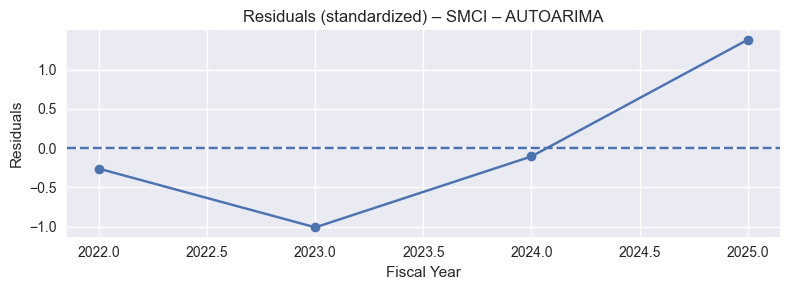

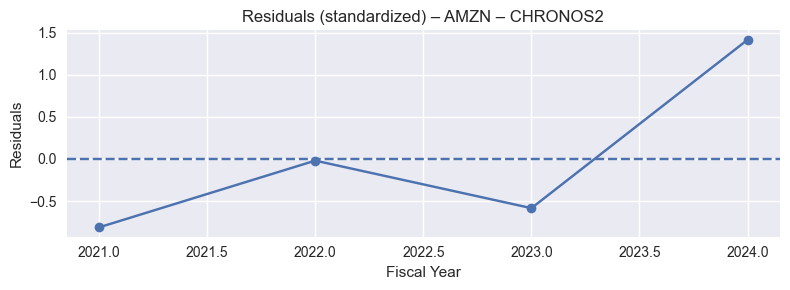

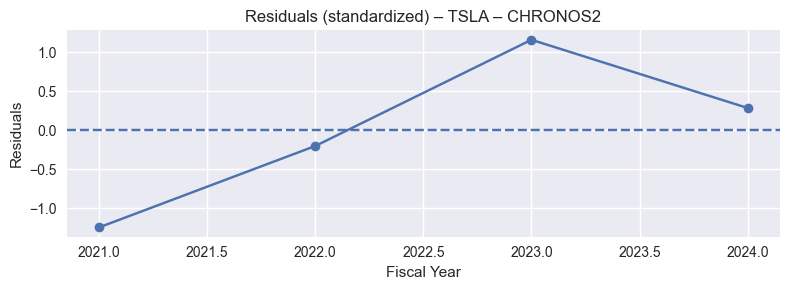

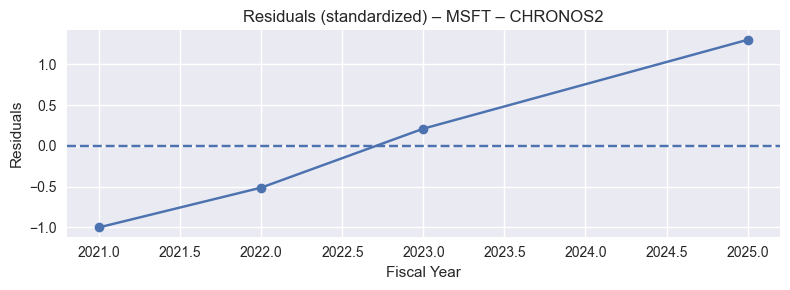

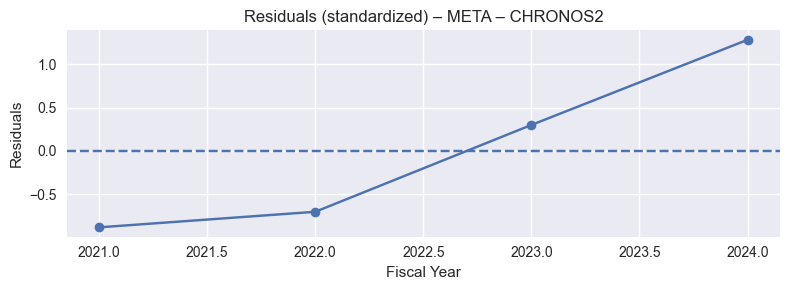

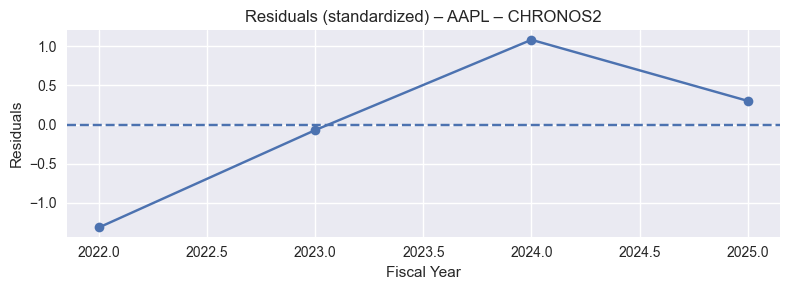

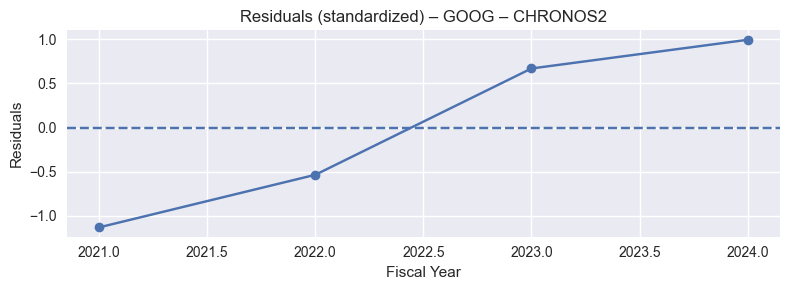

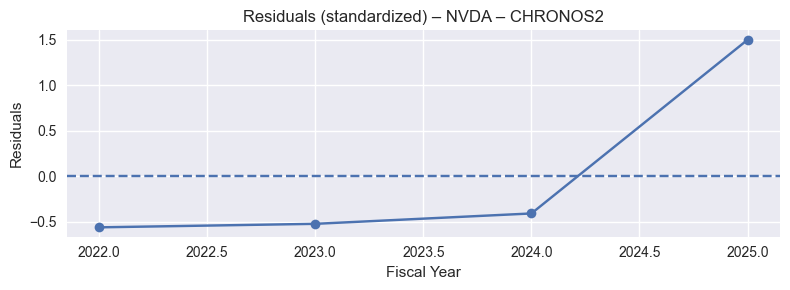

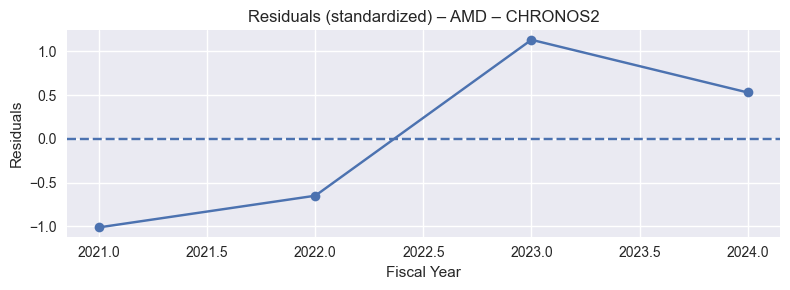

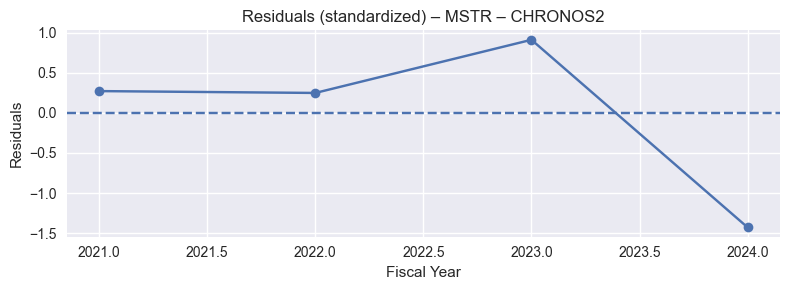

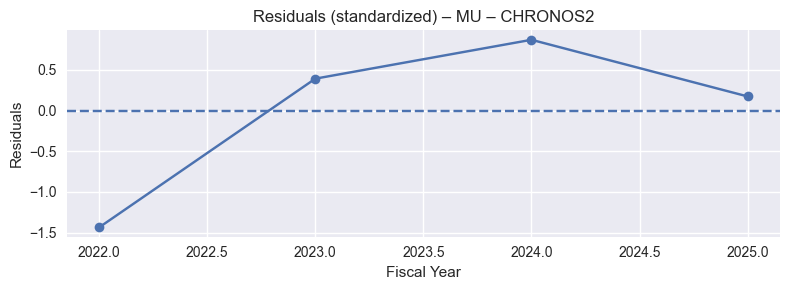

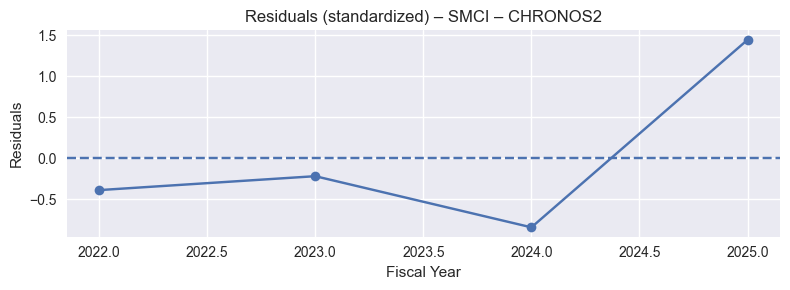

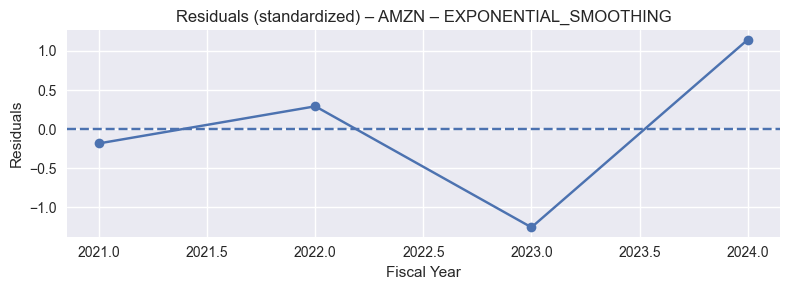

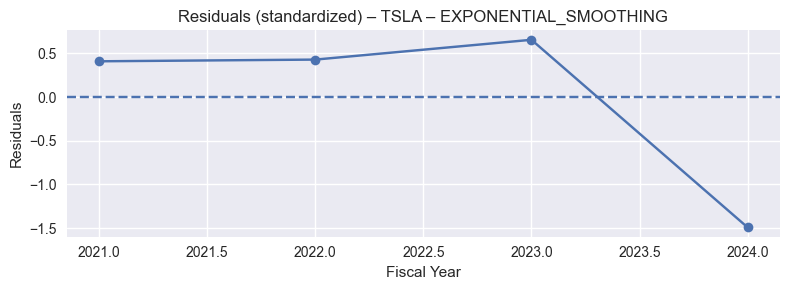

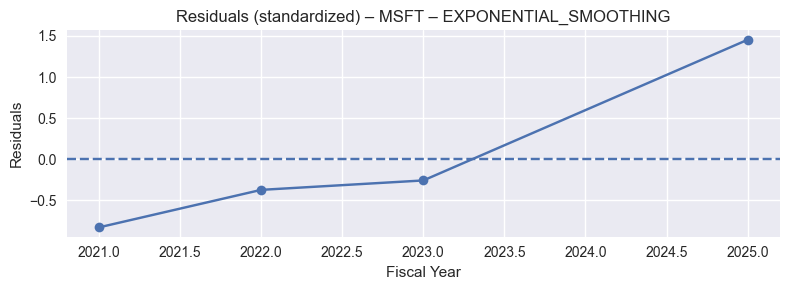

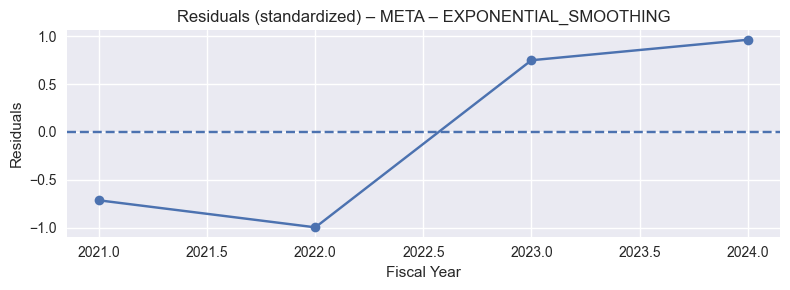

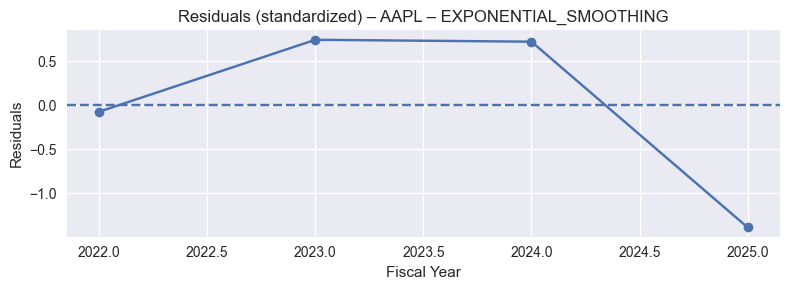

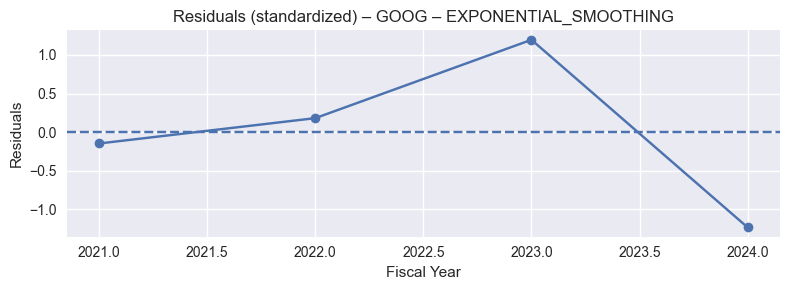

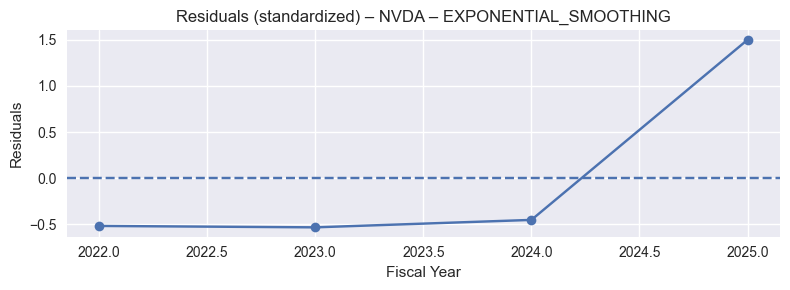

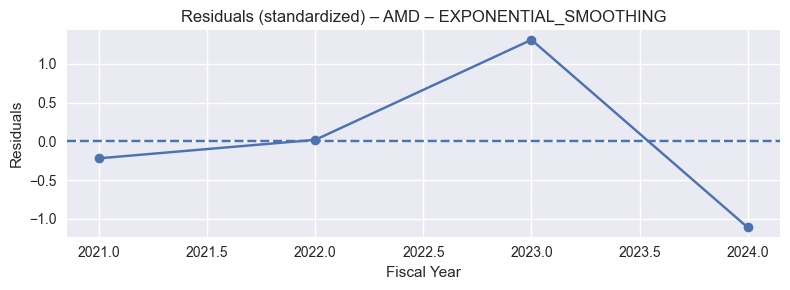

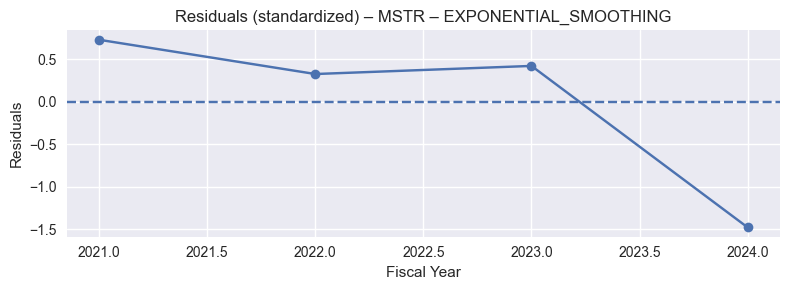

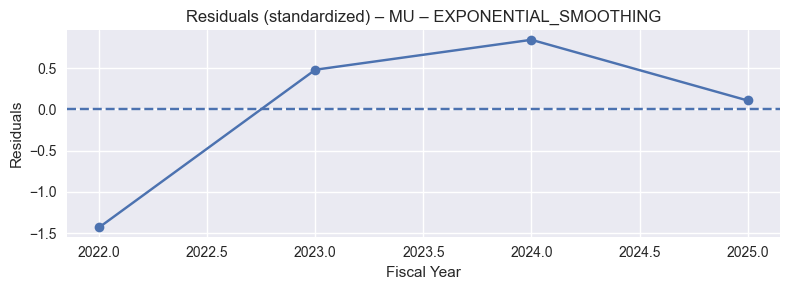

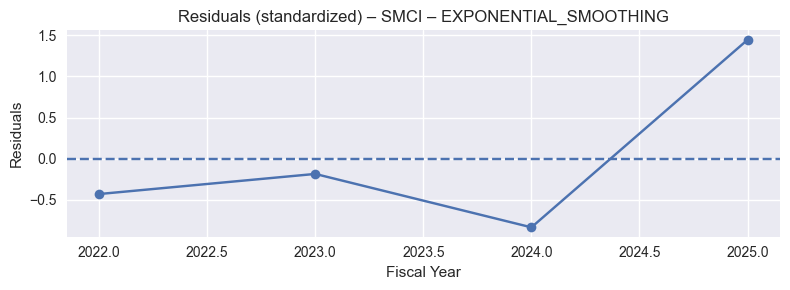

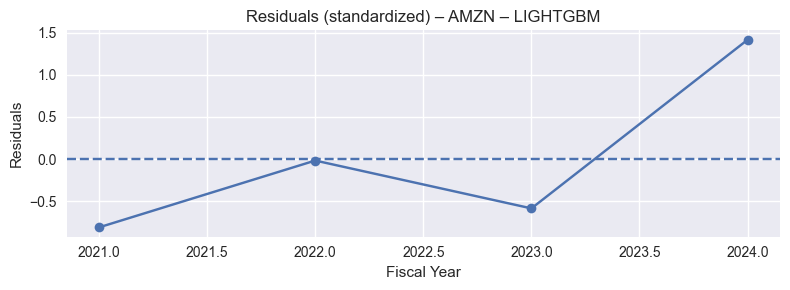

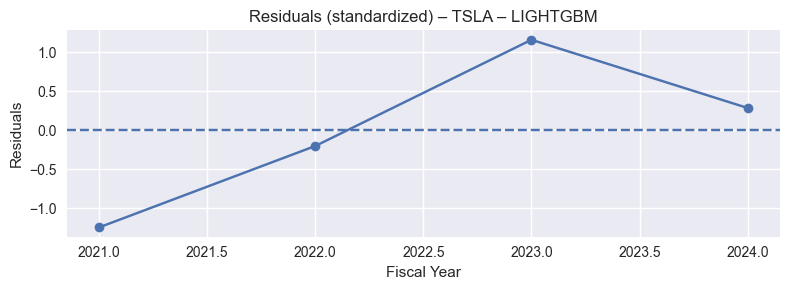

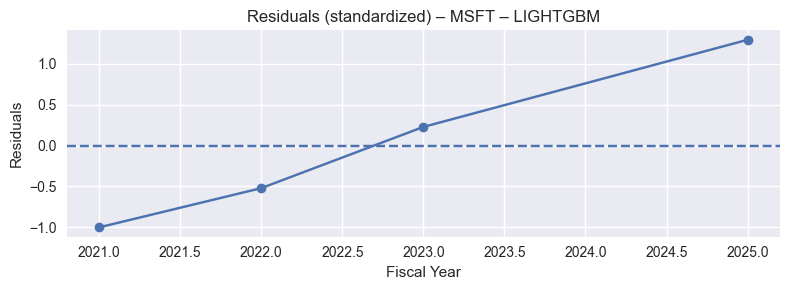

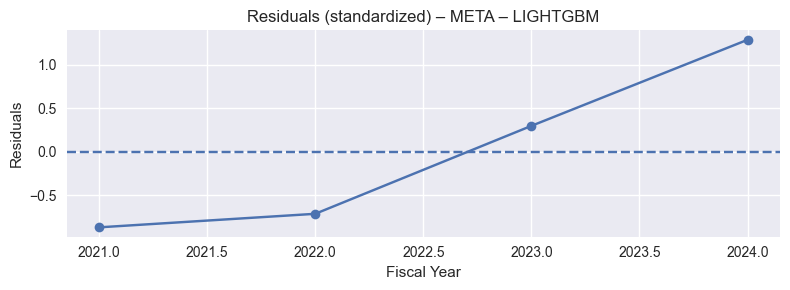

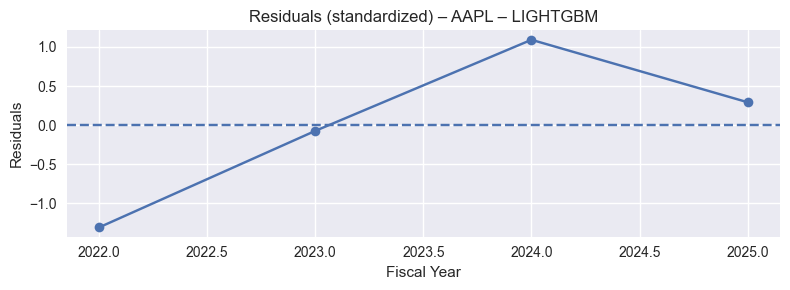

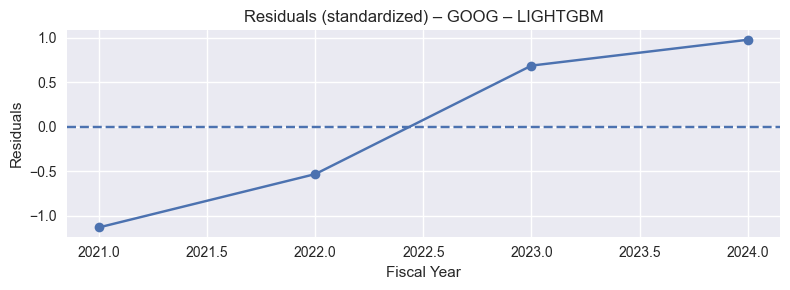

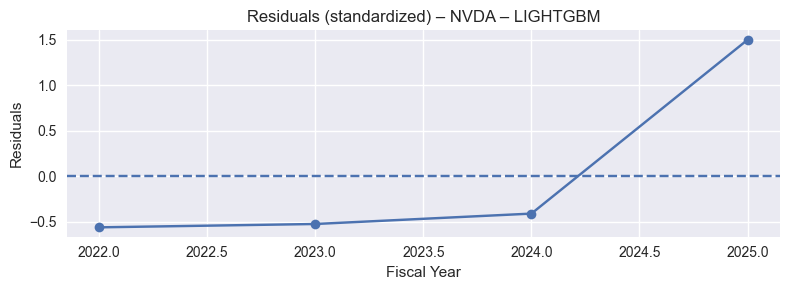

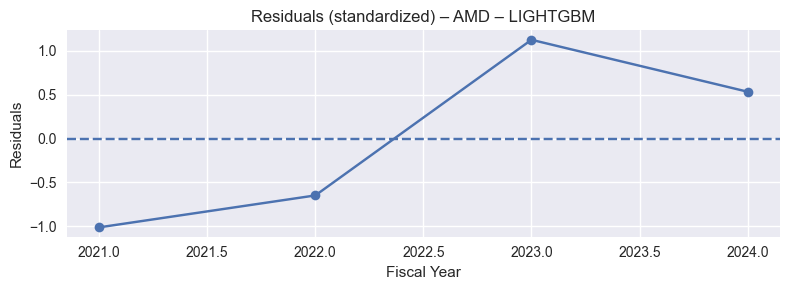

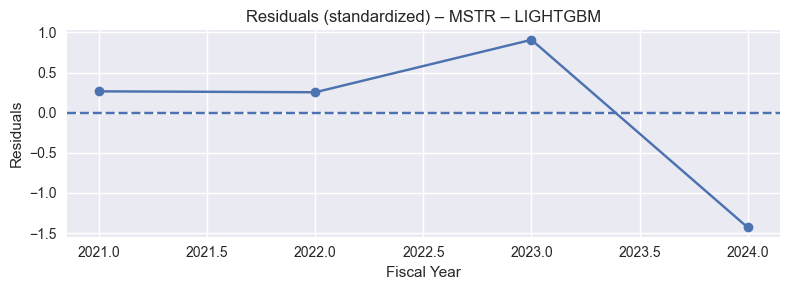

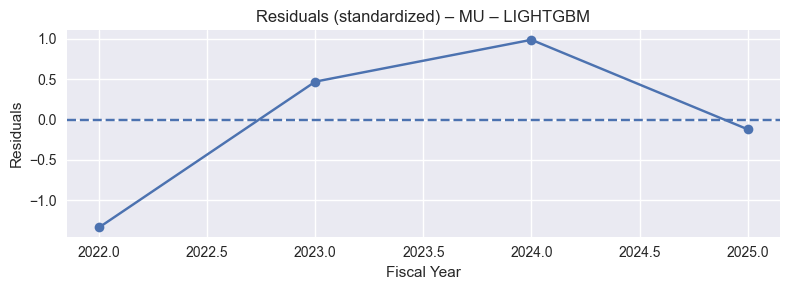

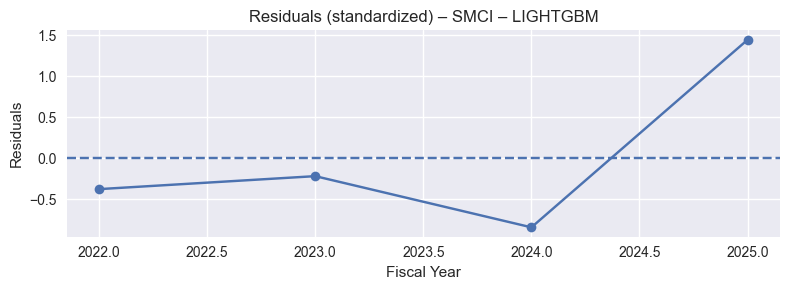

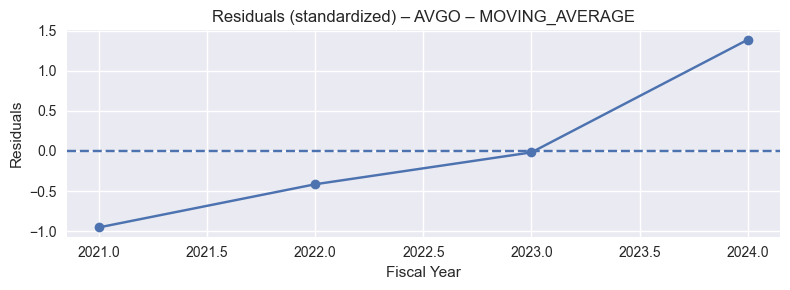

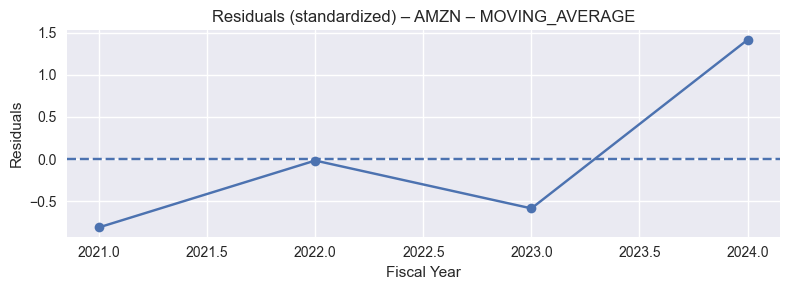

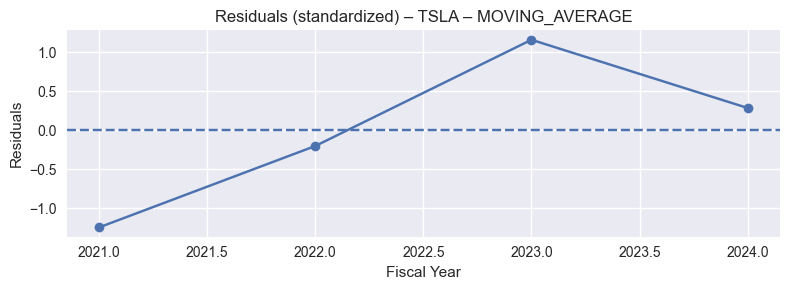

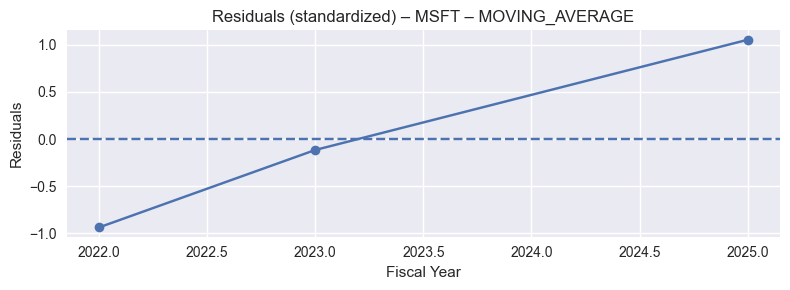

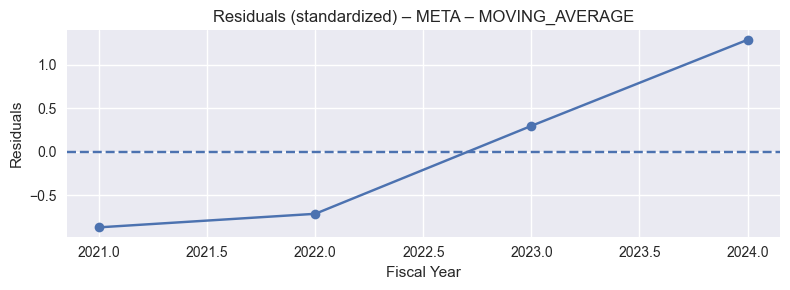

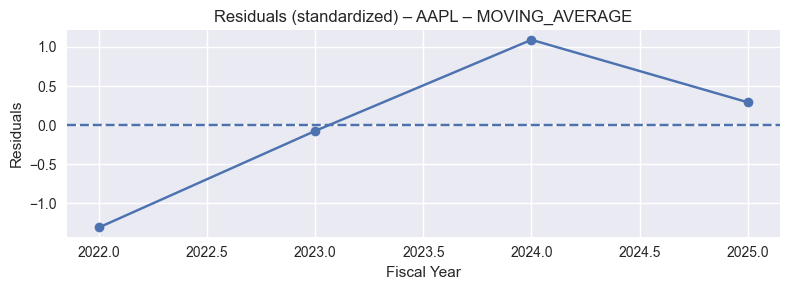

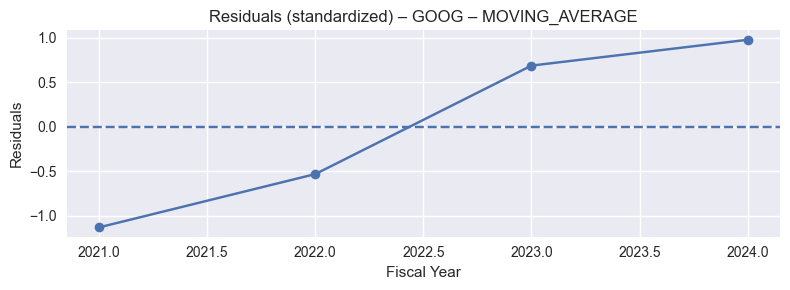

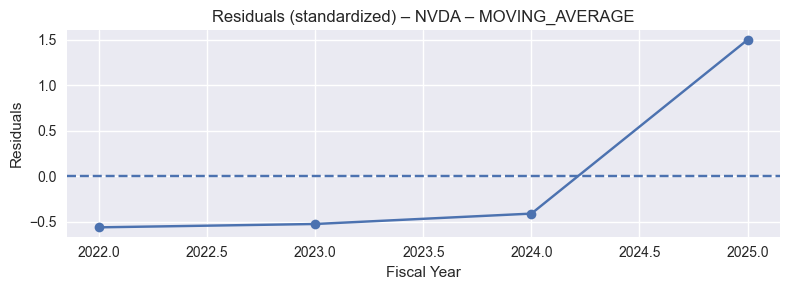

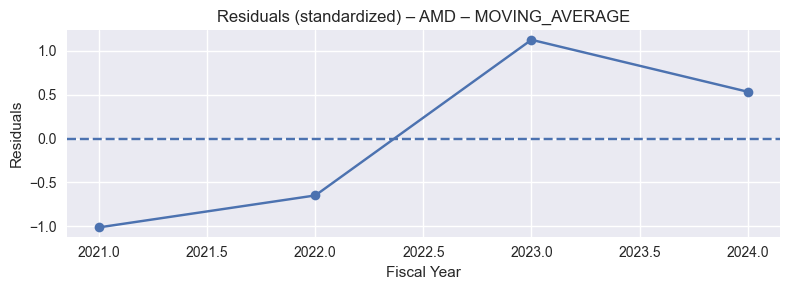

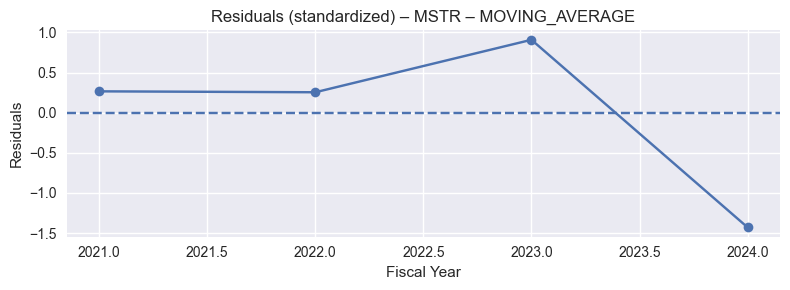

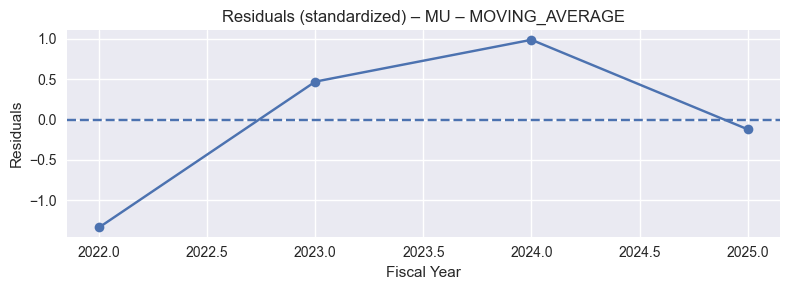

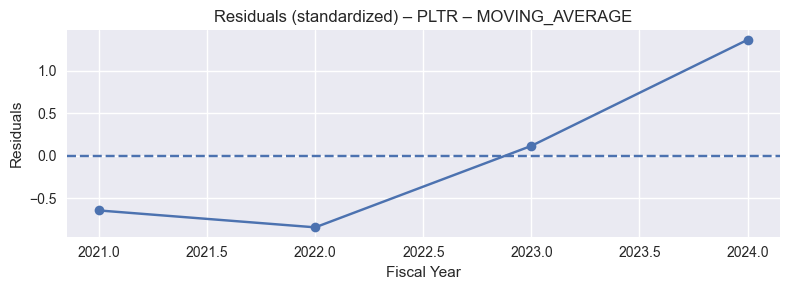

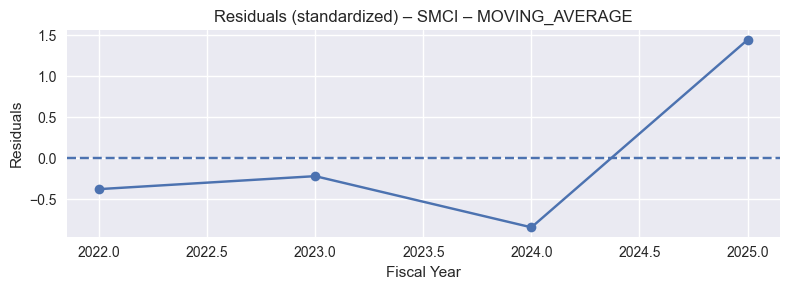

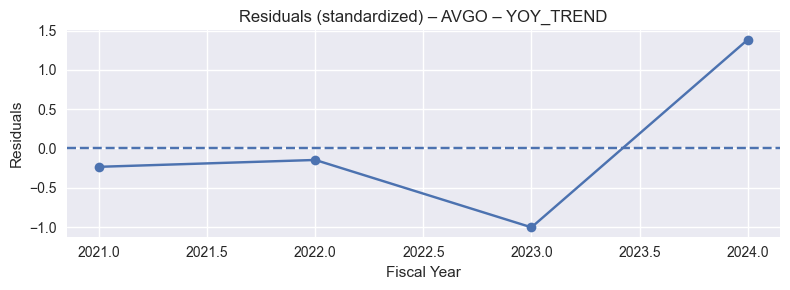

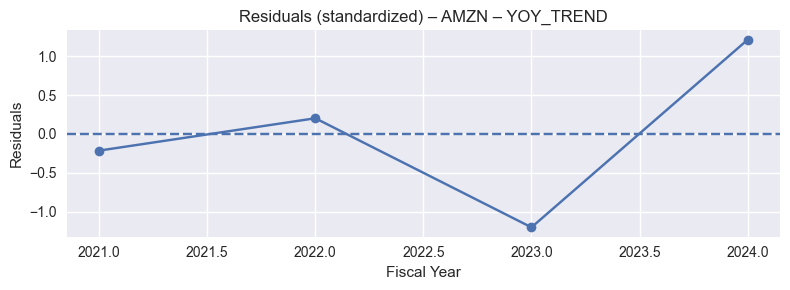

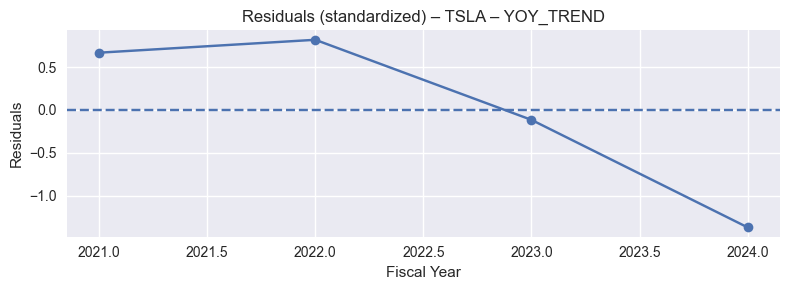

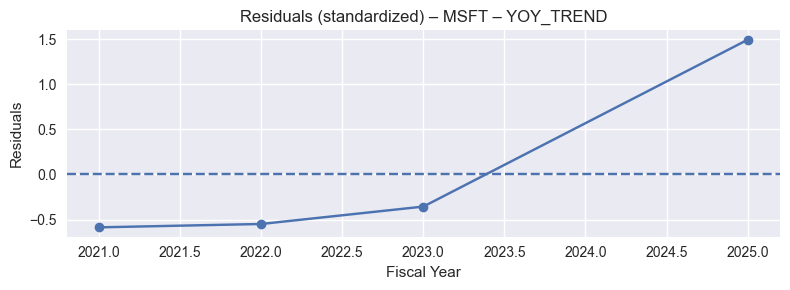

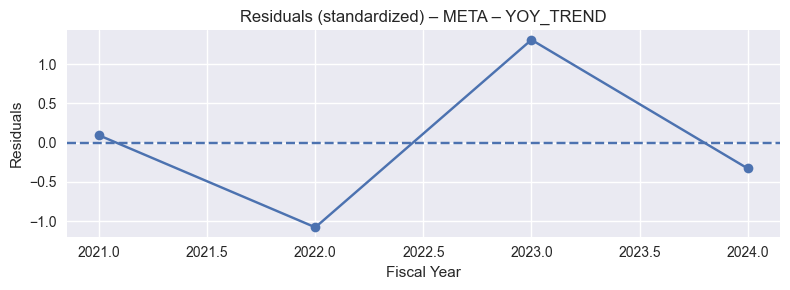

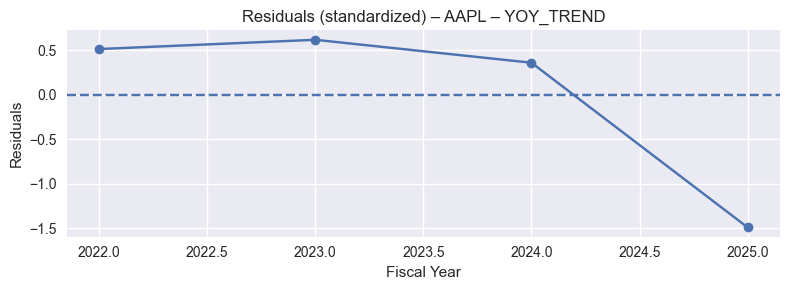

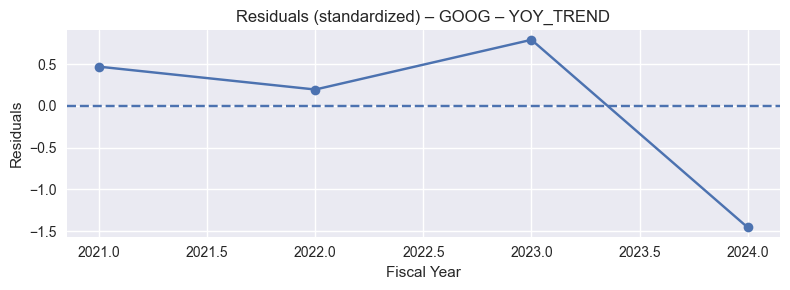

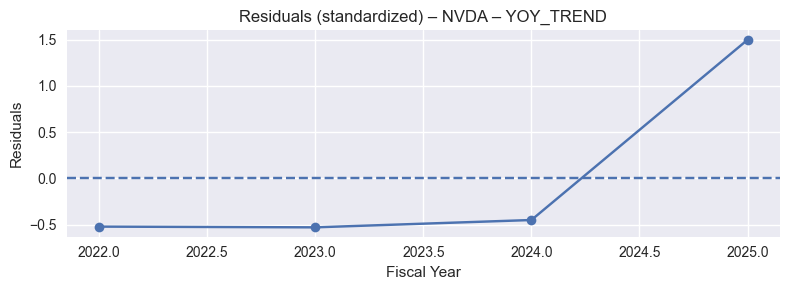

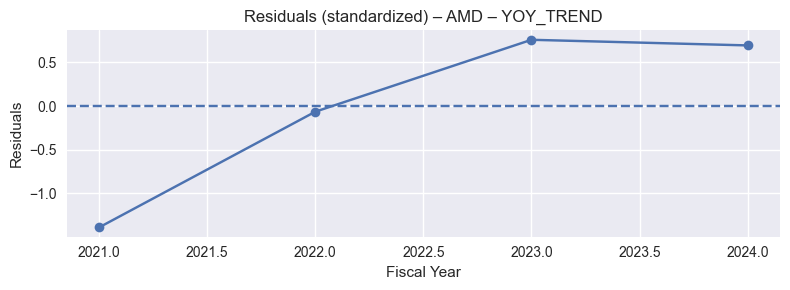

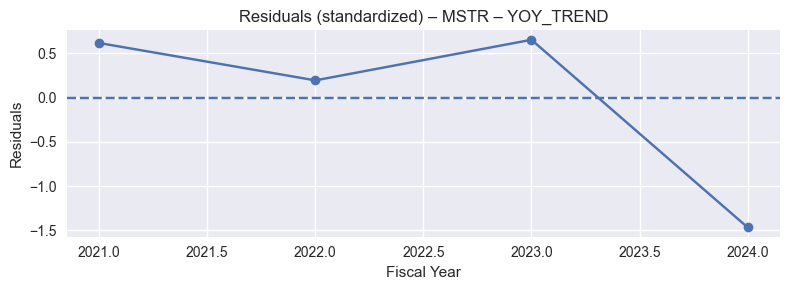

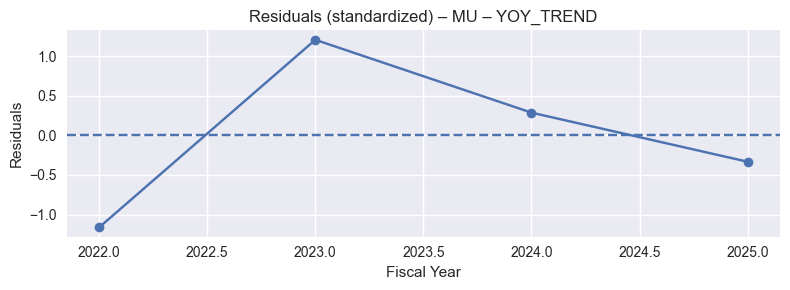

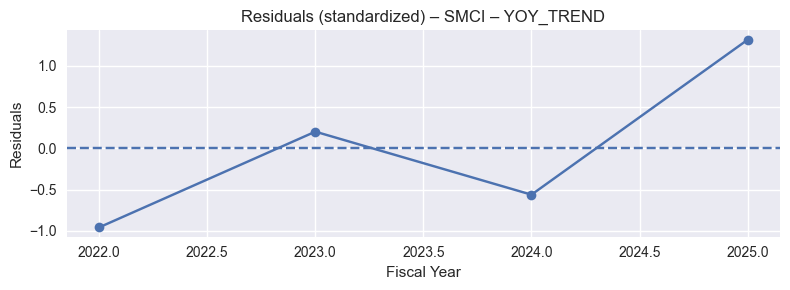

In [49]:
print("\nRESIDUAL PLOTS (standardized residuals)")
print("=" * 80)

for model in MODELS:
    for ticker in TICKERS:
        resid = load_residuals(model, ticker)
        if resid is None or resid.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(resid.index, resid.values, marker="o")
        ax.axhline(0.0, linestyle="--")
        ax.set_title(f"Residuals (standardized) – {ticker} – {model.upper()}")
        ax.set_xlabel("Fiscal Year")
        ax.set_ylabel("Residuals")
        fig.tight_layout()
        plt.show()


ACF/PACF DEI RESIDUI


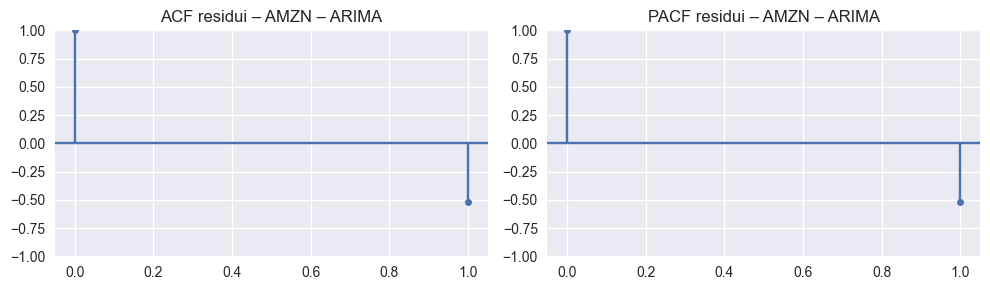

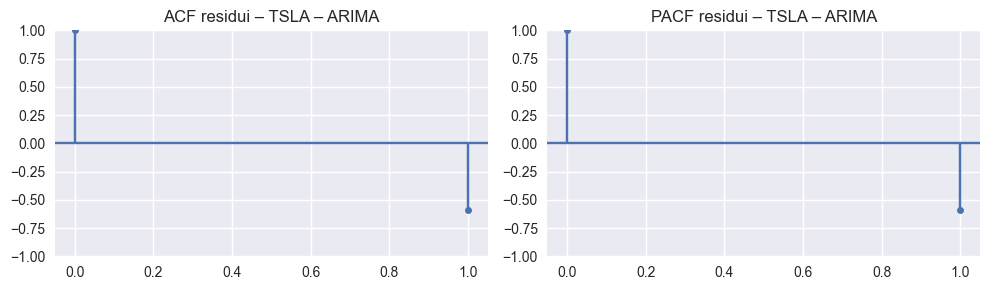

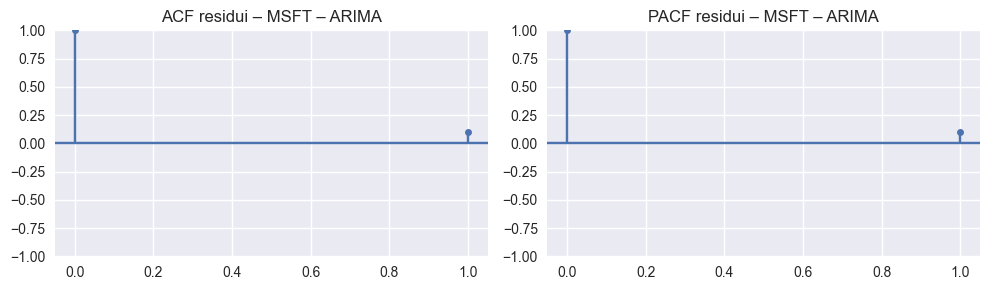

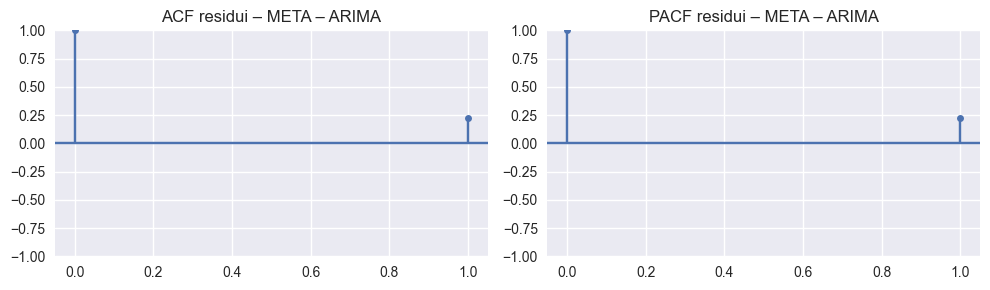

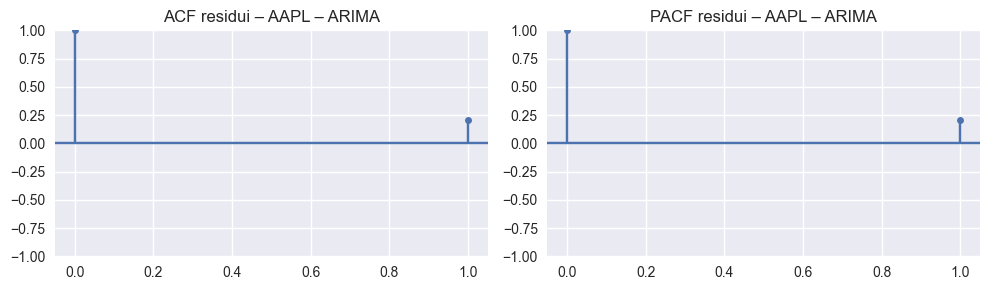

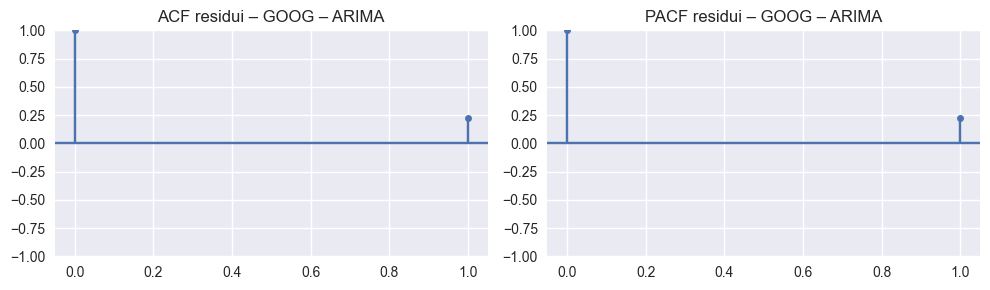

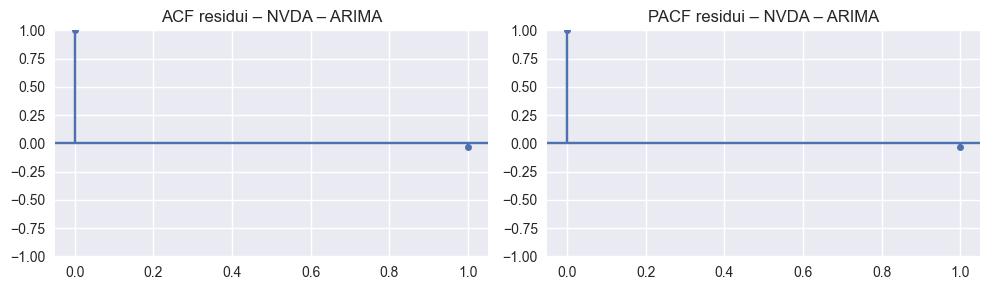

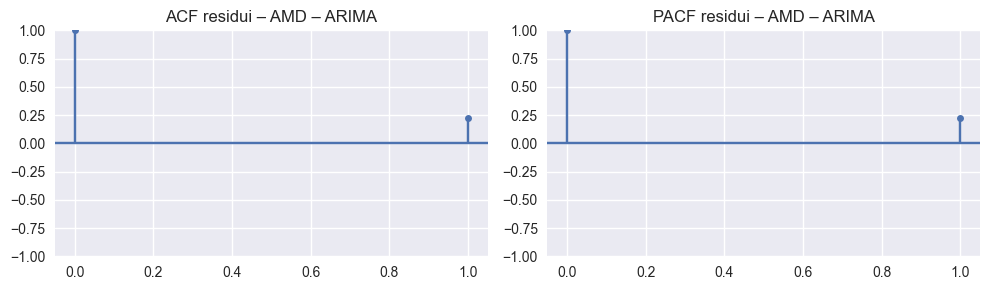

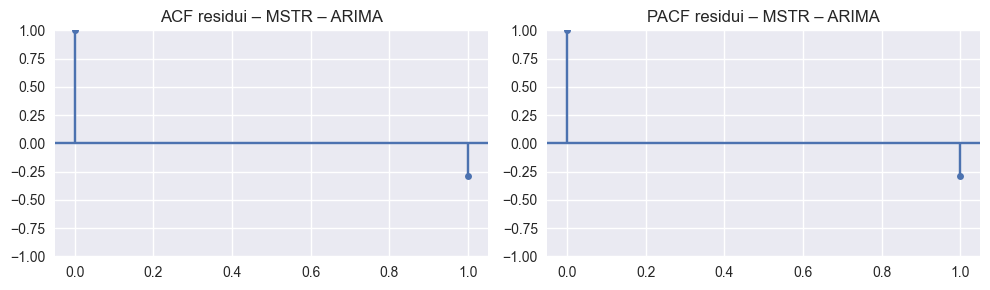

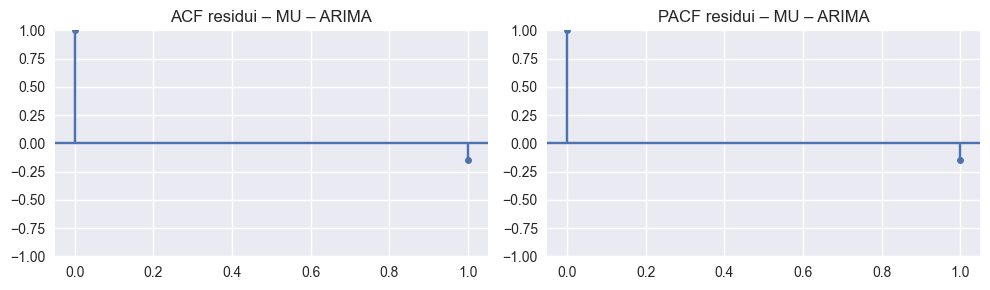

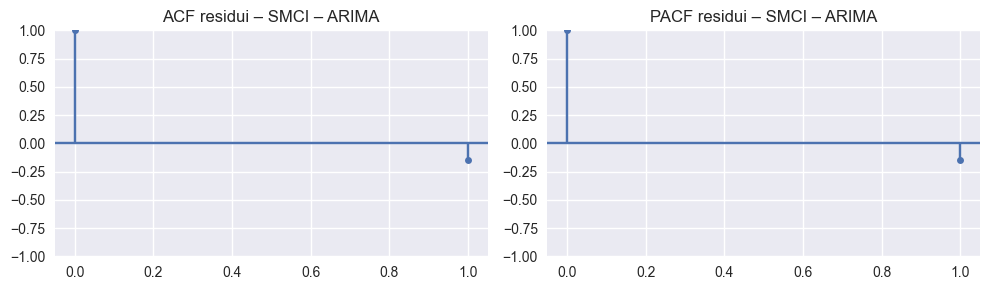

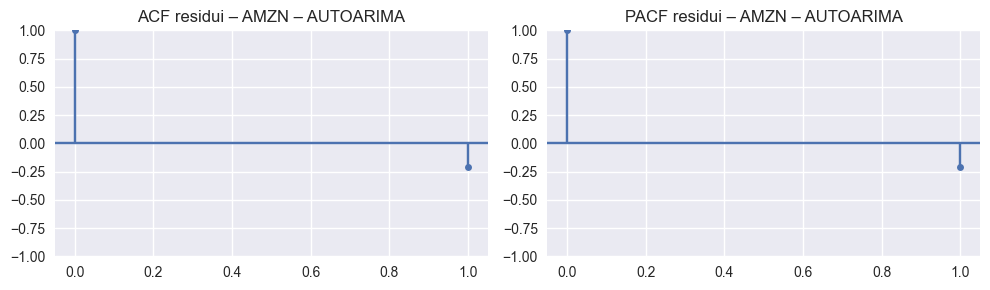

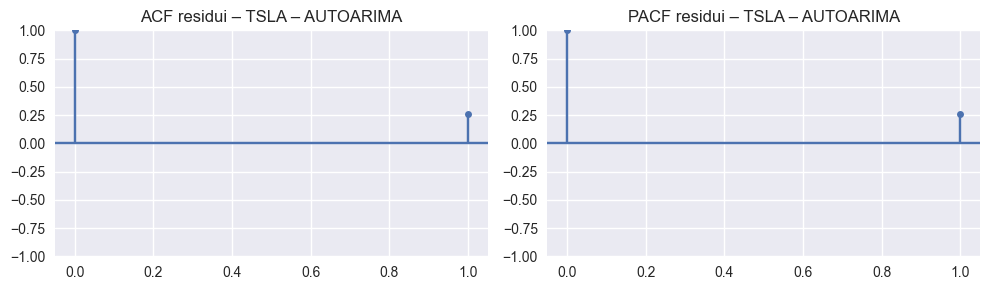

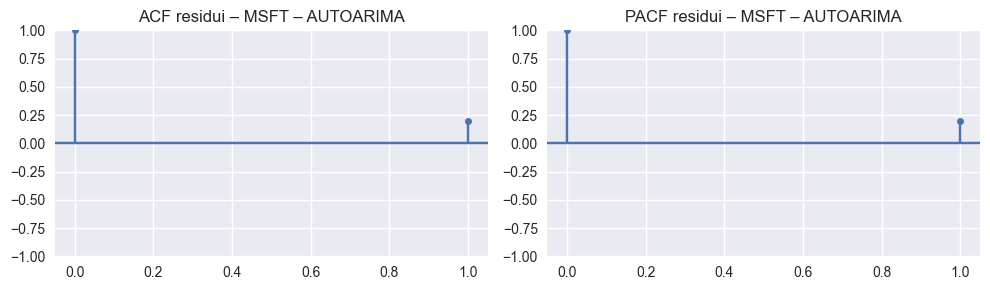

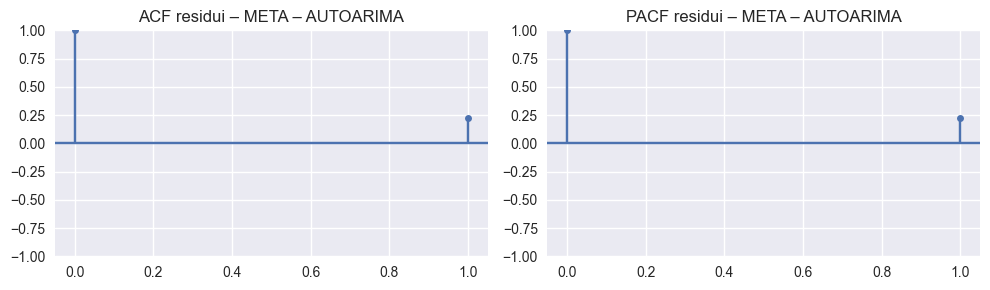

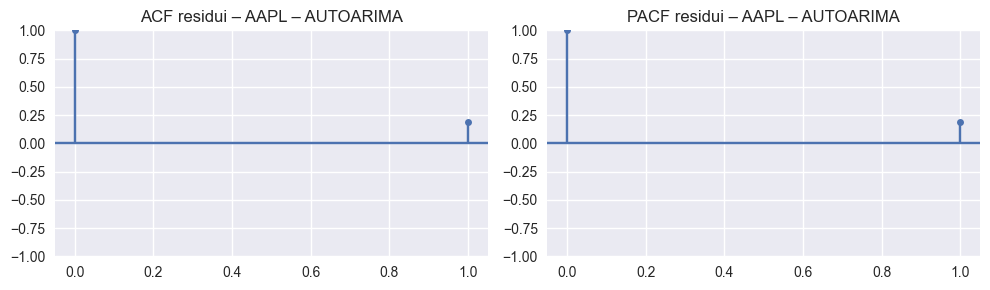

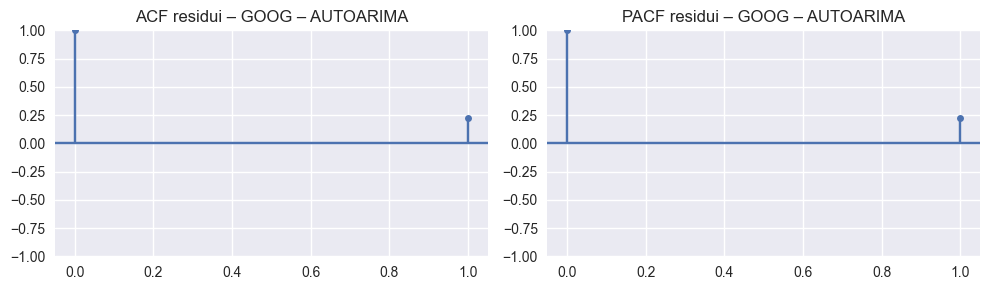

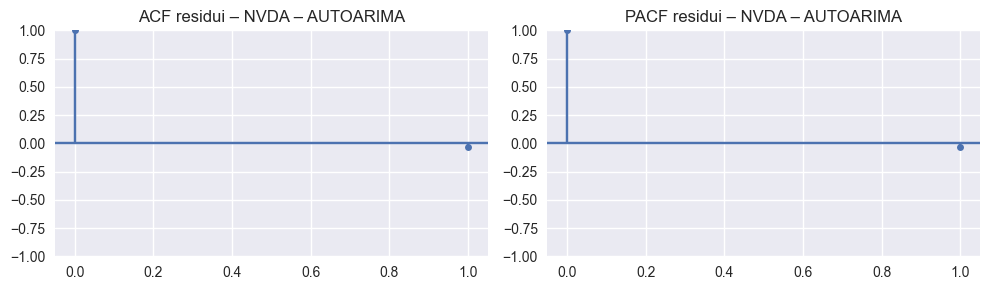

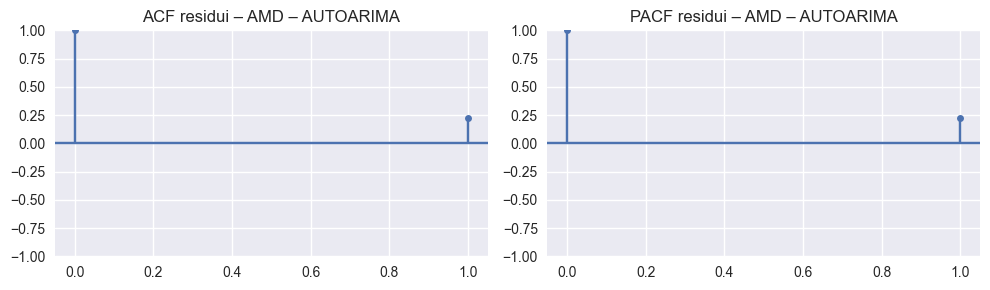

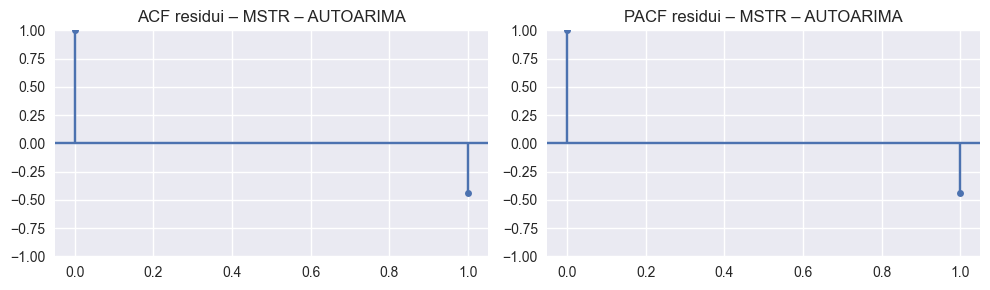

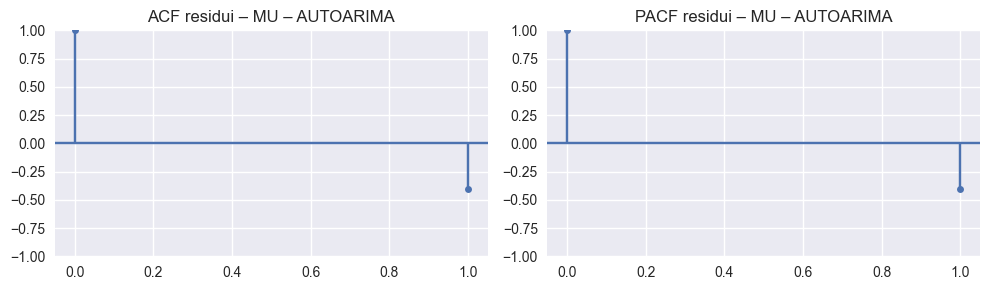

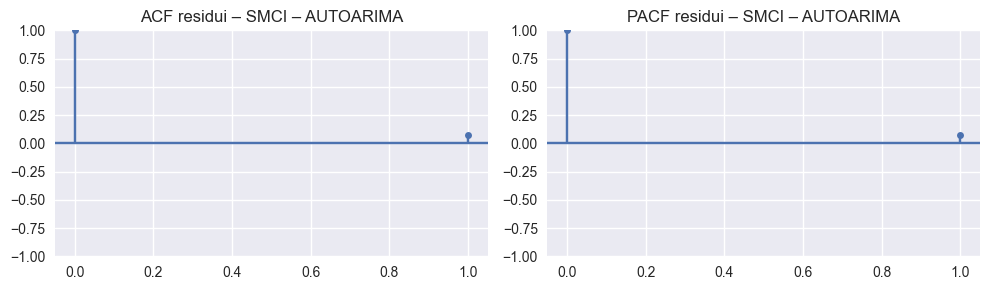

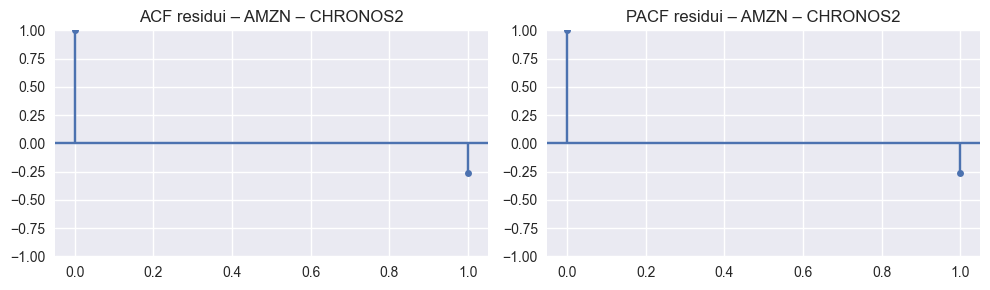

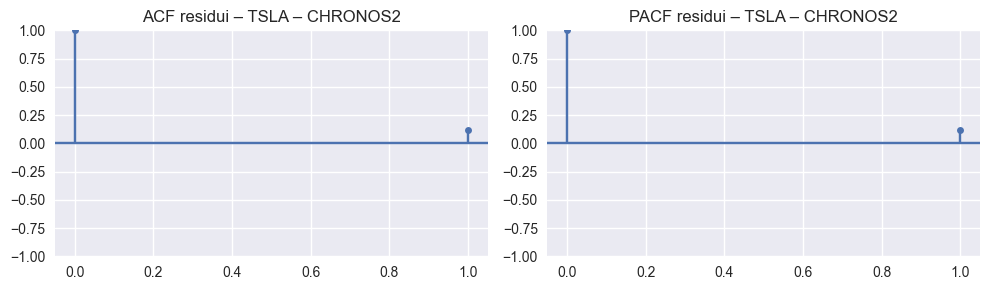

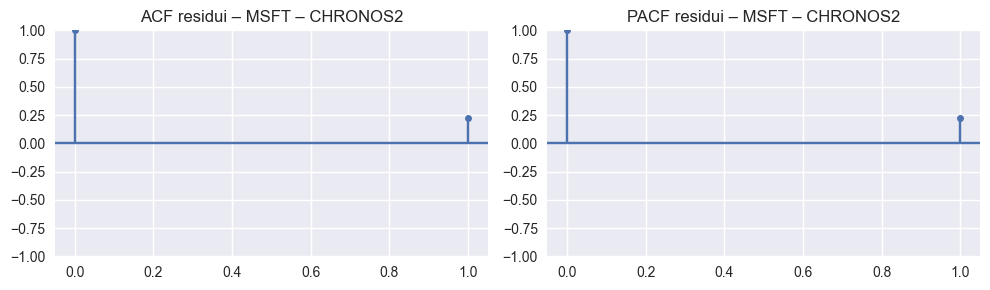

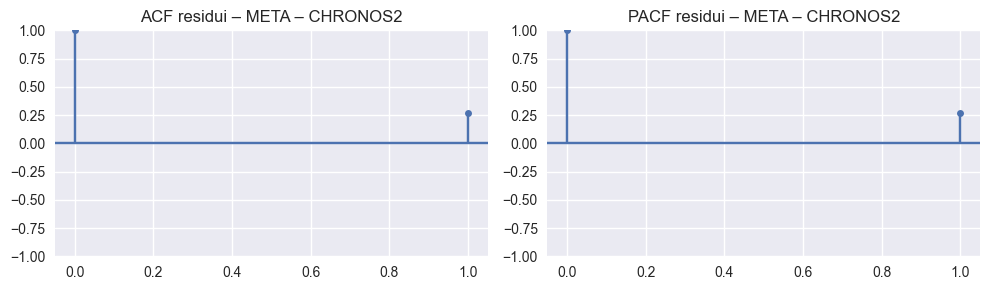

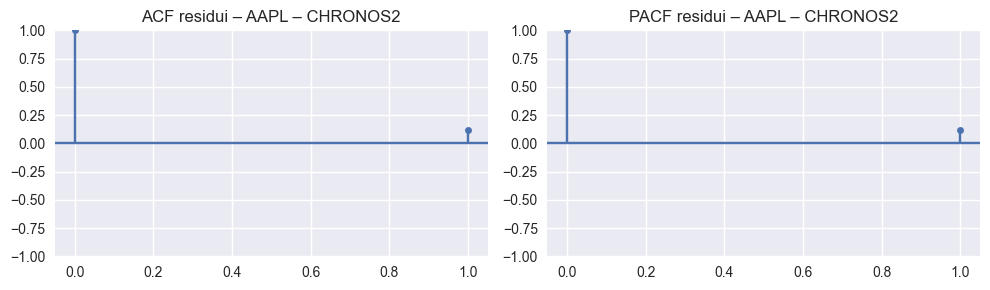

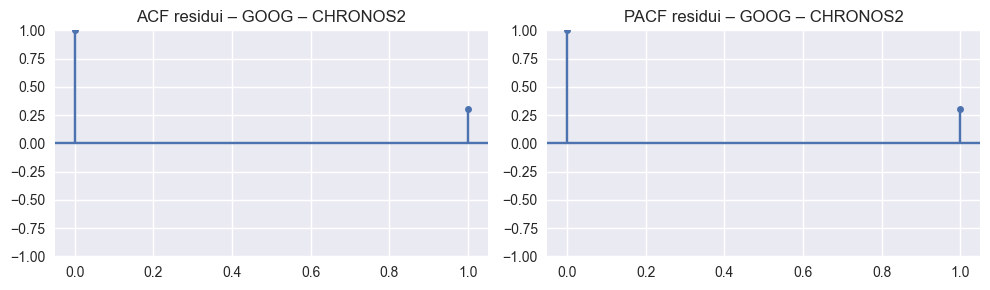

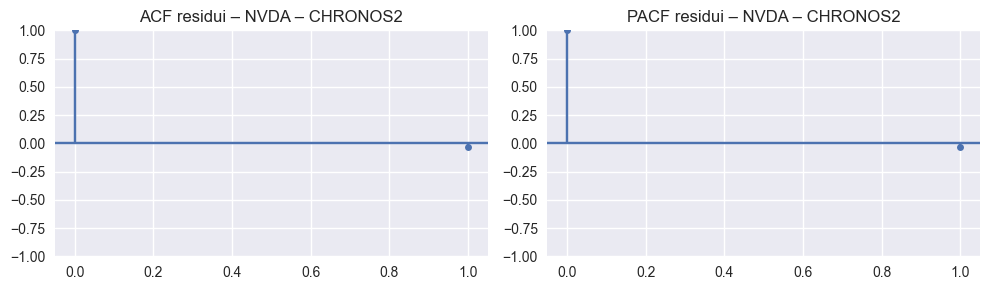

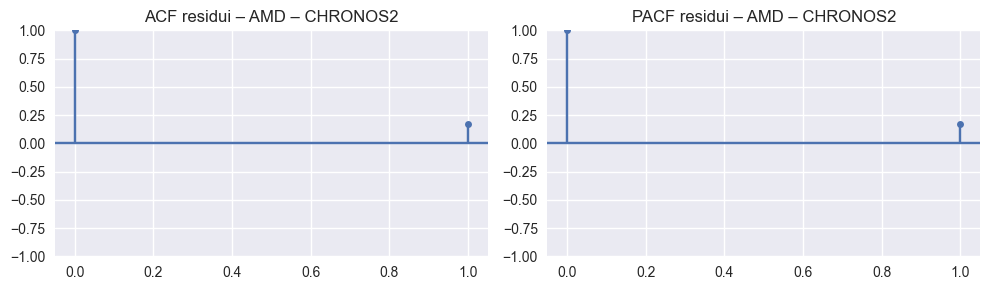

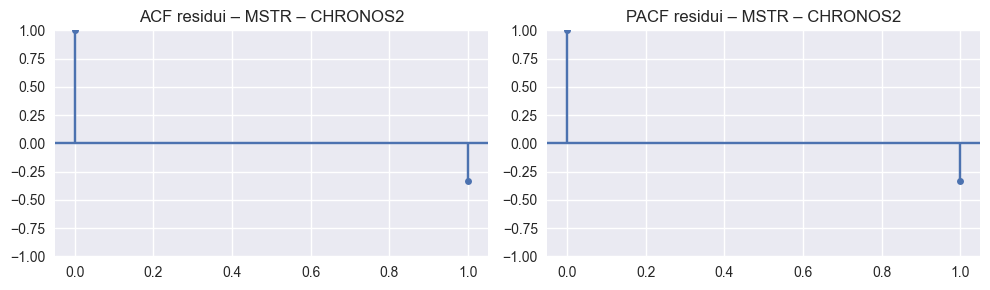

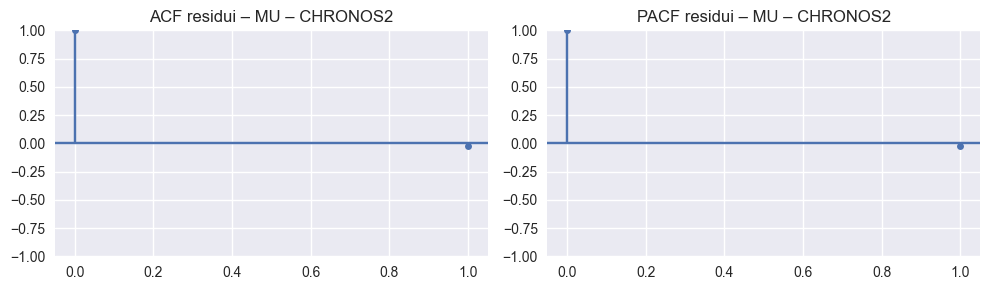

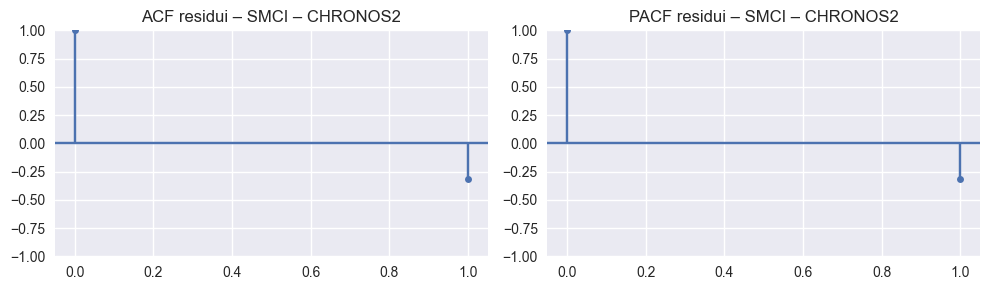

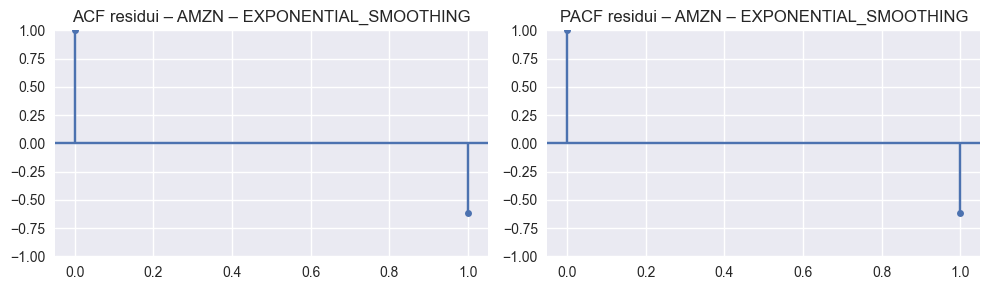

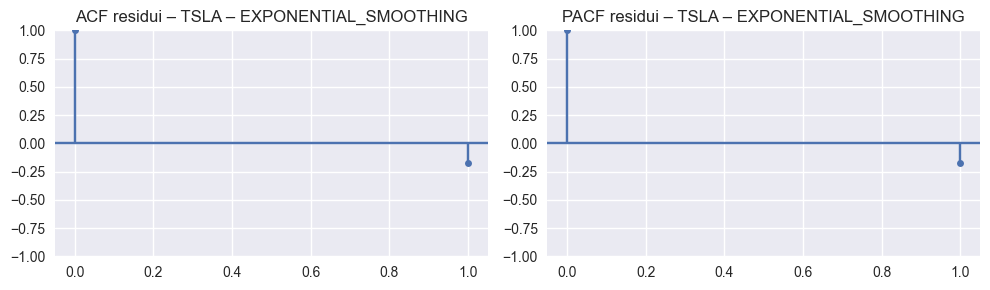

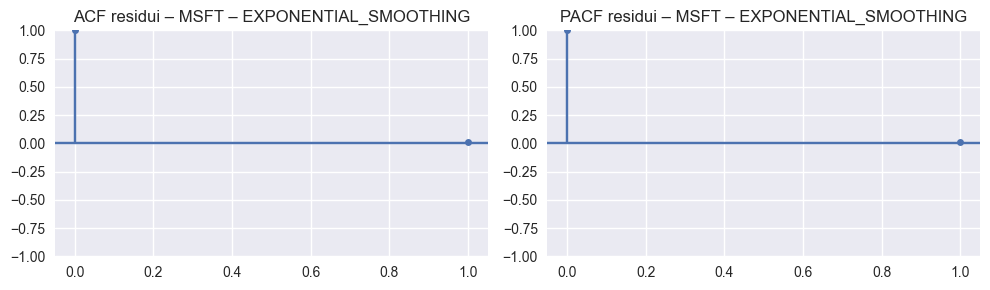

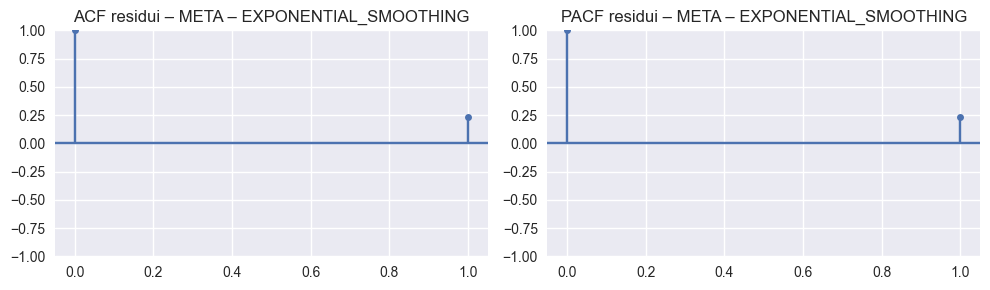

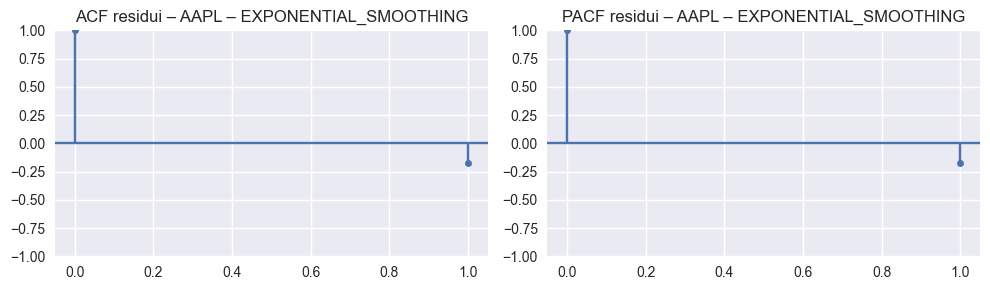

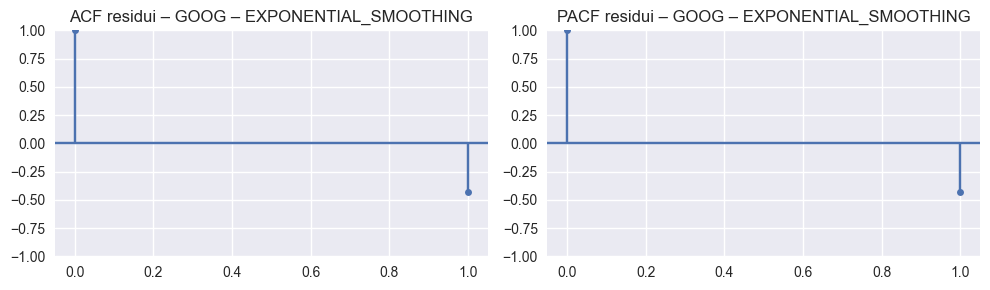

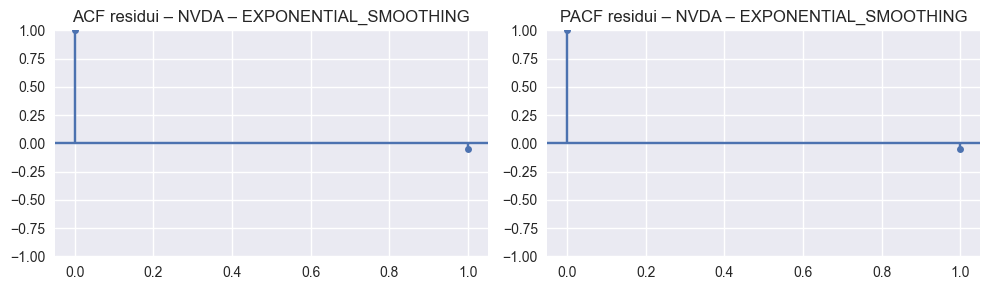

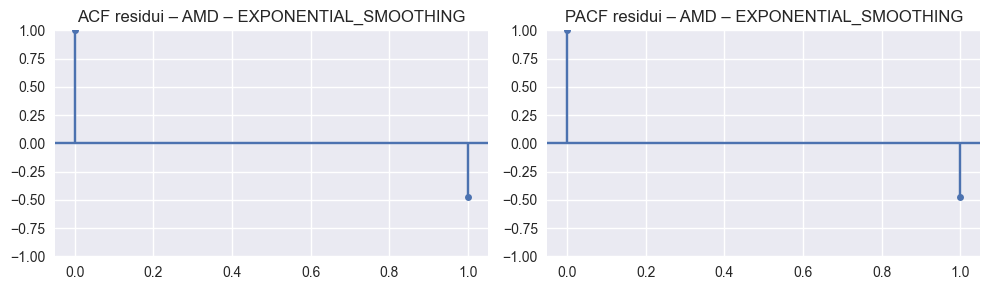

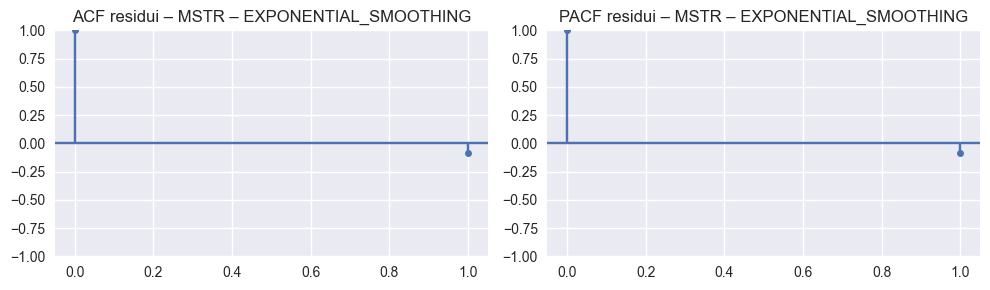

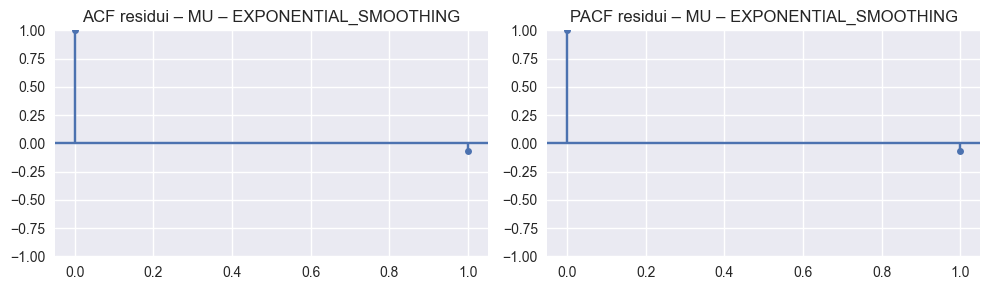

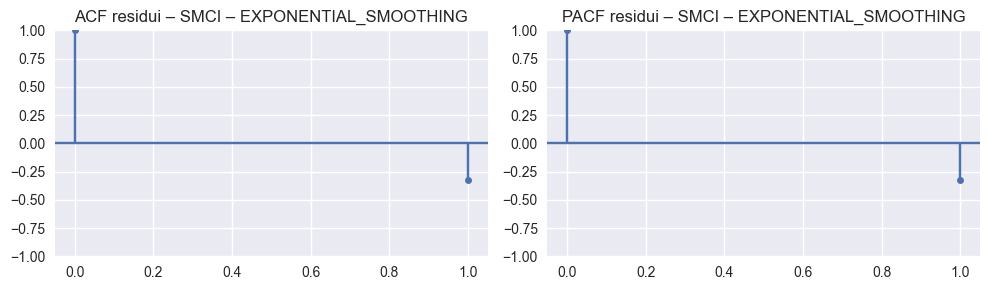

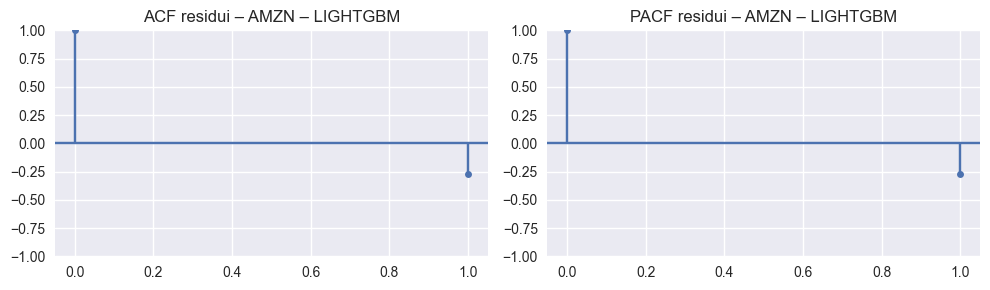

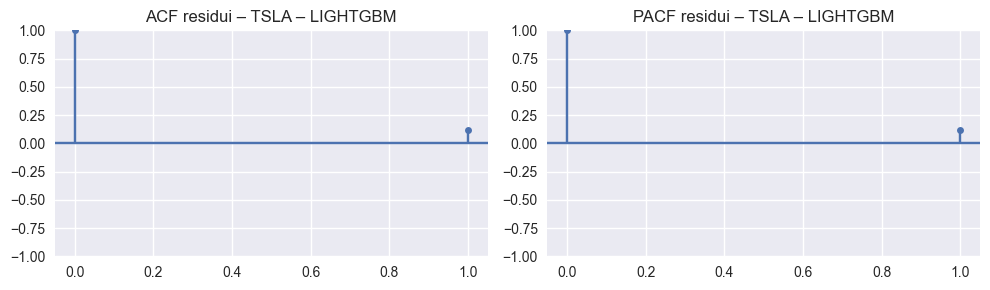

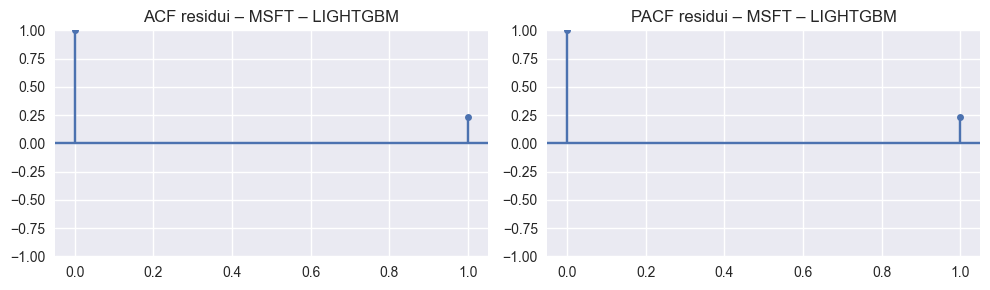

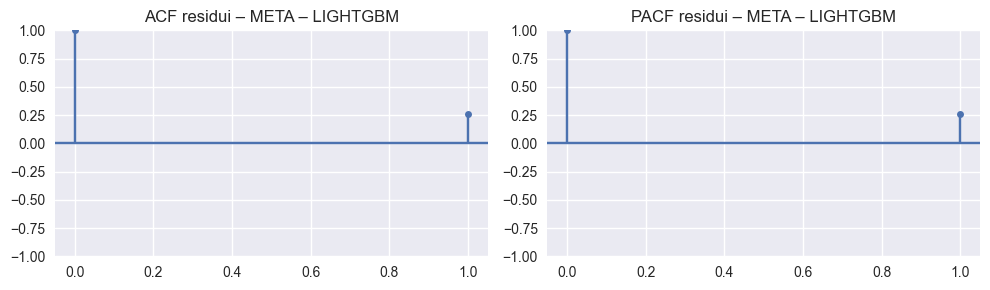

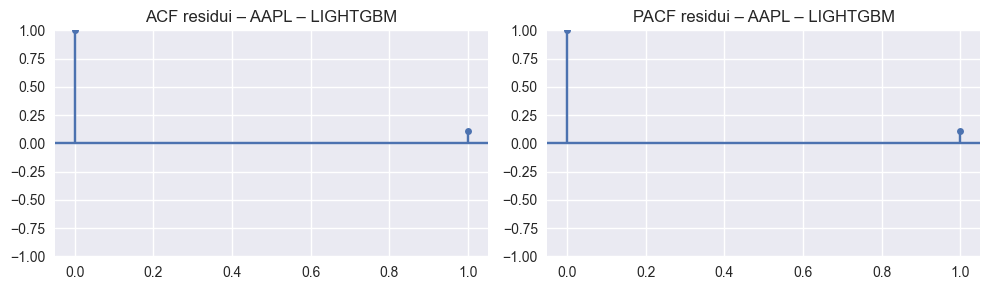

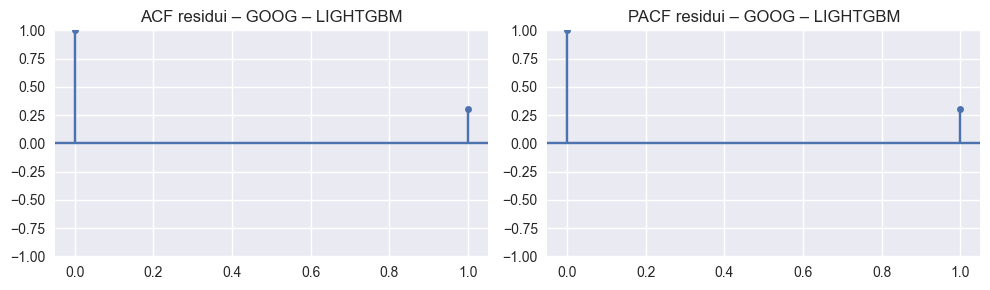

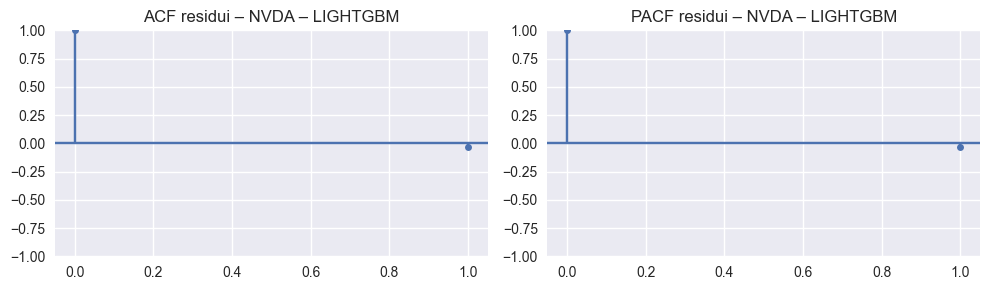

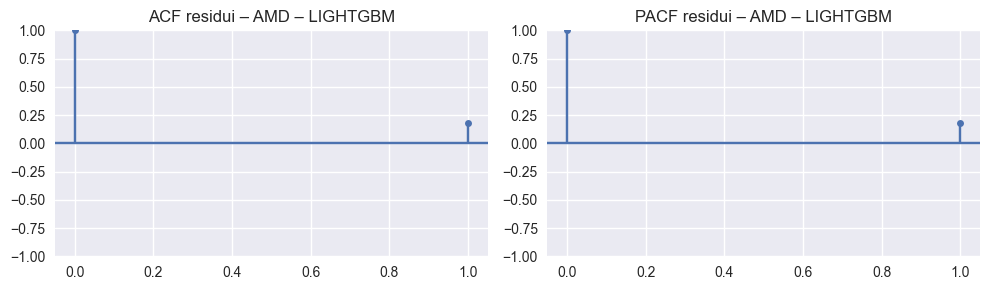

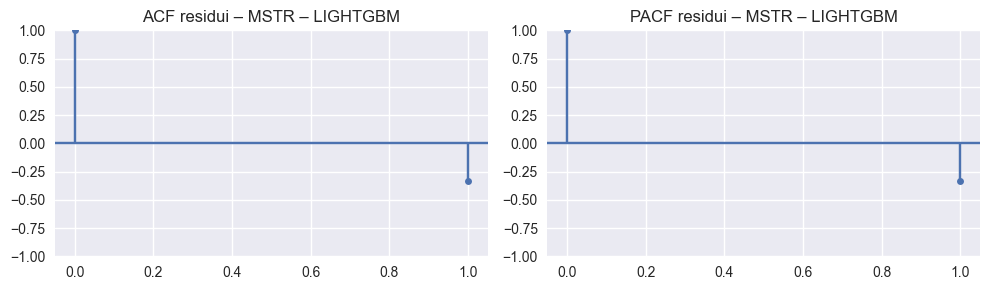

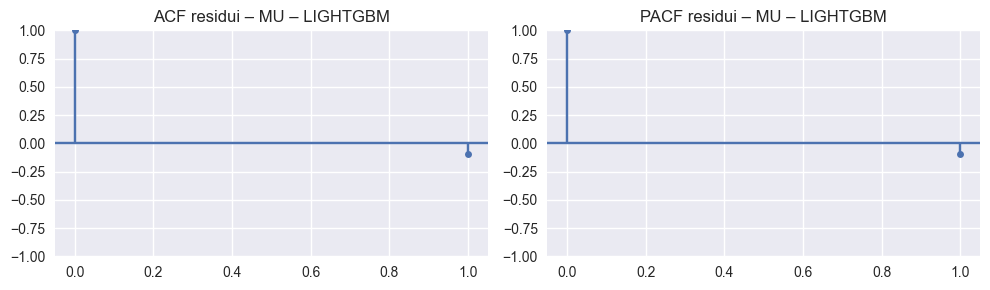

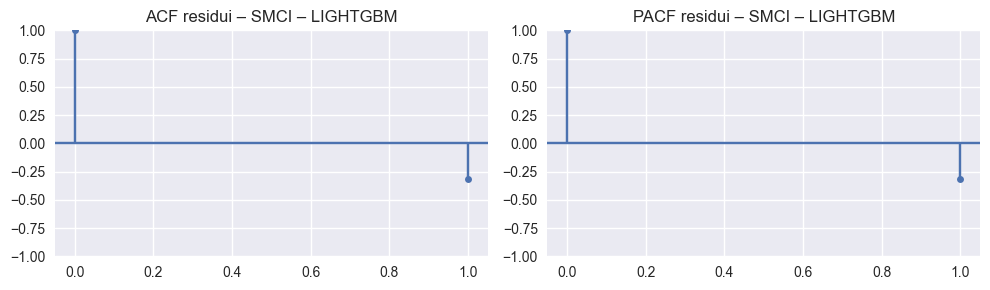

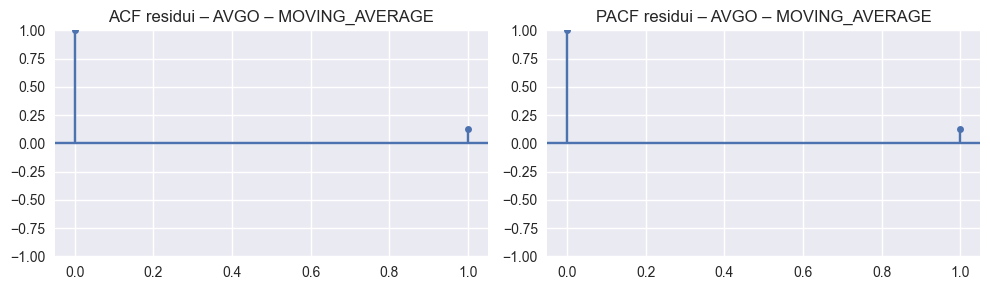

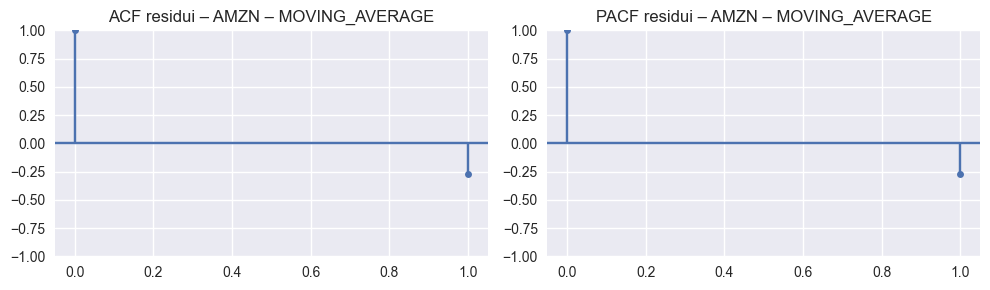

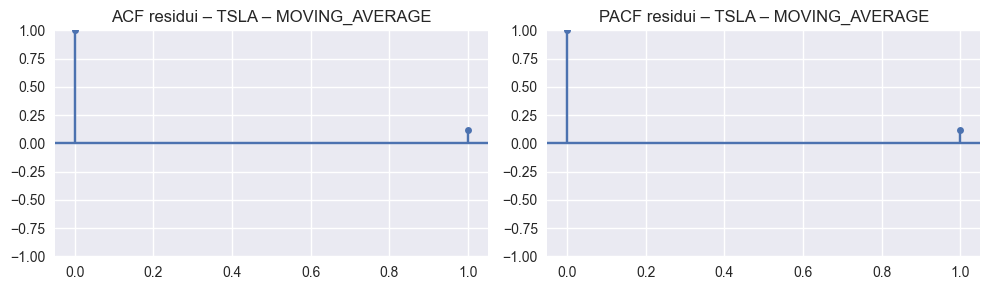

Skip PACF: vincolo nlags per MSFT – MOVING_AVERAGE (n=3)


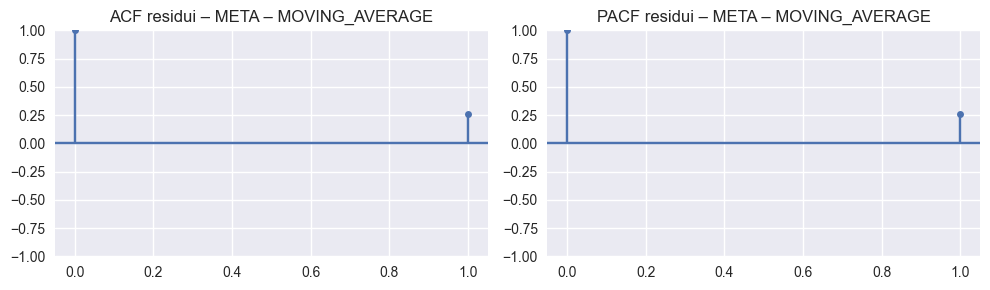

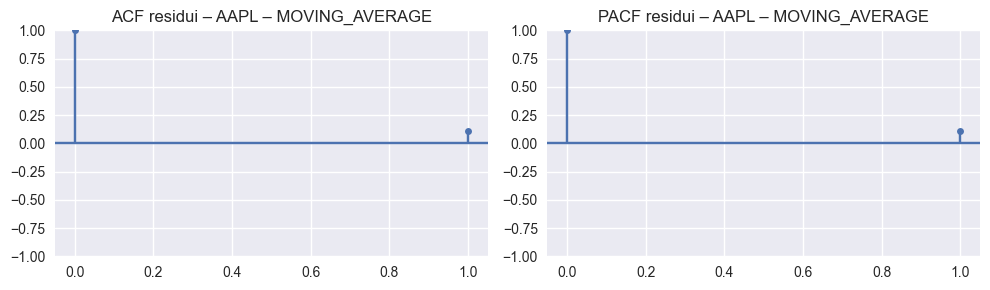

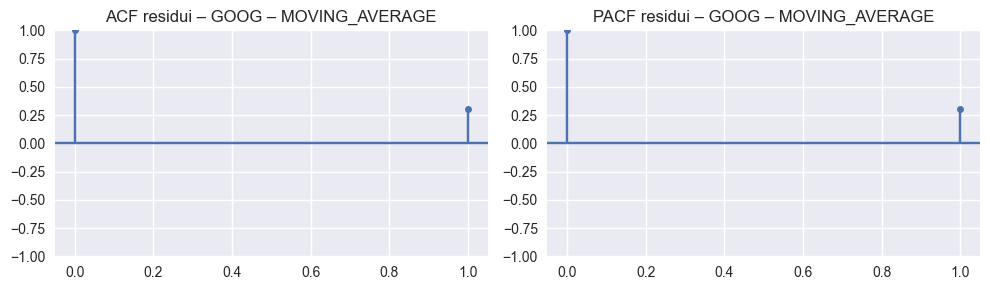

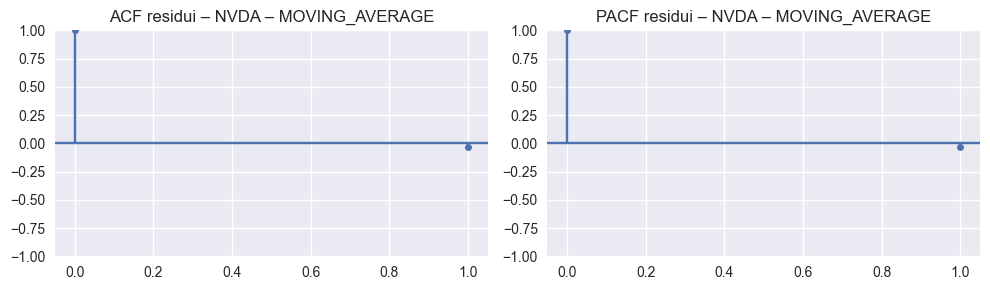

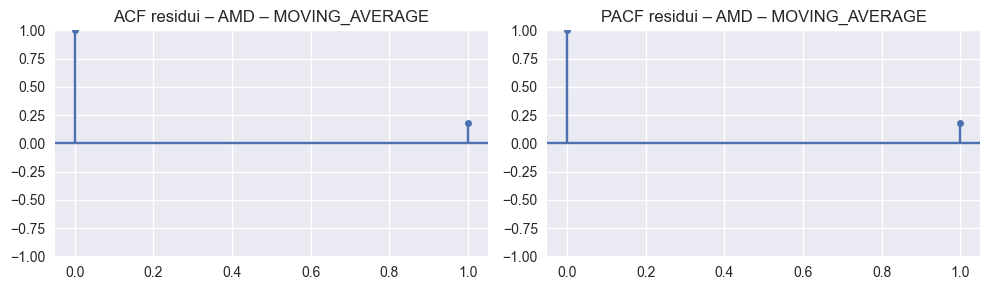

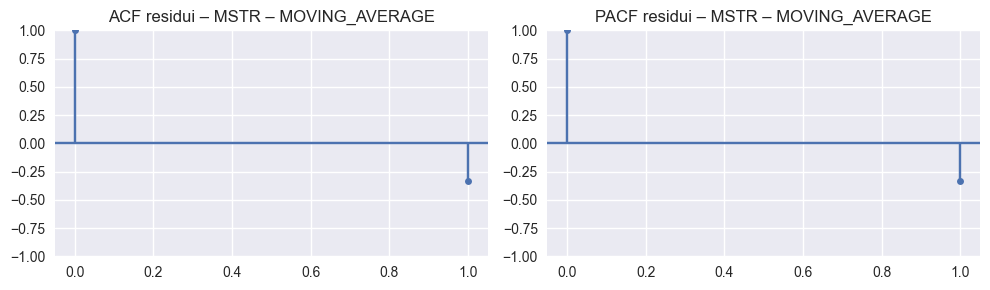

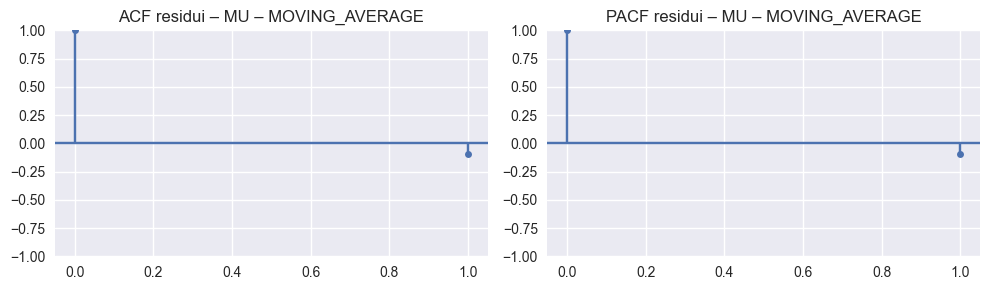

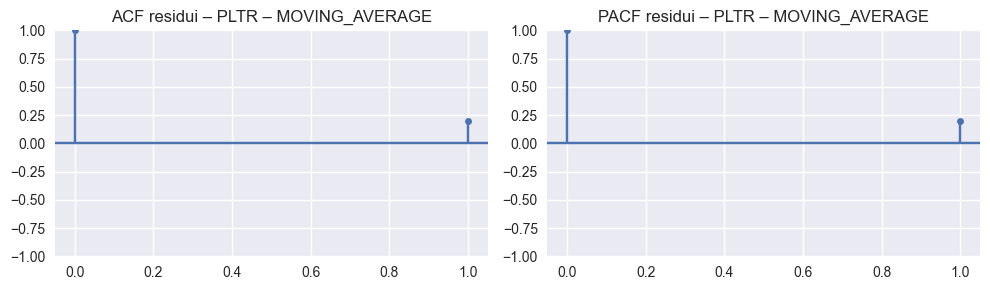

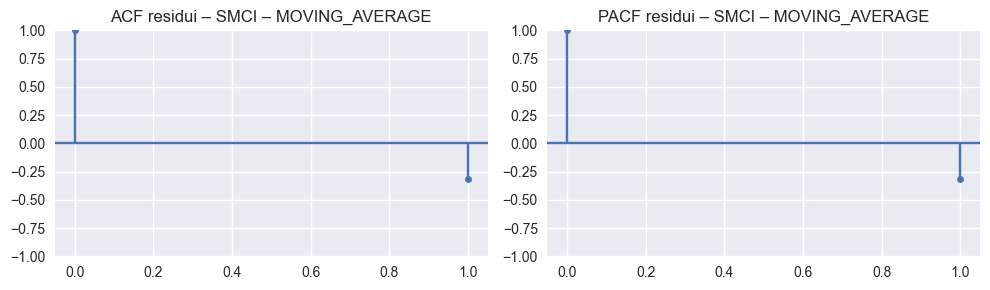

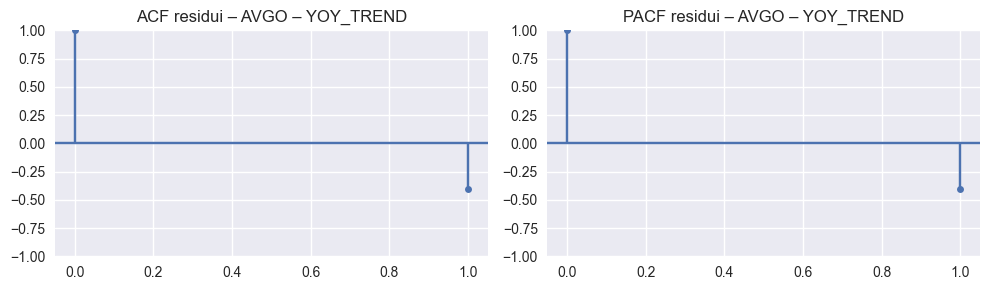

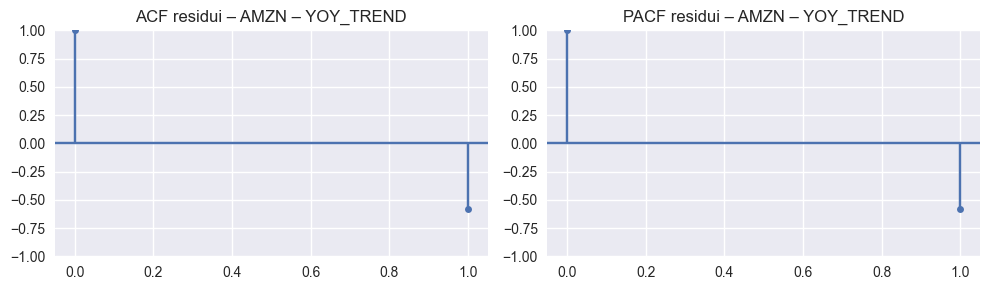

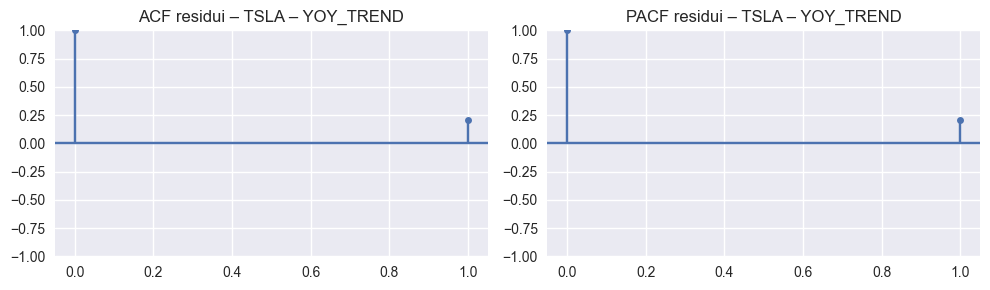

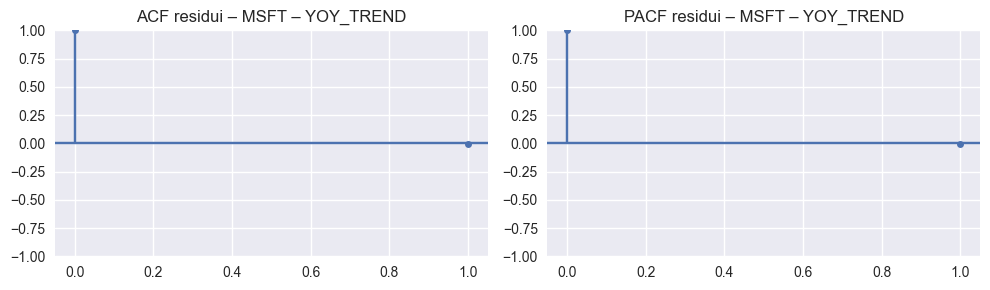

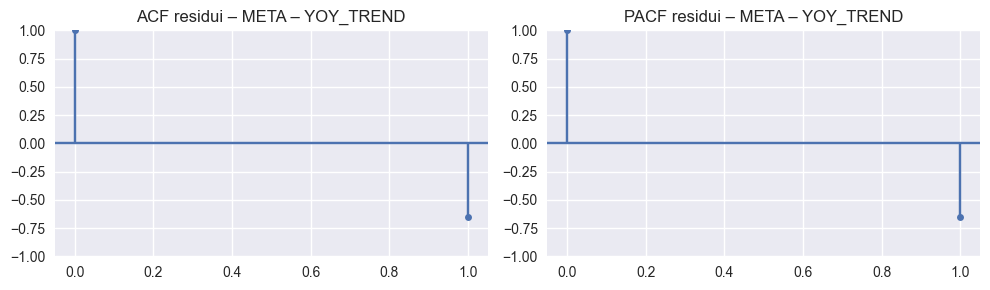

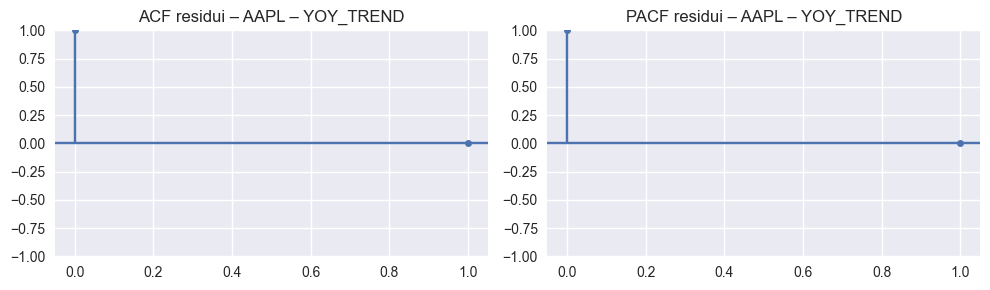

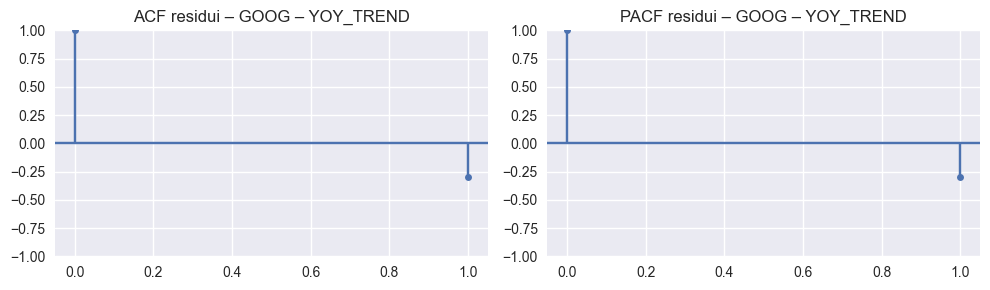

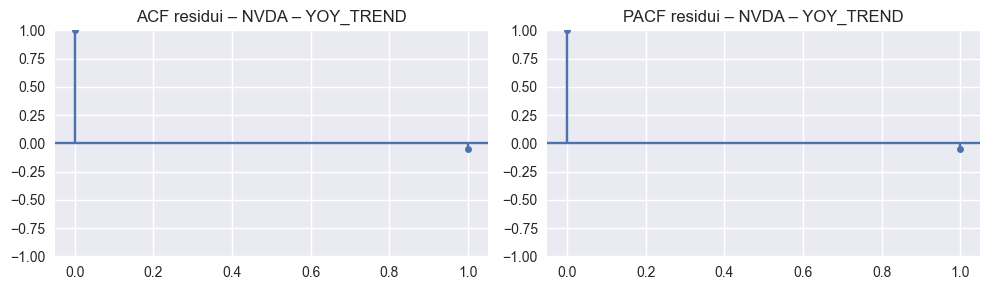

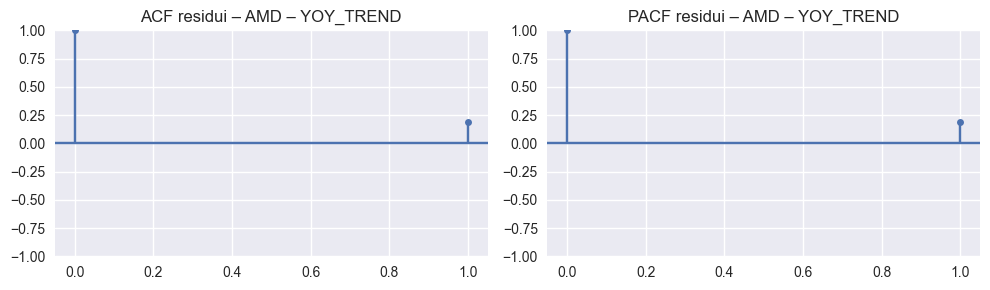

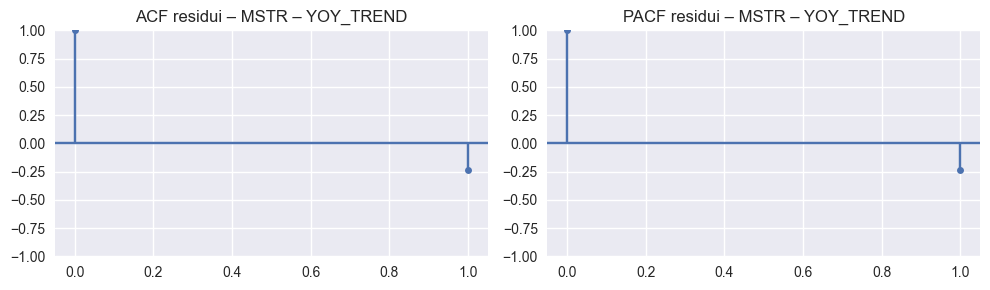

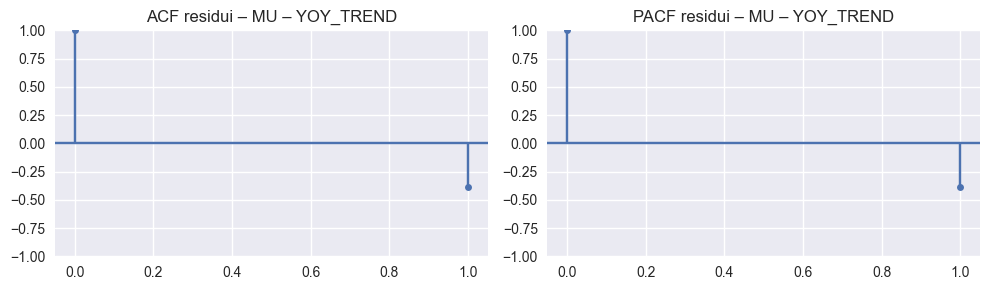

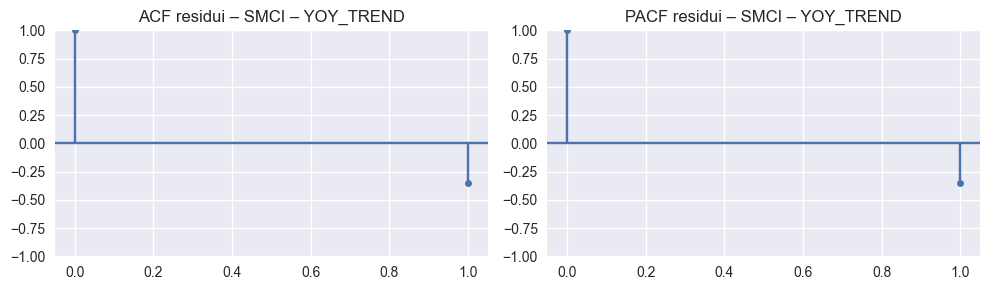

In [50]:
print("\nACF/PACF DEI RESIDUI")
print("=" * 80)

for model in MODELS:
    for ticker in TICKERS:
        resid = load_residuals(model, ticker)
        if resid is None or resid.empty:
            continue

        n = len(resid)
        # serve almeno 3 punti per fare qualcosa di sensato
        if n < 3:
            print(f"Skip ACF/PACF: troppo pochi punti (n={n}) per {ticker} – {model.upper()}")
            continue

        # nlags massimo ammesso: < n/2
        max_lags = min(10, n // 2 - 1)
        if max_lags < 1:
            print(f"Skip PACF: vincolo nlags per {ticker} – {model.upper()} (n={n})")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))

        plot_acf(resid.values, ax=axes[0], lags=max_lags)
        axes[0].set_title(f"ACF residui – {ticker} – {model.upper()}")

        plot_pacf(resid.values, ax=axes[1], lags=max_lags, method="ywm")
        axes[1].set_title(f"PACF residui – {ticker} – {model.upper()}")

        fig.tight_layout()
        plt.show()


LJUNG–BOX TEST SUI RESIDUI


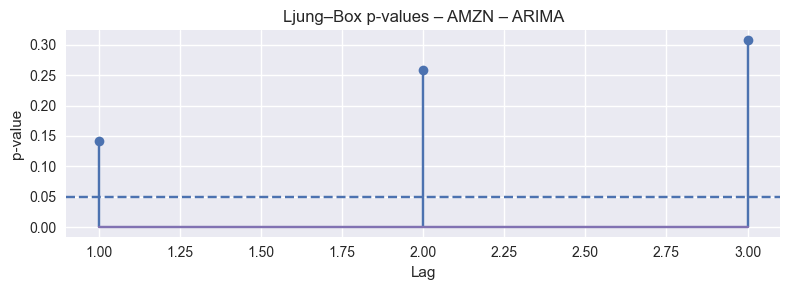


AMZN – ARIMA
    lb_stat  lb_pvalue
1  2.164467   0.141234
2  2.708128   0.258189
3  3.599305   0.308109
----------------------------------------


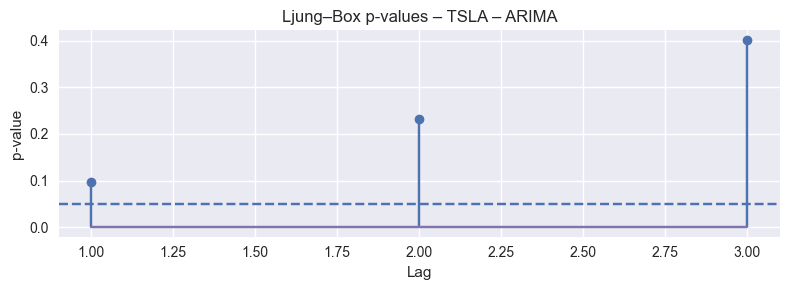


TSLA – ARIMA
    lb_stat  lb_pvalue
1  2.749896   0.097261
2  2.912515   0.233107
3  2.934288   0.401868
----------------------------------------


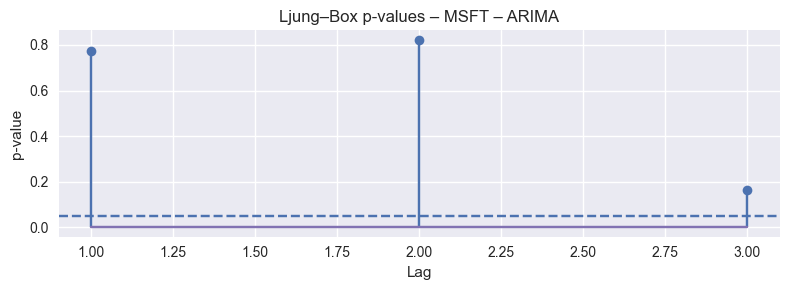


MSFT – ARIMA
    lb_stat  lb_pvalue
1  0.083836   0.772165
2  0.390037   0.822820
3  5.092143   0.165173
----------------------------------------


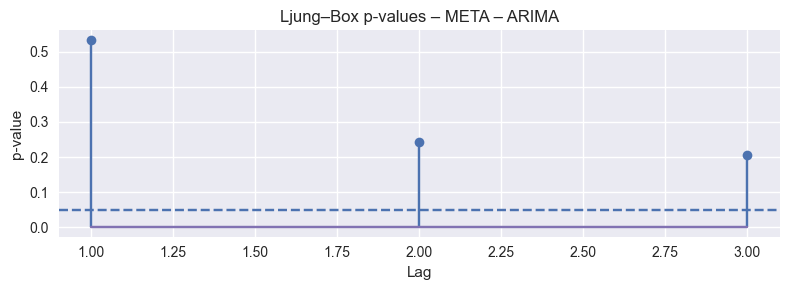


META – ARIMA
    lb_stat  lb_pvalue
1  0.387444   0.533646
2  2.841543   0.241528
3  4.563307   0.206712
----------------------------------------


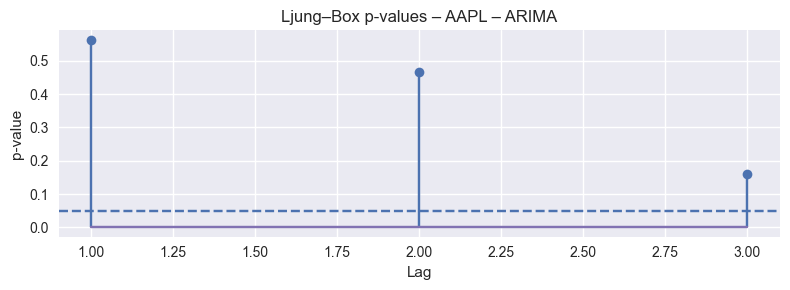


AAPL – ARIMA
    lb_stat  lb_pvalue
1  0.333348   0.563694
2  1.526998   0.466033
3  5.153824   0.160874
----------------------------------------


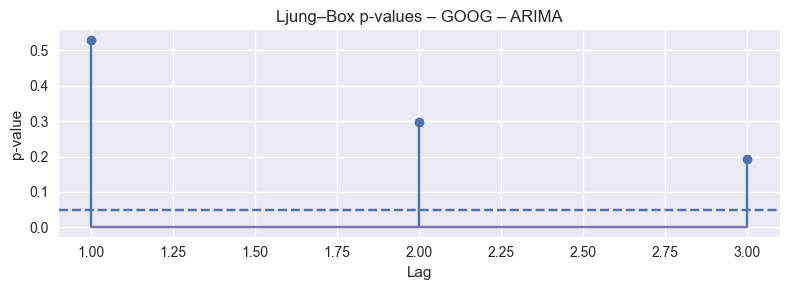


GOOG – ARIMA
    lb_stat  lb_pvalue
1  0.393684   0.530369
2  2.432173   0.296388
3  4.733761   0.192363
----------------------------------------


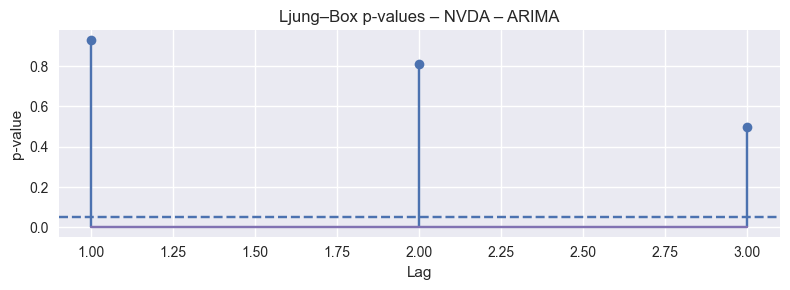


NVDA – ARIMA
    lb_stat  lb_pvalue
1  0.007372   0.931576
2  0.416517   0.811997
3  2.365833   0.500027
----------------------------------------


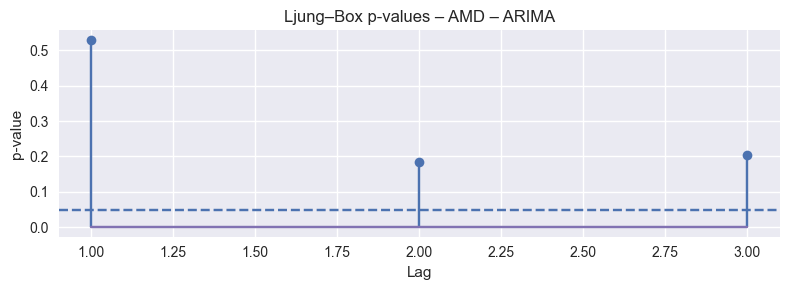


AMD – ARIMA
    lb_stat  lb_pvalue
1  0.394976   0.529695
2  3.389997   0.183599
3  4.579357   0.205320
----------------------------------------


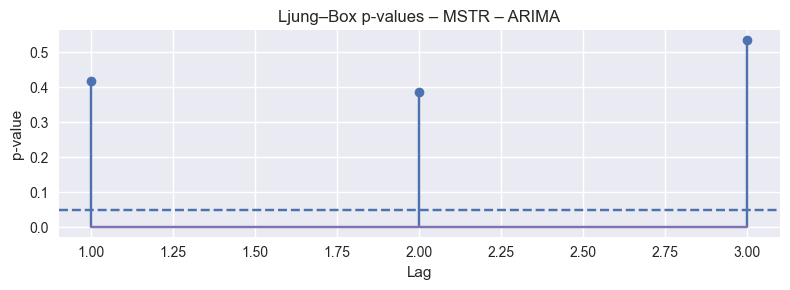


MSTR – ARIMA
    lb_stat  lb_pvalue
1  0.658156   0.417212
2  1.896484   0.387422
3  2.176756   0.536541
----------------------------------------


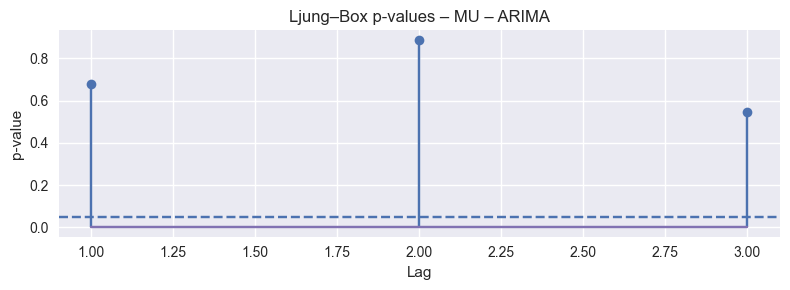


MU – ARIMA
    lb_stat  lb_pvalue
1  0.173155   0.677323
2  0.235361   0.888980
3  2.128821   0.546104
----------------------------------------


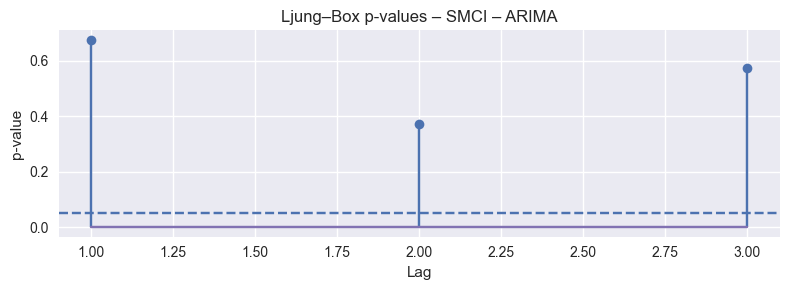


SMCI – ARIMA
    lb_stat  lb_pvalue
1  0.174427   0.676207
2  1.966668   0.374062
3  1.994612   0.573526
----------------------------------------


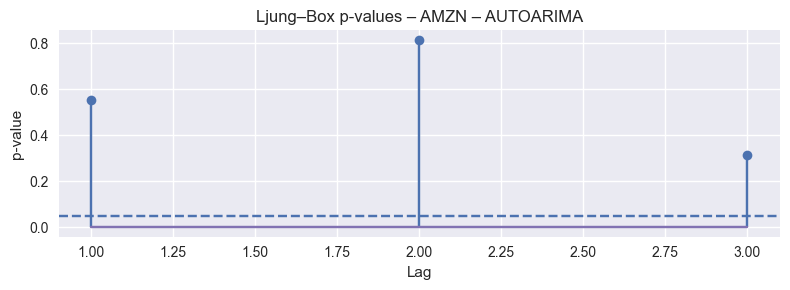


AMZN – AUTOARIMA
    lb_stat  lb_pvalue
1  0.347589   0.555481
2  0.405589   0.816446
3  3.534653   0.316295
----------------------------------------


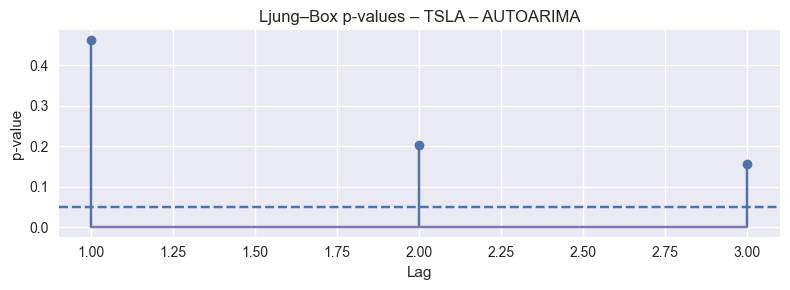


TSLA – AUTOARIMA
    lb_stat  lb_pvalue
1  0.539260   0.462740
2  3.186160   0.203298
3  5.204216   0.157440
----------------------------------------


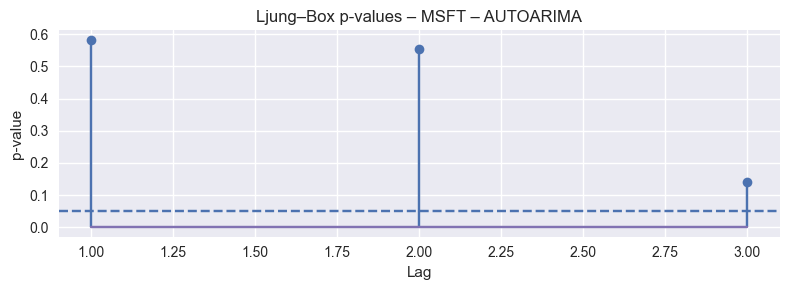


MSFT – AUTOARIMA
    lb_stat  lb_pvalue
1  0.302050   0.582600
2  1.185032   0.552934
3  5.480342   0.139819
----------------------------------------


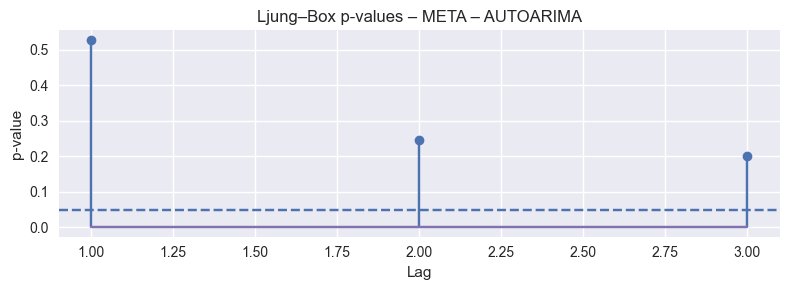


META – AUTOARIMA
    lb_stat  lb_pvalue
1  0.396633   0.528833
2  2.802680   0.246267
3  4.616190   0.202158
----------------------------------------


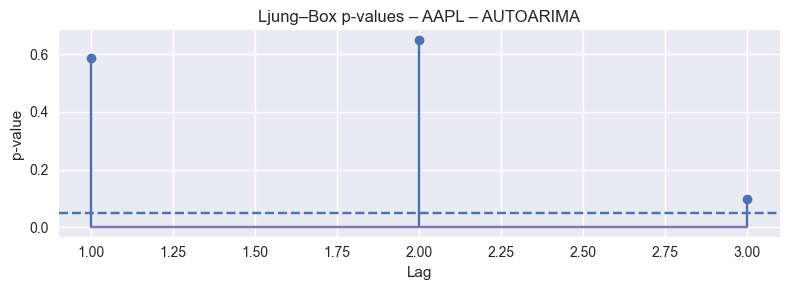


AAPL – AUTOARIMA
    lb_stat  lb_pvalue
1  0.293833   0.587775
2  0.860522   0.650339
3  6.260421   0.099605
----------------------------------------


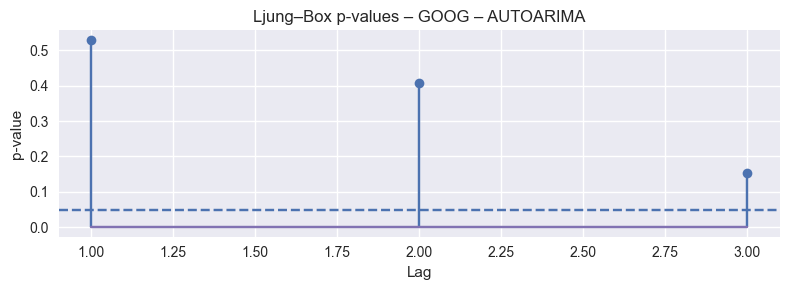


GOOG – AUTOARIMA
    lb_stat  lb_pvalue
1  0.395578   0.529382
2  1.800829   0.406401
3  5.269392   0.153101
----------------------------------------


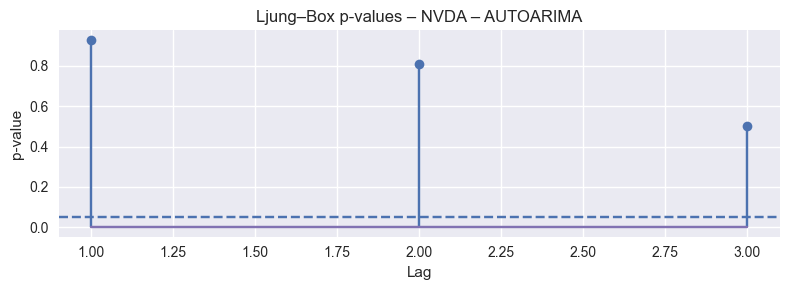


NVDA – AUTOARIMA
    lb_stat  lb_pvalue
1  0.007763   0.929793
2  0.417729   0.811505
3  2.353681   0.502315
----------------------------------------


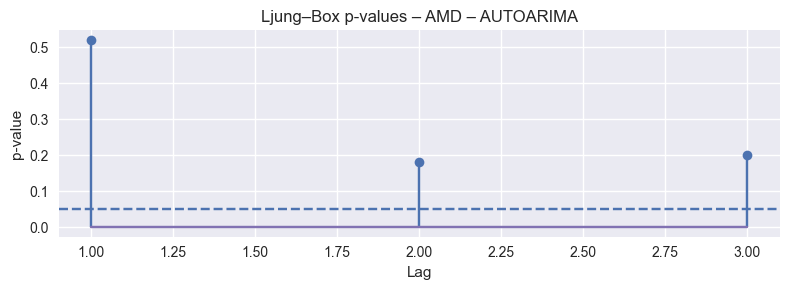


AMD – AUTOARIMA
    lb_stat  lb_pvalue
1  0.411399   0.521260
2  3.410742   0.181705
3  4.645535   0.199670
----------------------------------------


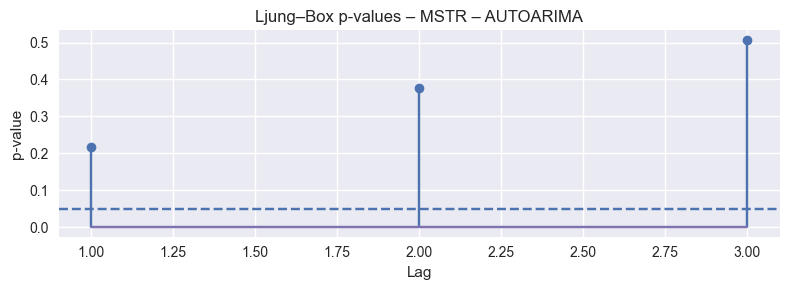


MSTR – AUTOARIMA
    lb_stat  lb_pvalue
1  1.522015   0.217315
2  1.950284   0.377139
3  2.325849   0.507587
----------------------------------------


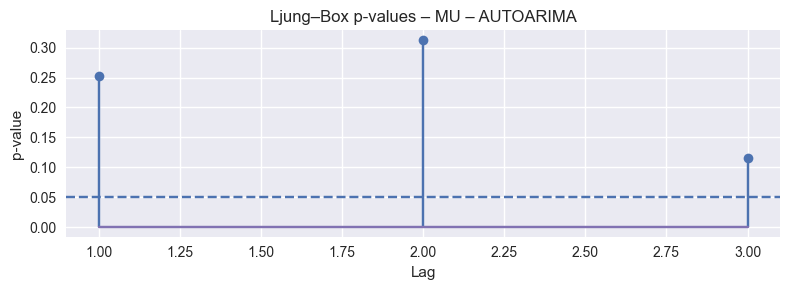


MU – AUTOARIMA
    lb_stat  lb_pvalue
1  1.304958   0.253310
2  2.322502   0.313094
3  5.922822   0.115426
----------------------------------------


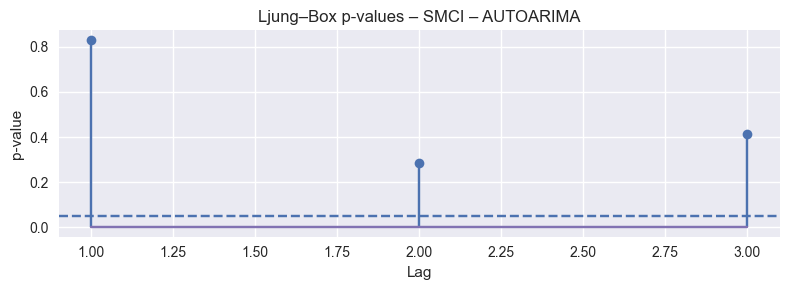


SMCI – AUTOARIMA
    lb_stat  lb_pvalue
1  0.045535   0.831024
2  2.524419   0.283028
3  2.875457   0.411229
----------------------------------------


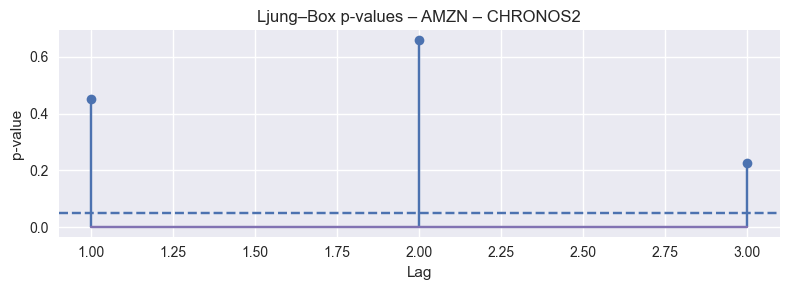


AMZN – CHRONOS2
    lb_stat  lb_pvalue
1  0.566229   0.451761
2  0.831194   0.659946
3  4.343504   0.226681
----------------------------------------


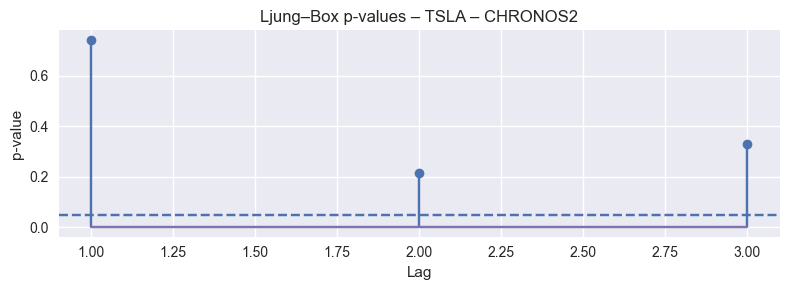


TSLA – CHRONOS2
    lb_stat  lb_pvalue
1  0.106923   0.743675
2  3.078529   0.214539
3  3.412595   0.332276
----------------------------------------


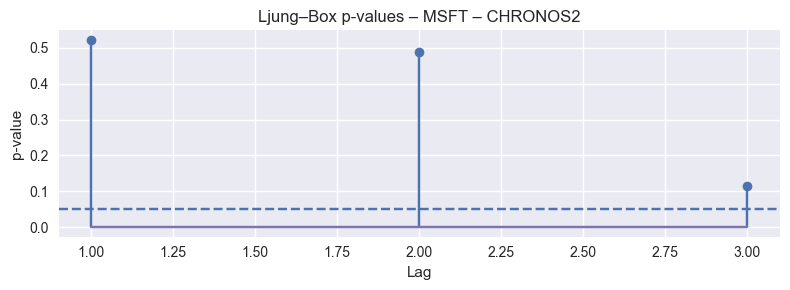


MSFT – CHRONOS2
    lb_stat  lb_pvalue
1  0.409522   0.522212
2  1.436462   0.487614
3  5.951067   0.114015
----------------------------------------


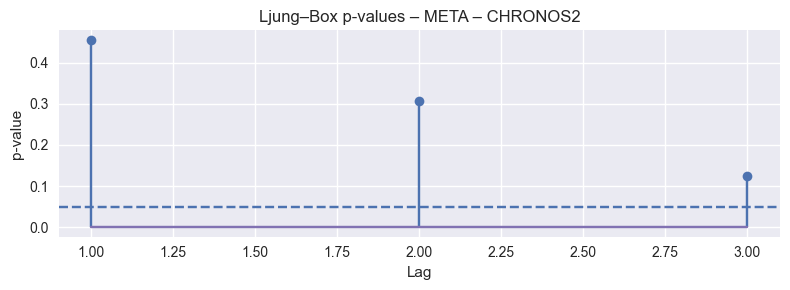


META – CHRONOS2
    lb_stat  lb_pvalue
1  0.556993   0.455474
2  2.360116   0.307261
3  5.757285   0.124035
----------------------------------------


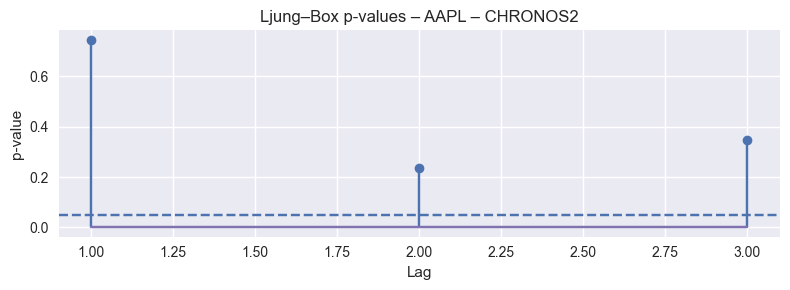


AAPL – CHRONOS2
    lb_stat  lb_pvalue
1  0.105402   0.745441
2  2.894478   0.235219
3  3.316979   0.345286
----------------------------------------


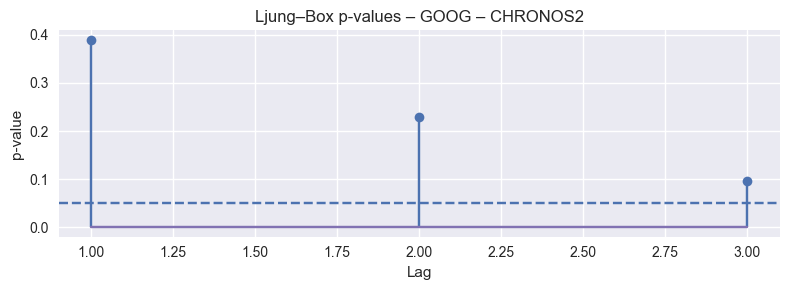


GOOG – CHRONOS2
    lb_stat  lb_pvalue
1  0.739412   0.389849
2  2.952311   0.228514
3  6.319924   0.097041
----------------------------------------


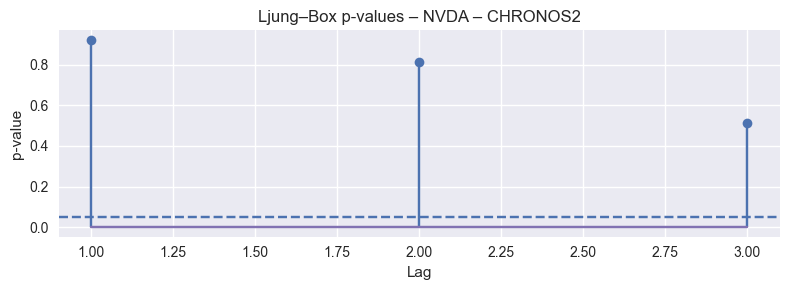


NVDA – CHRONOS2
    lb_stat  lb_pvalue
1  0.009635   0.921806
2  0.418384   0.811240
3  2.309881   0.510631
----------------------------------------


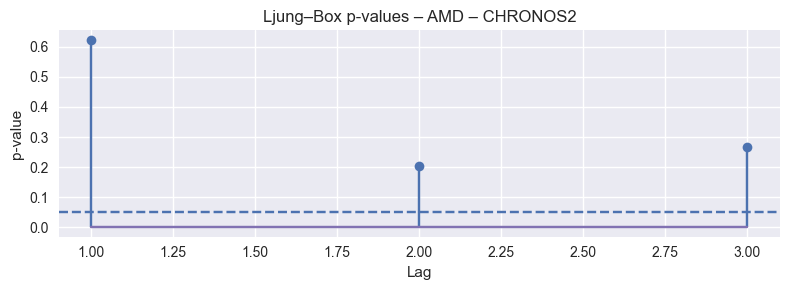


AMD – CHRONOS2
    lb_stat  lb_pvalue
1  0.240773   0.623648
2  3.183584   0.203560
3  3.946330   0.267318
----------------------------------------


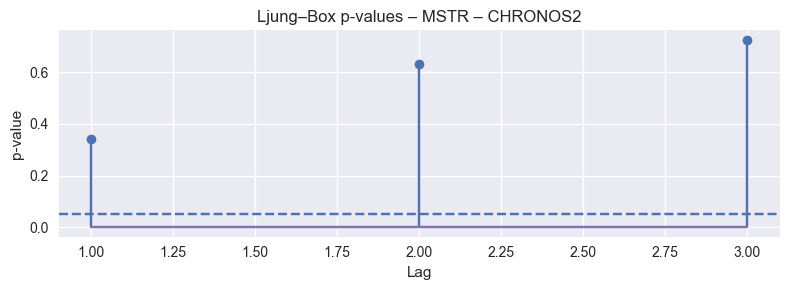


MSTR – CHRONOS2
    lb_stat  lb_pvalue
1  0.901041   0.342503
2  0.916356   0.632435
3  1.313708   0.725881
----------------------------------------


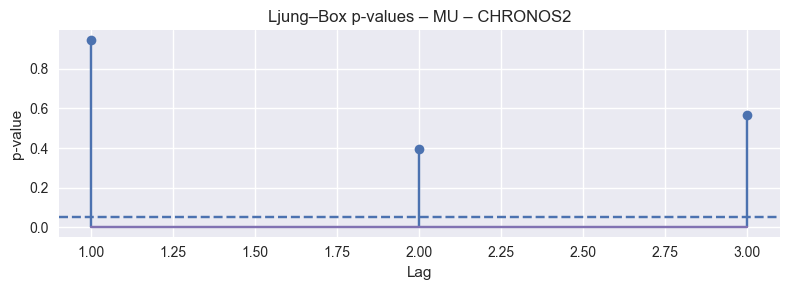


MU – CHRONOS2
    lb_stat  lb_pvalue
1  0.004434   0.946908
2  1.861213   0.394315
3  2.026937   0.566835
----------------------------------------


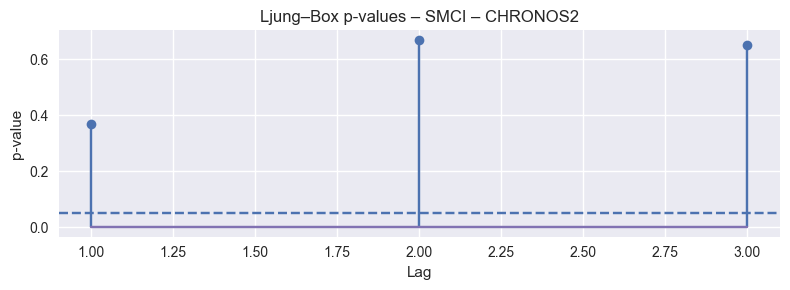


SMCI – CHRONOS2
    lb_stat  lb_pvalue
1  0.803473   0.370057
2  0.803647   0.669099
3  1.642020   0.649900
----------------------------------------


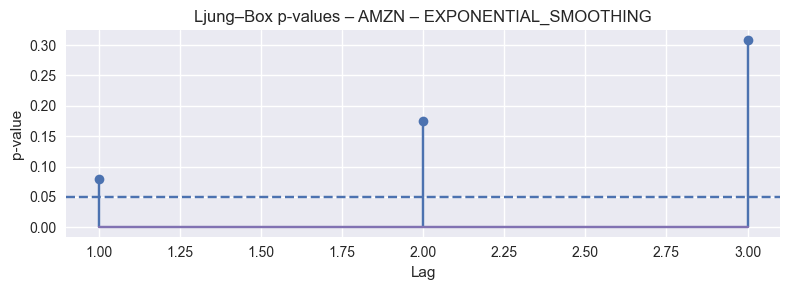


AMZN – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  3.058163   0.080332
2  3.478929   0.175614
3  3.593105   0.308886
----------------------------------------


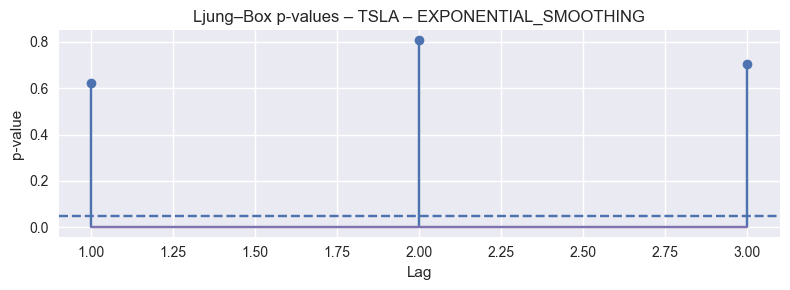


TSLA – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  0.240984   0.623496
2  0.424011   0.808960
3  1.412444   0.702620
----------------------------------------


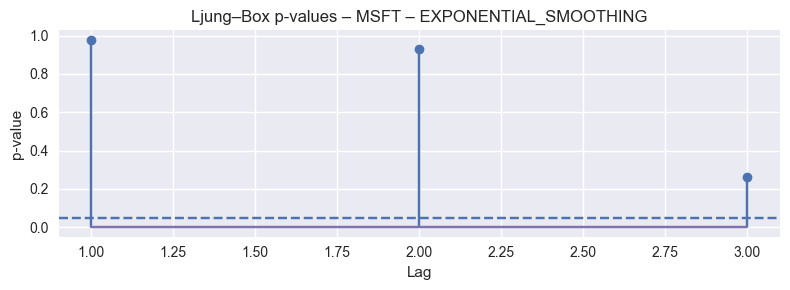


MSFT – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  0.000742   0.978271
2  0.143470   0.930777
3  3.994421   0.262067
----------------------------------------


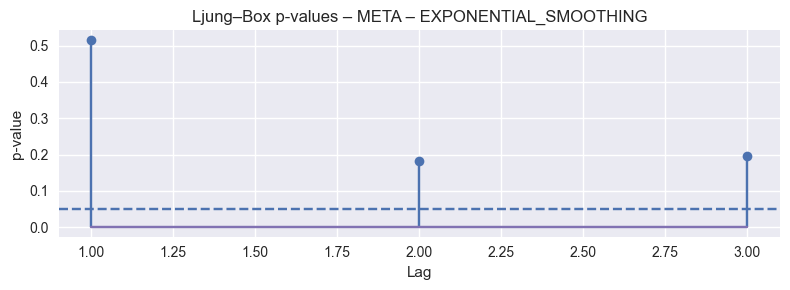


META – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  0.421587   0.516146
2  3.416894   0.181147
3  4.685970   0.196290
----------------------------------------


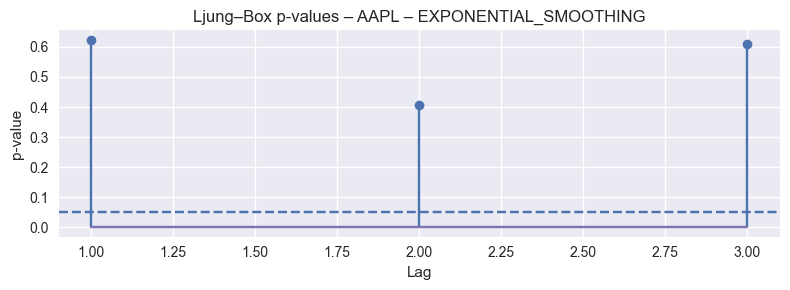


AAPL – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  0.240744   0.623669
2  1.804331   0.405690
3  1.832802   0.607823
----------------------------------------


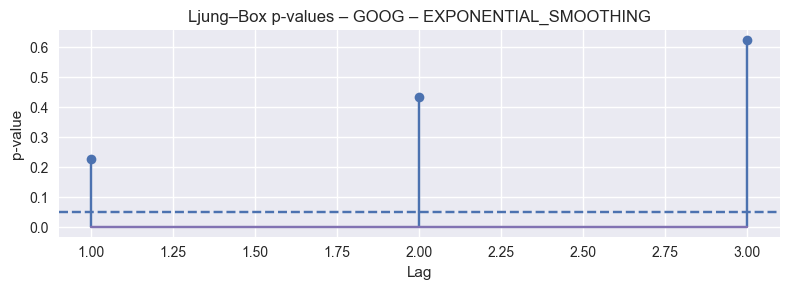


GOOG – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  1.459638   0.226988
2  1.671166   0.433622
3  1.757323   0.624266
----------------------------------------


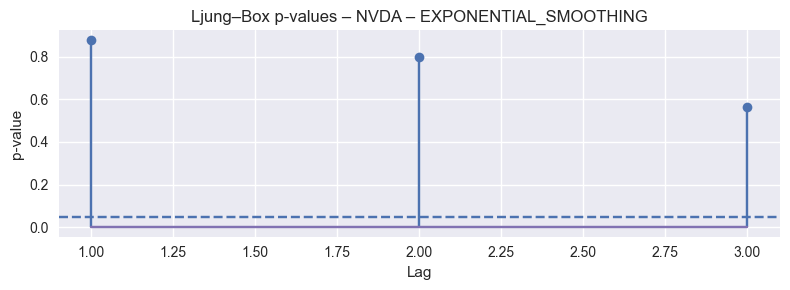


NVDA – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  0.023282   0.878726
2  0.447474   0.799526
3  2.045496   0.563018
----------------------------------------


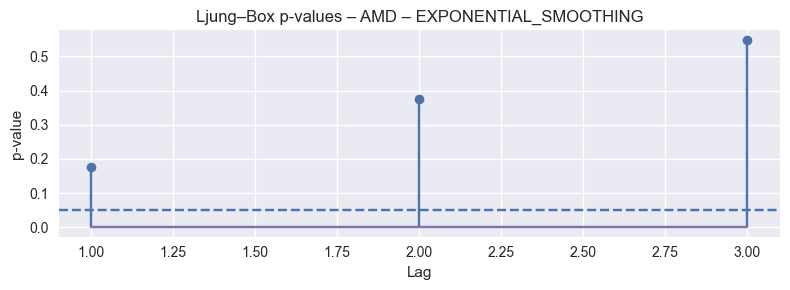


AMD – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  1.829932   0.176136
2  1.956933   0.375887
3  2.114961   0.548892
----------------------------------------


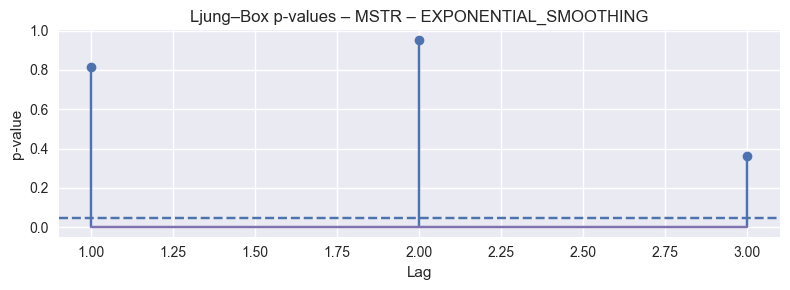


MSTR – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  0.054487   0.815431
2  0.095186   0.953522
3  3.192371   0.362906
----------------------------------------


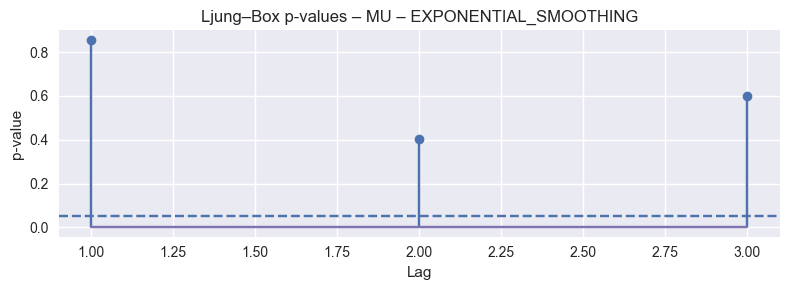


MU – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  0.032665   0.856576
2  1.810574   0.404426
3  1.873455   0.599082
----------------------------------------


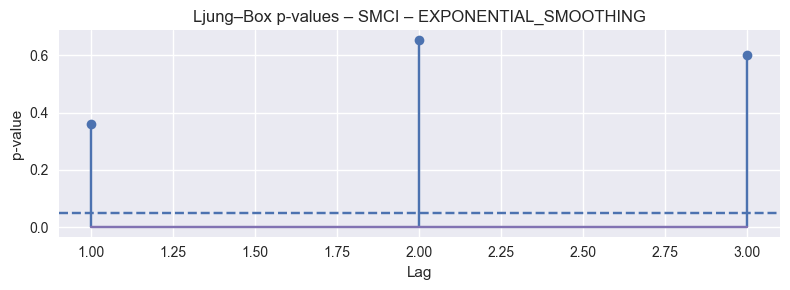


SMCI – EXPONENTIAL_SMOOTHING
    lb_stat  lb_pvalue
1  0.839264   0.359607
2  0.850243   0.653690
3  1.872195   0.599352
----------------------------------------


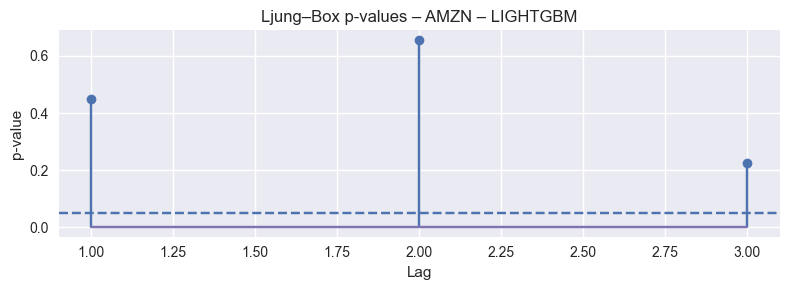


AMZN – LIGHTGBM
    lb_stat  lb_pvalue
1  0.573071   0.449041
2  0.841795   0.656457
3  4.343977   0.226637
----------------------------------------


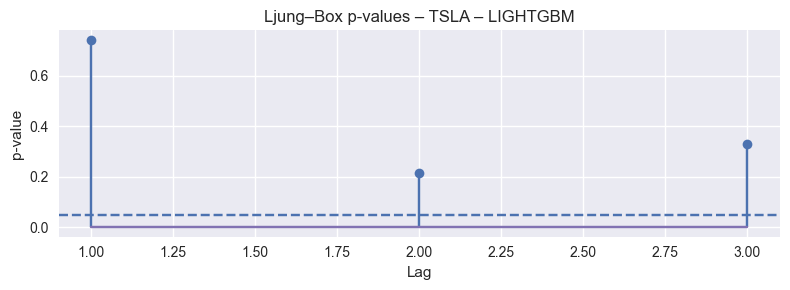


TSLA – LIGHTGBM
    lb_stat  lb_pvalue
1  0.106923   0.743675
2  3.078529   0.214539
3  3.412595   0.332276
----------------------------------------


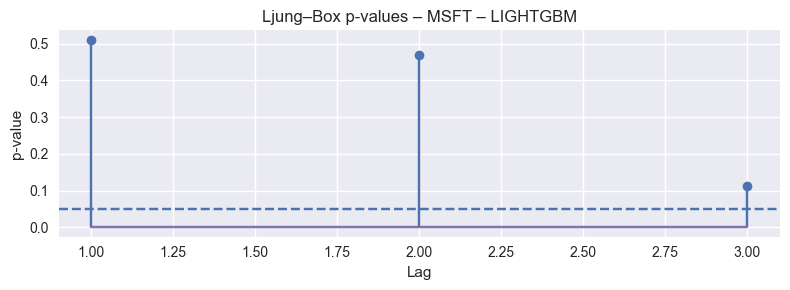


MSFT – LIGHTGBM
    lb_stat  lb_pvalue
1  0.432755   0.510640
2  1.518584   0.467998
3  5.992861   0.111958
----------------------------------------


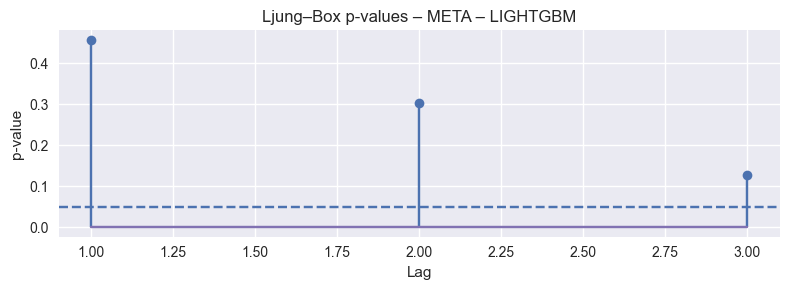


META – LIGHTGBM
    lb_stat  lb_pvalue
1  0.552680   0.457225
2  2.387976   0.303010
3  5.704961   0.126881
----------------------------------------


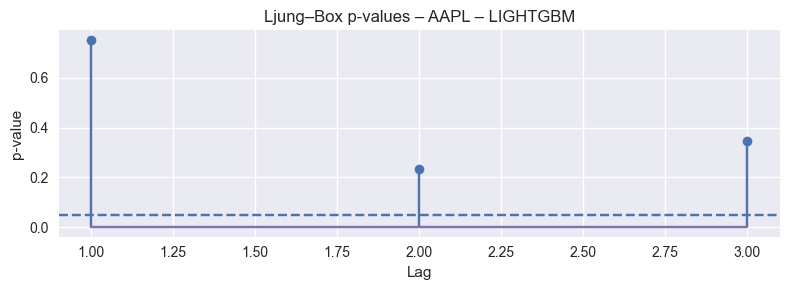


AAPL – LIGHTGBM
    lb_stat  lb_pvalue
1  0.100077   0.751738
2  2.912953   0.233056
3  3.304273   0.347048
----------------------------------------


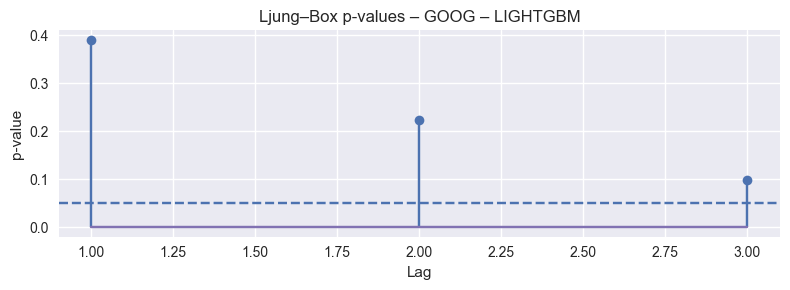


GOOG – LIGHTGBM
    lb_stat  lb_pvalue
1  0.737451   0.390479
2  2.996737   0.223495
3  6.277162   0.098877
----------------------------------------


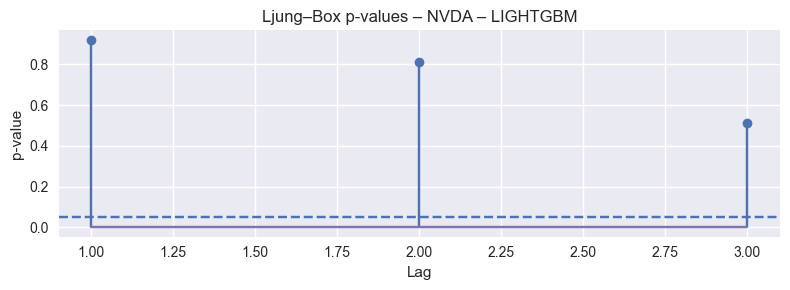


NVDA – LIGHTGBM
    lb_stat  lb_pvalue
1  0.009735   0.921405
2  0.420167   0.810517
3  2.304149   0.511727
----------------------------------------


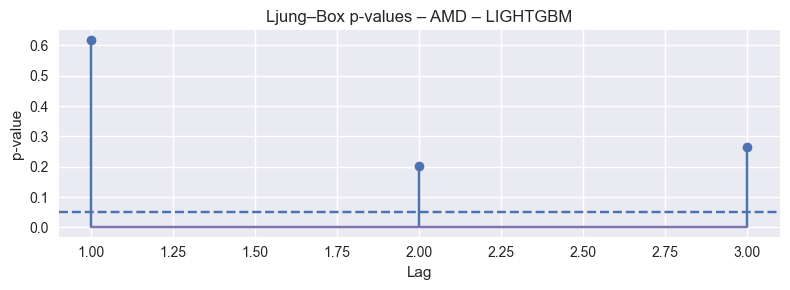


AMD – LIGHTGBM
    lb_stat  lb_pvalue
1  0.247803   0.618626
2  3.195985   0.202302
3  3.976484   0.264015
----------------------------------------


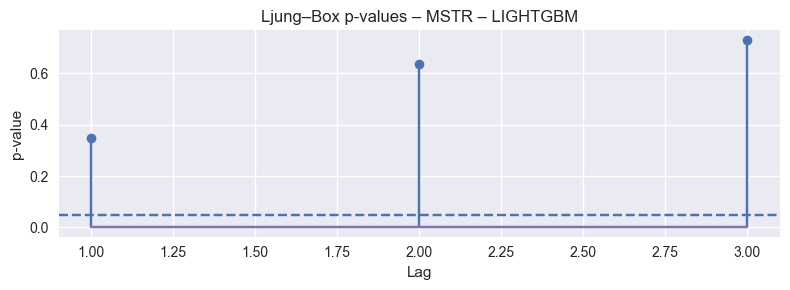


MSTR – LIGHTGBM
    lb_stat  lb_pvalue
1  0.885734   0.346636
2  0.905600   0.635845
3  1.290088   0.731488
----------------------------------------


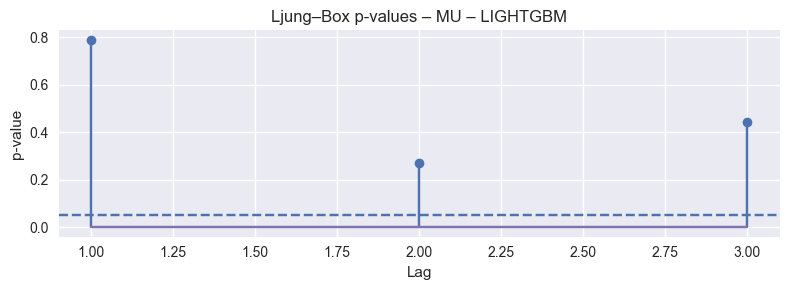


MU – LIGHTGBM
    lb_stat  lb_pvalue
1  0.071403   0.789304
2  2.604736   0.271887
3  2.674571   0.444566
----------------------------------------


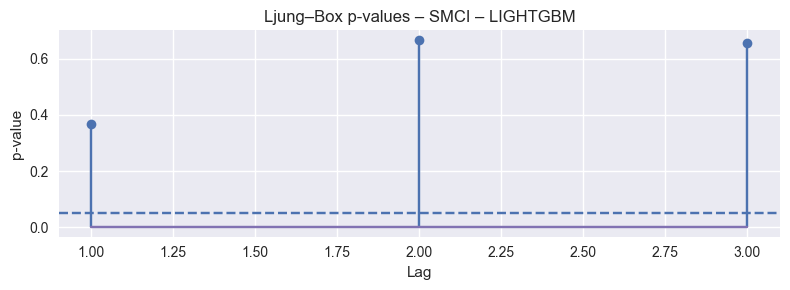


SMCI – LIGHTGBM
    lb_stat  lb_pvalue
1  0.808292   0.368626
2  0.808297   0.667545
3  1.610050   0.657113
----------------------------------------


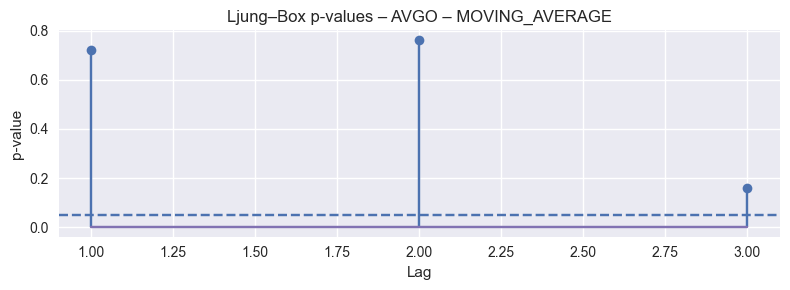


AVGO – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.126868   0.721702
2  0.541852   0.762673
3  5.187583   0.158566
----------------------------------------


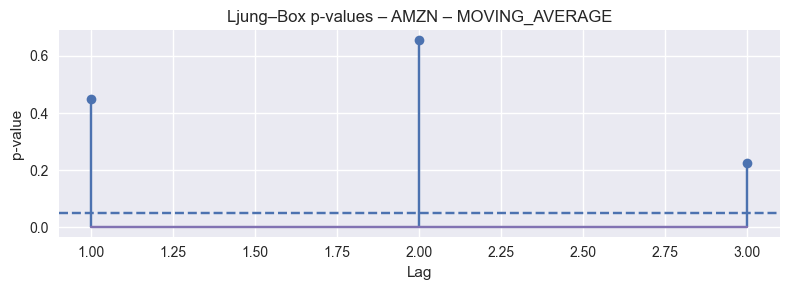


AMZN – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.573071   0.449041
2  0.841795   0.656457
3  4.343977   0.226637
----------------------------------------


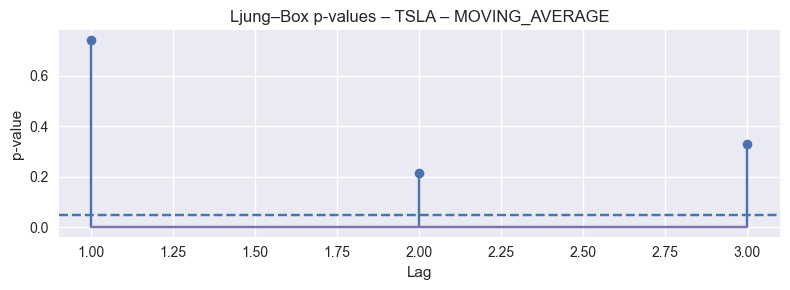


TSLA – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.106923   0.743675
2  3.078529   0.214539
3  3.412595   0.332276
----------------------------------------


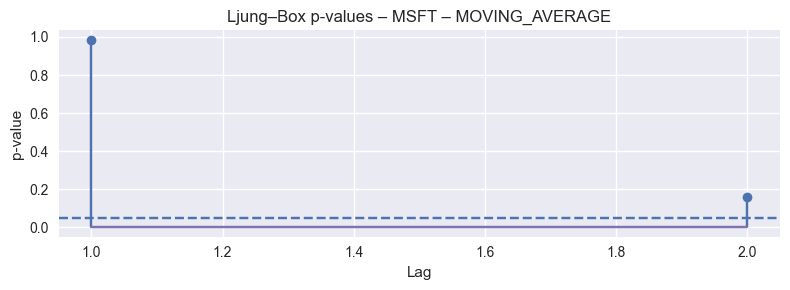


MSFT – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.000338   0.985324
2  3.650265   0.161196
----------------------------------------


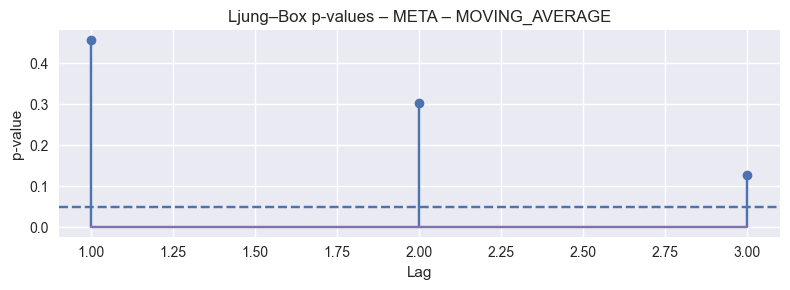


META – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.552680   0.457225
2  2.387976   0.303010
3  5.704961   0.126881
----------------------------------------


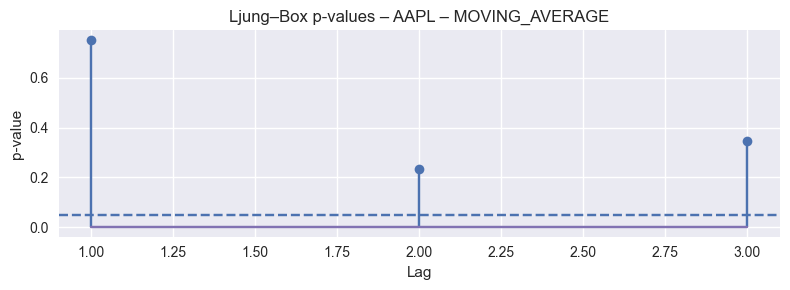


AAPL – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.100077   0.751738
2  2.912953   0.233056
3  3.304273   0.347048
----------------------------------------


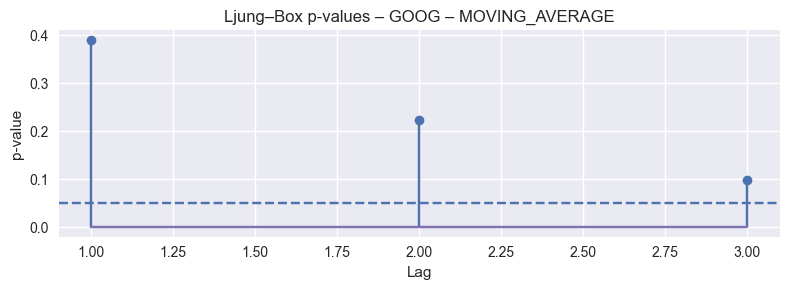


GOOG – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.737451   0.390479
2  2.996737   0.223495
3  6.277162   0.098877
----------------------------------------


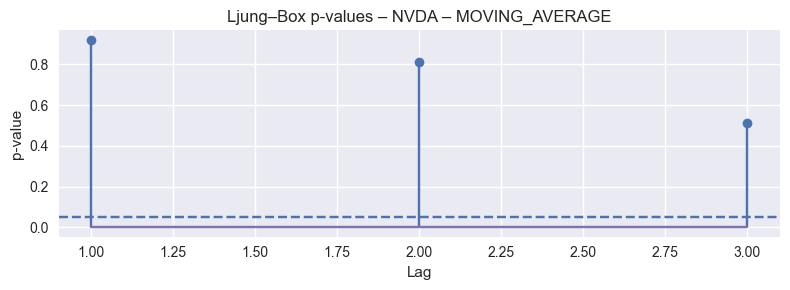


NVDA – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.009735   0.921405
2  0.420167   0.810517
3  2.304149   0.511727
----------------------------------------


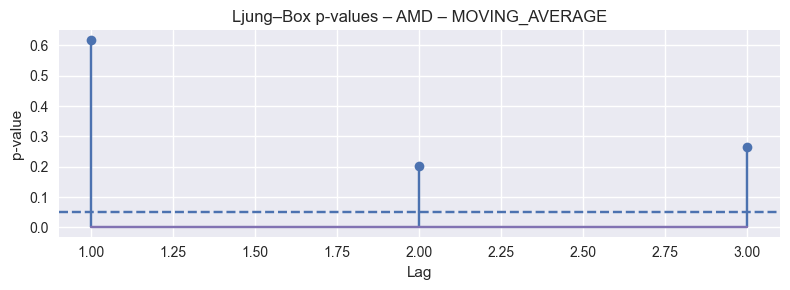


AMD – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.247803   0.618626
2  3.195985   0.202302
3  3.976484   0.264015
----------------------------------------


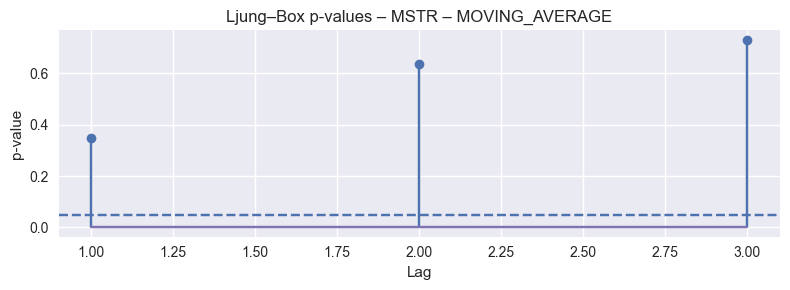


MSTR – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.885734   0.346636
2  0.905600   0.635845
3  1.290088   0.731488
----------------------------------------


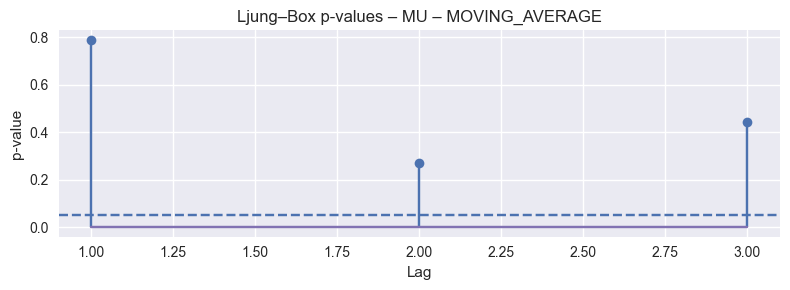


MU – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.071403   0.789304
2  2.604736   0.271887
3  2.674571   0.444566
----------------------------------------


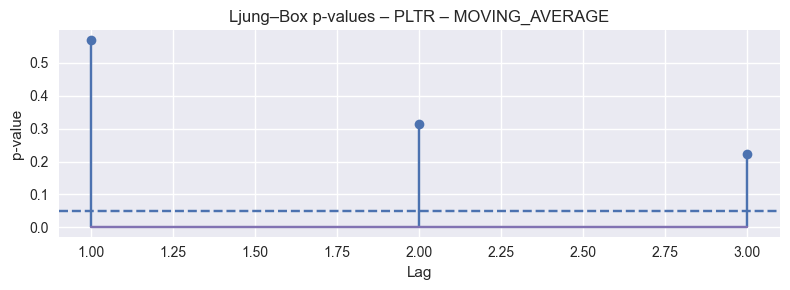


PLTR – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.322451   0.570139
2  2.322240   0.313135
3  4.376117   0.223610
----------------------------------------


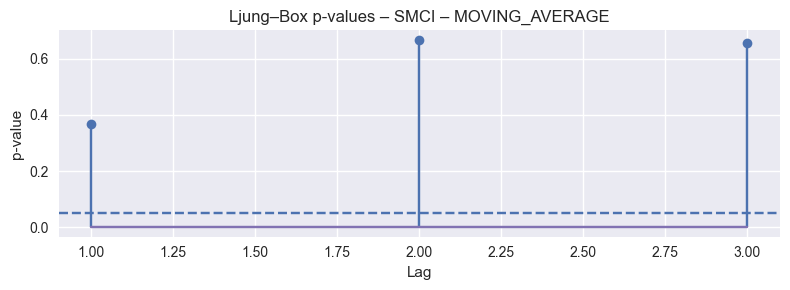


SMCI – MOVING_AVERAGE
    lb_stat  lb_pvalue
1  0.808292   0.368626
2  0.808297   0.667545
3  1.610050   0.657113
----------------------------------------


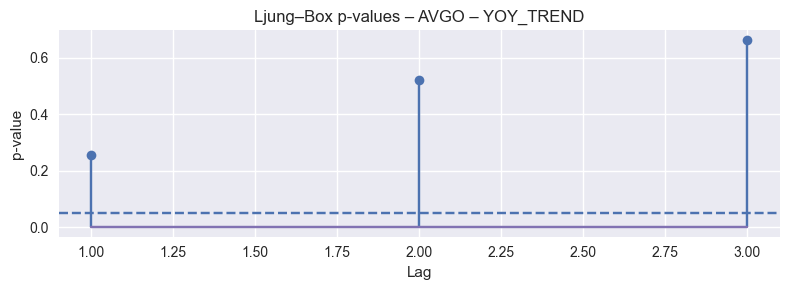


AVGO – YOY_TREND
    lb_stat  lb_pvalue
1  1.299223   0.254355
2  1.300594   0.521891
3  1.578944   0.664173
----------------------------------------


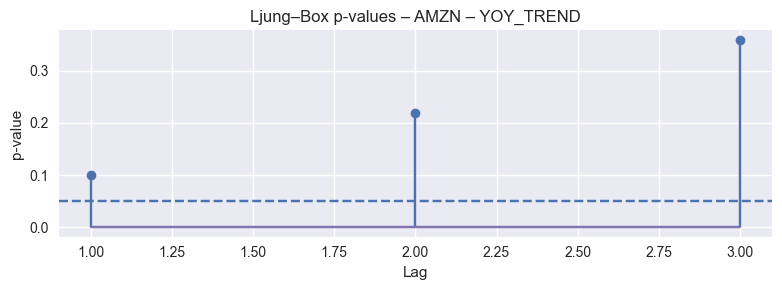


AMZN – YOY_TREND
    lb_stat  lb_pvalue
1  2.701285   0.100267
2  3.037640   0.218970
3  3.216529   0.359430
----------------------------------------


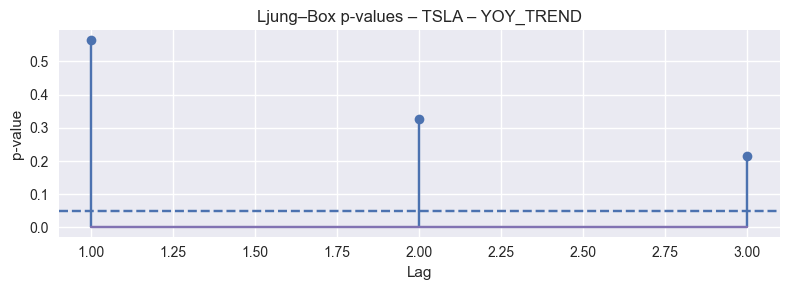


TSLA – YOY_TREND
    lb_stat  lb_pvalue
1  0.329970   0.565677
2  2.237792   0.326640
3  4.461067   0.215789
----------------------------------------


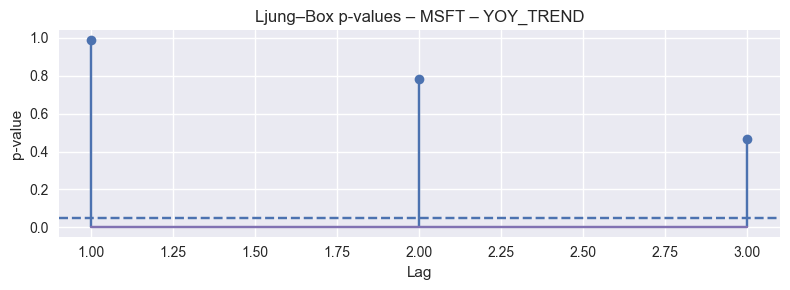


MSFT – YOY_TREND
    lb_stat  lb_pvalue
1  0.000171   0.989579
2  0.497498   0.779776
3  2.541090   0.467911
----------------------------------------


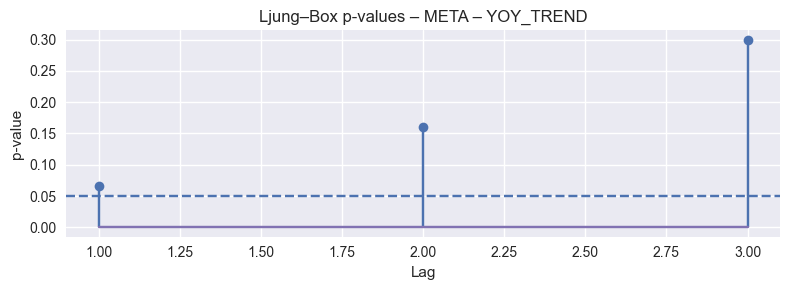


META – YOY_TREND
    lb_stat  lb_pvalue
1  3.362748   0.066687
2  3.664407   0.160060
3  3.666910   0.299751
----------------------------------------


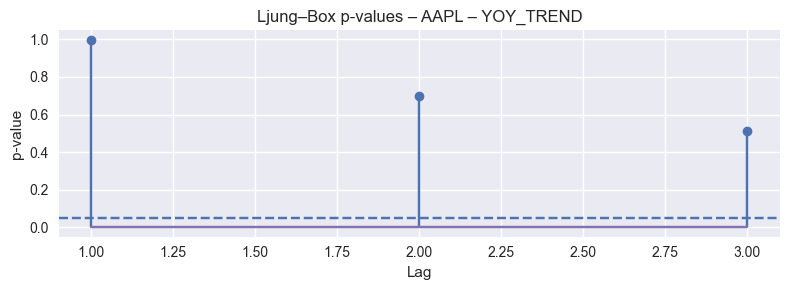


AAPL – YOY_TREND
    lb_stat  lb_pvalue
1  0.000008   0.997777
2  0.723453   0.696473
3  2.289575   0.514521
----------------------------------------


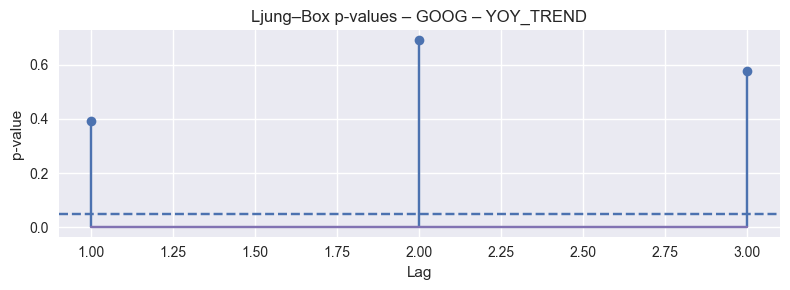


GOOG – YOY_TREND
    lb_stat  lb_pvalue
1  0.727330   0.393750
2  0.737322   0.691660
3  1.977651   0.577058
----------------------------------------


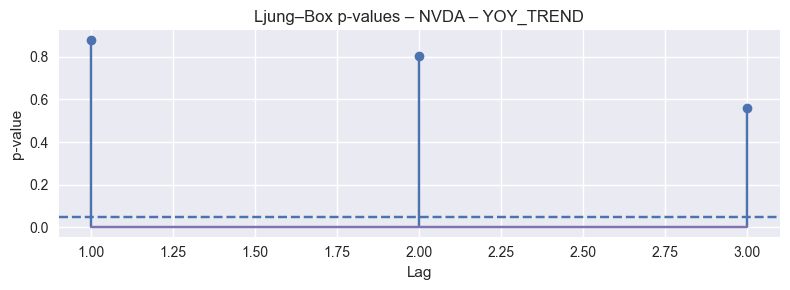


NVDA – YOY_TREND
    lb_stat  lb_pvalue
1  0.022950   0.879588
2  0.438857   0.802978
3  2.064637   0.559100
----------------------------------------


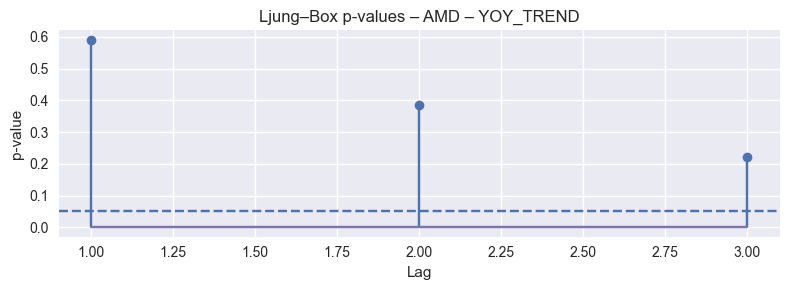


AMD – YOY_TREND
    lb_stat  lb_pvalue
1  0.288149   0.591409
2  1.907289   0.385334
3  4.402819   0.221124
----------------------------------------


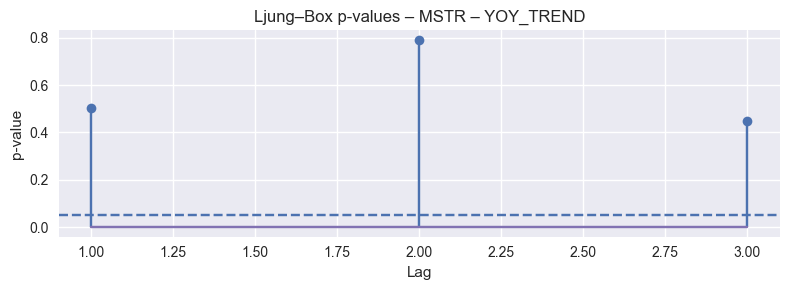


MSTR – YOY_TREND
    lb_stat  lb_pvalue
1  0.450066   0.502304
2  0.468546   0.791146
3  2.658235   0.447372
----------------------------------------


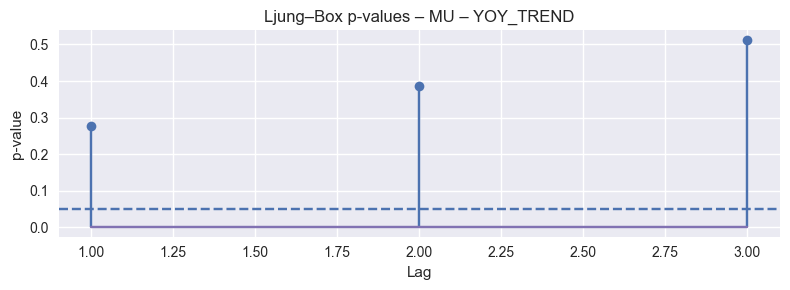


MU – YOY_TREND
    lb_stat  lb_pvalue
1  1.178108   0.277742
2  1.898955   0.386943
3  2.297363   0.513026
----------------------------------------


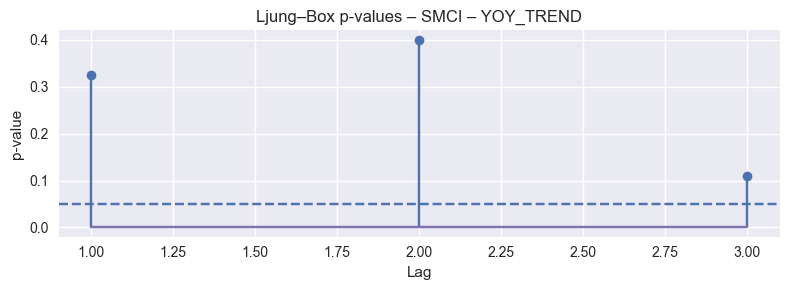


SMCI – YOY_TREND
    lb_stat  lb_pvalue
1  0.970496   0.324557
2  1.829745   0.400568
3  6.049056   0.109248
----------------------------------------


In [51]:
print("\nLJUNG–BOX TEST SUI RESIDUI")
print("=" * 80)

max_lag = 10  # puoi alzarlo se hai molte osservazioni

for model in MODELS:
    for ticker in TICKERS:
        resid = load_residuals(model, ticker)
        if resid is None or resid.empty:
            continue

        n = len(resid)
        if n < 3:
            print(f"Skip Ljung–Box: troppo pochi punti (n={n}) per {ticker} – {model.upper()}")
            continue

        use_lags = min(max_lag, n - 1)

        lb = acorr_ljungbox(resid.values, lags=use_lags, return_df=True)

        fig, ax = plt.subplots(figsize=(8, 3))
        ax.stem(lb.index, lb["lb_pvalue"])  # niente use_line_collection
        ax.axhline(0.05, linestyle="--")
        ax.set_xlabel("Lag")
        ax.set_ylabel("p-value")
        ax.set_title(f"Ljung–Box p-values – {ticker} – {model.upper()}")

        fig.tight_layout()
        plt.show()

        print(f"\n{ticker} – {model.upper()}")
        print(lb)
        print("-" * 40)